# Turbulence synthesis: quantile ψ vs generalized-Gaussian ψ potential

This notebook runs the same 1D turbulence synthesis experiment twice:

1. **Baseline quantile model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_quantile_confine', 'Scalar_morlet_quantile_confine']
   ```

2. **Generalized-Gaussian ψ model**
   ```python
   ['Scattering_Second_Order', 'Scattering_Fourth_Order_Real',
    'Scalar_psi_generalized_gaussian', 'Scalar_morlet_generalized_gaussian']
   ```

The two runs are saved under different configuration names. The generalized-Gaussian run appends
`_generalized_gauss` to the saved sample name.


In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

def aux_path(config):
    return root.parent / f'{config}_aux_moments.pt'


def try_load_experiment(config):
    """Try loading saved SDE outputs and auxiliary moment-matching data."""
    try:
        xt, theta_t, dH_t_bound, t_loaded = load_results(root.parent, config)
        out = {
            'xt': xt.to(device) if torch.is_tensor(xt) else xt,
            'theta_t': theta_t,
            'dH_t_bound': dH_t_bound,
            't': t_loaded.to(device) if torch.is_tensor(t_loaded) else t_loaded,
            'loaded': True,
        }
        ap = aux_path(config)
        if ap.exists():
            aux = torch.load(ap, map_location=device)
            out.update(aux)
        else:
            out['barphi_e'] = None
            out['barphi_p'] = None
        return out
    except Exception as e:
        print(f'Could not load {config}: {e}')
        return None


def run_experiment(exp, force_rerun=False):
    config = exp['config']
    terms = exp['terms']

    if not force_rerun:
        loaded = try_load_experiment(config)
        if loaded is not None:
            print(f'Loaded existing results for {config}')
            return loaded

    print(f'Running experiment: {config}')
    print('terms:', terms)

    potentials = get_1d_potentials(terms,J, filters, Q, filters_Q, filters_Phi, scalar_param=None, parallel=False,)

    Solver = SDE(x1, nb_workers,  nb_interpolants,t, sigma, potentials, batch_size, device=device, regularization=regularization,interpolant=interpolant, use_coshgt_s0 = use_coshgt_s0,)

    xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

    save_results(xt, theta_t, dH_t_bound, t, root.parent, config)

    if SAVE_AUX_MOMENTS:
        torch.save(
            {
                'barphi_e': barphi_e.detach().cpu(),
                'barphi_p': barphi_p.detach().cpu(),
            },
            aux_path(config),
        )

    return {
        'xt': xt,
        'theta_t': theta_t,
        'dH_t_bound': dH_t_bound,
        't': t,
        'barphi_e': barphi_e,
        'barphi_p': barphi_p,
        'loaded': False,
    }

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
def split_periodize_reshape(Data, n1):
    """
    Splits Data into non-overlapping subseries of length n1 along the last axis,
    discards the end if not divisible, periodizes each subseries, and reshapes
    the output to [batch * num_subseries, channels, n1].
    """
    num_subseries = Data.size(-1) // n1
    Data_sub = Data[:, :, :num_subseries * n1]
    Data_sub = Data_sub.unfold(-1, n1, n1)

    first = Data_sub[..., 0:1]
    last = Data_sub[..., -1:]
    a = (last - first) / (n1 - 1)
    b = first
    x = torch.arange(n1, device=Data.device, dtype=Data.dtype)
    linear = a * x + b 
    Data_periodized = Data_sub - linear 
    Data_periodized = Data_periodized + first 

    batch, channels, _, _ = Data_periodized.shape
    return Data_periodized.reshape(batch * num_subseries, channels, n1)

## Data preprocessing

In [3]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
n_data = 1024
Data = split_periodize_reshape(Data, n_data)

# Same preprocessing as in the original notebook.
for j in range(2):
    Data = W.decompose(Data)[1]

n1 = 5000
x1 = normalize(Data[:n1]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape)


Data shape after preprocessing: torch.Size([10000, 1, 256])
x1 shape: torch.Size([5000, 1, 256])


## Shared model/SDE parameters

In [4]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 8
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device) 

interpolant = 'Cos'
nt = 50000   # originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2
sigma = 1

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0]  
regularization = 1e-1

base_config = f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}'
print('base_config:', base_config)


(B, C, T) = (5000, 1, 256).
base_config: turbulence_synthesis_256_J_8_Q_3_sigma_1


## Define the two experiments

In [5]:
experiments = {
    'coshgt_psi': {
        'label': 'CoshGt ψ',
        'suffix': f'turbulence_synthesis_128_J_7_Q_3_sigma_{sigma}_nt{nt}_n1_{n1}_scattering4order_coshgt_scalingexp_bulk0.99-0.015+0.005',
        'terms': [
            'L_2_lowpass', # --> 1 potential 
            'Scattering_Fourth_Order_Real_Q1', # --> 56 potentials 
            #'Scattering_Second_Order_bulk',
            'Scalar_psi_coshgt', # --> 44 potentials 
            'Scalar_morlet_coshgt', # --> 16 potentials 
            #'Scalar_psi_coshgt_imag',
            #'Scalar_morlet_coshgt_imag',
        ],
    },

}

for key, exp in experiments.items():
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])


coshgt_psi -> turbulence_synthesis_256_J_8_Q_3_sigma_1turbulence_synthesis_128_J_7_Q_3_sigma_1_nt50000_n1_5000_scattering4order_coshgt_scalingexp_bulk0.99-0.015+0.005


## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


## Run both experiments

In [6]:
results = {}

use_coshgt_s0 = True
for key, exp in experiments.items():
    results[key] = run_experiment(exp, force_rerun=False)
    print('-' * 80)


Loaded existing results for turbulence_synthesis_256_J_8_Q_3_sigma_1turbulence_synthesis_128_J_7_Q_3_sigma_1_nt50000_n1_5000_scattering4order_coshgt_scalingexp_bulk0.99-0.015+0.005
--------------------------------------------------------------------------------


In [7]:
for key, exp in experiments.items():
    res = results[key]
    theta_t = res['theta_t']


potential                             dim            cols  source
L_2_lowpass                             1  [   0:1   ]  'num_coefficients' attribute
Scalar_psi_coshgt                      50  [   1:51  ]  'num_coefficients' attribute
Scalar_morlet_coshgt                   18  [  51:69  ]  'num_coefficients' attribute
Scattering_Fourth_Order_Real_Q1        84  [  69:153 ]  'num_coefficients' attribute
OK: 4 potentials account for all 153 theta columns (theta_t.shape[1]=153).
-> Scattering_Fourth_Order_Real_Q1: cols [69:153] out of 153
scat_potential.J = 8  scat_potential.Q = 1  num_coefficients = 84
scat_potential.filters.shape = (1, 9, 256)
scat_potential.filters_Q.shape = (1, 8, 256)
Expected #coefficients per j (combinatorial fingerprint): {0: 28, 1: 21, 2: 15, 3: 10, 4: 6, 5: 3, 6: 1}

 row   min   max  n_unique  value_counts
   0     0     6         7  {0: 28, 1: 21, 2: 15, 3: 10, 4: 6, 5: 3, 6: 1}
   1     1     7         7  {1: 7, 2: 12, 3: 15, 4: 16, 5: 15, 6: 12, 7: 7}
   2  

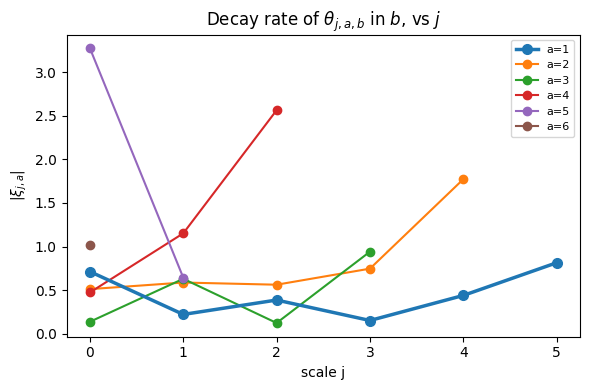

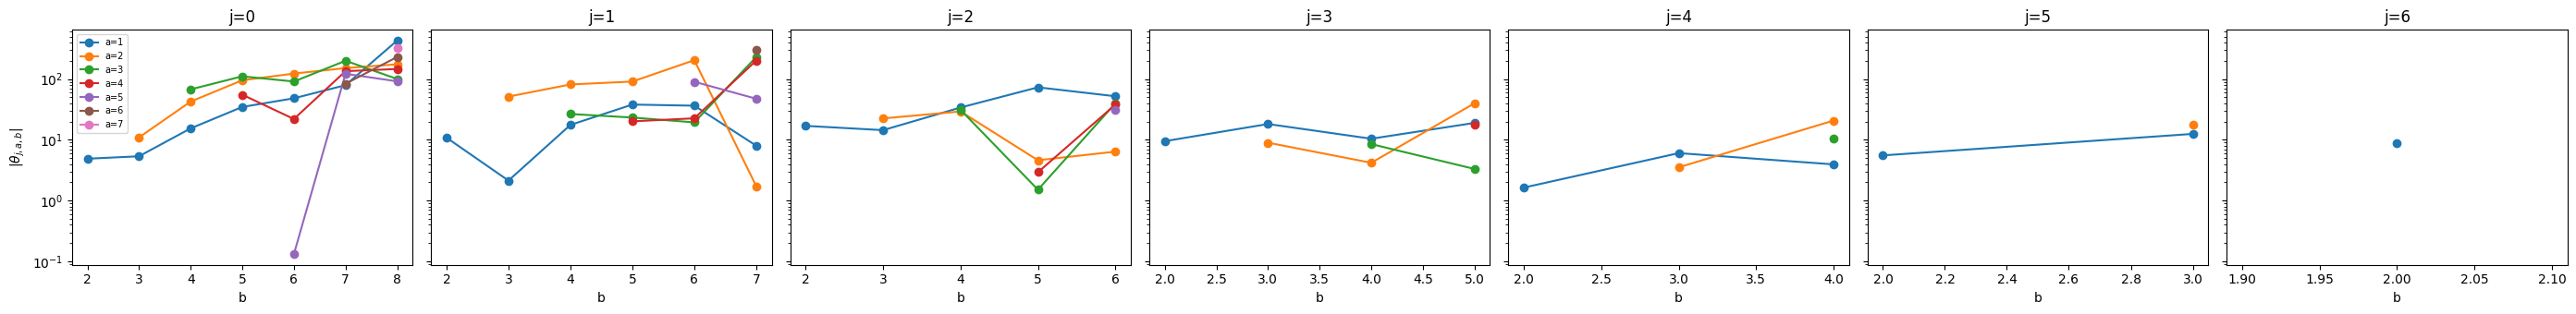

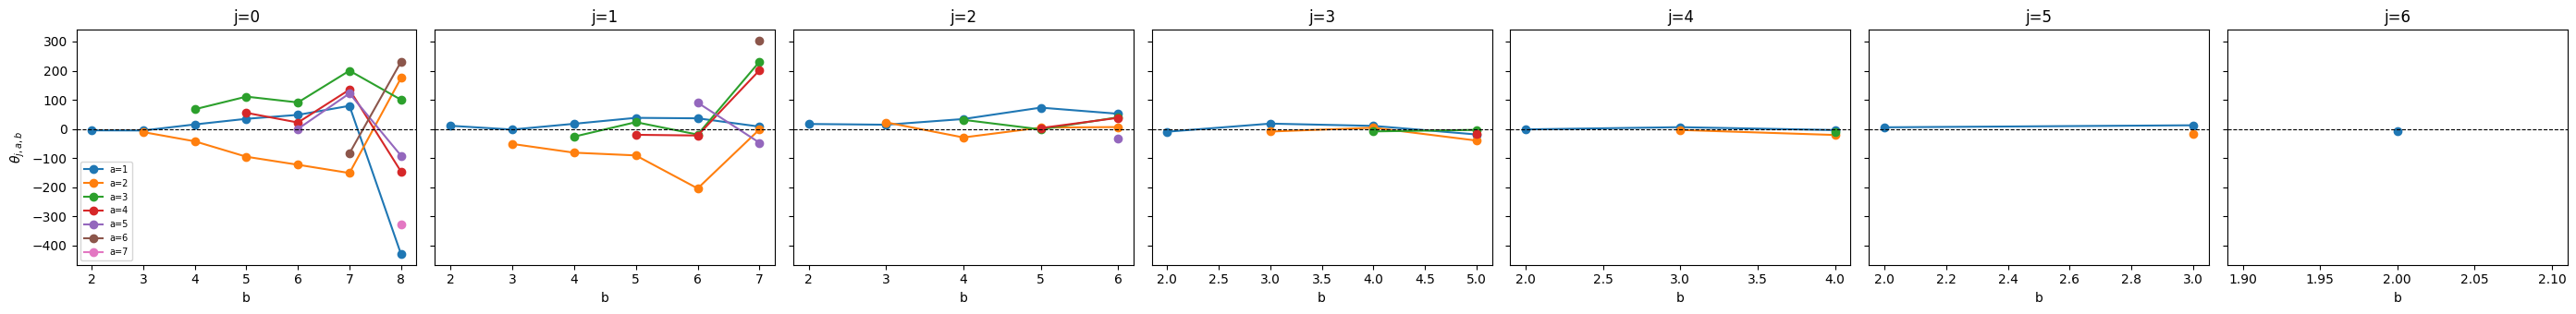

In [8]:
## Scattering theta scaling analysis
 
# ----------------------------------------------------------------------
# Pick the experiment to analyse explicitly instead of relying on the
# "last value of a for-loop" trick (there is currently only one entry
# in `experiments`, but this makes the dependency explicit and avoids
# silently picking the wrong one if a second experiment is added later).
# ----------------------------------------------------------------------
ANALYSIS_KEY = 'coshgt_psi'
exp = experiments[ANALYSIS_KEY]
res = results[ANALYSIS_KEY]
theta_t = res['theta_t']
 
from collections import defaultdict
 
# ----------------------------------------------------------------------
# 0. Locate every potential's columns in theta_t WITHOUT hardcoding
#    position.
#
#    THE BUG: the previous version assumed any potential lacking an
#    `.indices` attribute occupies exactly 1 theta column. That's true
#    for `L_2_lowpass`, but FALSE for the multi-region cosh-Gt scalar
#    potentials: `Scalar_psi_coshgt` (44 columns) and
#    `Scalar_morlet_coshgt` (16 columns) each expand into many theta
#    entries -- one per telescoping-sigmoid bulk/tail region -- despite
#    being "Scalar_*" potentials. That silent "assume 1" fallback is
#    exactly why sum(dims) came out as 59 (1 + 56 + 1 + 1) instead of
#    the true 117 (1 + 56 + 44 + 16).
#
#    FIX: try to introspect the true width first (in decreasing order
#    of reliability), and only fall back to an explicit, independently
#    verified override table -- never to a silent "assume 1".
# ----------------------------------------------------------------------
terms = exp['terms']
potentials = get_1d_potentials(
    terms, J, filters, Q, filters_Q, filters_Phi,
    scalar_param=None, parallel=False,
)
 
TARGET_KEY = 'Scattering_Fourth_Order_Real_Q1'
 
# Independently verified column counts (see comments next to `terms` in
# the experiment dict above). Used only when a potential does not
# expose enough introspection to determine its own width -- this is
# currently the case for the multi-region scalar cosh-Gt potentials.
# If you add a new term, count its true theta width (e.g. from the
# potential's own construction code, or empirically -- see note below)
# and add it here rather than letting n_theta() guess.
KNOWN_POTENTIAL_DIMS = {
    'L_2_lowpass': 1,
    'Scattering_Fourth_Order_Real_Q1': 84,
    'Scalar_psi_coshgt': 50,
    'Scalar_morlet_coshgt': 18,
}
 
def n_theta(p, key, known_dims=KNOWN_POTENTIAL_DIMS):
    """
    Return (dim, source) for potential `p`, trying progressively less
    direct ways of finding its true theta-block width. Never silently
    assumes dim=1.
    """
    # 1. An explicit width attribute/method, if the class defines one.
    for attr in ('n_theta', 'num_theta', 'theta_dim'):
        if hasattr(p, attr):
            val = getattr(p, attr)
            val = val() if callable(val) else val
            if torch.is_tensor(val):
                val = val.numel()
            return int(val), f"'{attr}' attribute"
 
    # 2. Scattering-style potentials set this at construction time:
    #    self.num_coefficients = len(self.indices[0]).
    if hasattr(p, 'num_coefficients'):
        return int(p.num_coefficients), "'num_coefficients' attribute"
 
    # 3. Any potential storing an (..., N) index tensor.
    if hasattr(p, 'indices'):
        idx = p.indices
        width = idx.shape[-1] if torch.is_tensor(idx) else np.asarray(idx).shape[-1]
        return int(width), "'.indices.shape[-1]'"
 
    # 4. Multi-region scalar potentials: if the class exposes its
    #    region count directly, prefer that over the hardcoded table.
    for attr in ('num_regions', 'n_regions'):
        if hasattr(p, attr):
            n_regions = int(getattr(p, attr))
            params_per_region = int(getattr(p, 'n_params_per_region', 1))
            return n_regions * params_per_region, f"'{attr}' x n_params_per_region"
 
    # 5. Last resort: an explicit, independently-verified override.
    if key in known_dims:
        return int(known_dims[key]), "KNOWN_POTENTIAL_DIMS override (UNVERIFIED by introspection -- fix the class if possible)"
 
    raise RuntimeError(
        f"Cannot determine theta width for potential '{key}' "
        f"({type(p).__name__}): no n_theta/num_theta/theta_dim/"
        "num_coefficients/.indices/num_regions attribute, and no entry "
        "in KNOWN_POTENTIAL_DIMS. Add one rather than guessing."
    )
 
keys = list(potentials.keys())
dims, sources = [], []
for k in keys:
    d, src = n_theta(potentials[k], k)
    dims.append(d)
    sources.append(src)
    # Cross-check: if introspection succeeded via a real attribute AND
    # we also have an independent KNOWN_POTENTIAL_DIMS entry, they must
    # agree -- a mismatch means one of the two is stale.
    if k in KNOWN_POTENTIAL_DIMS and 'override' not in src and d != KNOWN_POTENTIAL_DIMS[k]:
        print(f"WARNING: introspected dim for {k} ({d}) != "
              f"KNOWN_POTENTIAL_DIMS[{k}] ({KNOWN_POTENTIAL_DIMS[k]}) "
              "-- one of them is out of date, please reconcile.")
 
offsets = np.cumsum([0] + dims)
print(f"{'potential':35s} {'dim':>5s}  {'cols':>14s}  source")
for k, d, o, src in zip(keys, dims, offsets[:-1], sources):
    print(f"{k:35s} {d:5d}  [{o:4d}:{o+d:<4d}]  {src}")
 
assert sum(dims) == theta_t.shape[1], (
    f"sum(dims)={sum(dims)} != theta_t.shape[1]={theta_t.shape[1]} -- "
    "dict order != column order, or a dim above is still wrong "
    "(check the per-potential 'source' column printed above)."
)
print(f"OK: {len(keys)} potentials account for all {sum(dims)} theta "
      f"columns (theta_t.shape[1]={theta_t.shape[1]}).")
 
def get_theta_columns(key, keys=keys, offsets=offsets, dims=dims, theta_t=theta_t):
    """Slice out the theta_t columns belonging to potential `key`."""
    i = keys.index(key)
    start, dim = int(offsets[i]), dims[i]
    block = theta_t[:, start:start + dim]
    block = block.cpu().numpy() if torch.is_tensor(block) else block
    return block, start, dim
 
theta_scat_raw, scat_start, scat_dim = get_theta_columns(TARGET_KEY)
scat_potential = potentials[TARGET_KEY]
assert scat_dim == scat_potential.num_coefficients == scat_potential.indices.shape[-1]
print(f"-> {TARGET_KEY}: cols [{scat_start}:{scat_start+scat_dim}] "
      f"out of {theta_t.shape[1]}")
 
# The two multi-region scalar potentials are now also correctly
# located, in case you want to extend the analysis to them later, e.g.:
#   theta_psi_coshgt, _, _    = get_theta_columns('Scalar_psi_coshgt')     # 44 cols
#   theta_morlet_coshgt, _, _ = get_theta_columns('Scalar_morlet_coshgt')  # 16 cols
 
# ----------------------------------------------------------------------
# 1. Decode (j, a, b) from potential.indices.
#
#    Tracing Scattering_Fourth_Order_Real_1d.forward() to find out what
#    indices[0], indices[1], indices[2] actually index into:
#
#      x_filtered      = ifft(filters_Q * fft(x))           # (B, JQ, T)
#      x_filtered_abs   -> envelope                          # (B, JQ, T)
#      W_Wx            = ifft(filters[:,:,None] * fft(x_filtered_abs)[:,None])
#                                                             # (B, JQ, J+1, T)
#      output = real(W_Wx[:,:,:,None] * W_Wx[:,:,None].conj())
#                                                             # (B, JQ, J+1_a, J+1_b, T)
#      output = output.mean(-1)                              # (B, JQ, J+1_a, J+1_b)
#      output = output.permute(0, 3, 2, 1)                   # (B, J+1_b, J+1_a, JQ)
#      output = output[:, indices[0], indices[1], indices[2]]
#
#    The JQ axis (the *first-layer* scale j) is never broadcast against
#    itself -- W_Wx[:, :, :, None] and W_Wx[:, :, None] both keep their
#    JQ axis (axis 1) aligned, only the J+1 axis gets broadcast into a
#    J+1 x J+1 grid. So there is exactly ONE first-layer scale j per
#    coefficient, and TWO second-layer *absolute* scales (call them
#    s1, s2, both in [0, J]) being cross-multiplied.
#
#    After the permute, axis order is (B, J+1_b, J+1_a, JQ), so:
#       indices[0] -> s2  (absolute scale, range [0, J])
#       indices[1] -> s1  (absolute scale, range [0, J])
#       indices[2] -> j   (first-layer scale, range [0, JQ-1])
#    i.e. indices[2] is j, NOT indices[0] -- the previous version of
#    this function had that backwards (it set j = indices[0], which is
#    actually one of the two absolute scales, not the shared first-layer
#    scale). Because real(A*conj(B)) == real(B*conj(A)), the coefficient
#    VALUE doesn't care which of indices[0]/indices[1] is "s1" vs "s2";
#    it only matters for how *we* choose to label a vs b below.
#
#    Rather than asserting one specific row assignment (which just
#    failed at runtime -- so the shape trace above doesn't match this
#    build, most likely because `filters`/`filters_Q` don't have the
#    channel counts I assumed), determine the row assignment EMPIRICALLY
#    below, then decode using whatever it finds.
# ----------------------------------------------------------------------
import math
 
def decode_jab(potential, j_row):
    """j_row = which row of potential.indices (0, 1, or 2) is the
    shared first-layer scale j. The other two rows are the absolute
    second-layer scales; we sort them ourselves into (a < b)."""
    idx = potential.indices.long()
    other_rows = [r for r in range(3) if r != j_row]
    j = idx[j_row]
    s1, s2 = idx[other_rows[0]], idx[other_rows[1]]
    lo = torch.minimum(s1, s2)
    hi = torch.maximum(s1, s2)
    a, b = lo - j, hi - j
    return j.numpy(), a.numpy(), b.numpy(), lo.numpy(), hi.numpy()
 
# ----------------------------------------------------------------------
# 1a. Figure out which row is j -- empirically, with no filter-shape
#     assumptions at all.
#
#     Ground truth available to us: for offset=1 (a>=1) + lite (only
#     one symmetric ordering kept) + no-diag, the number of (a,b) pairs
#     at a given j is C(J-j, 2) -- this is exactly Gemini's confirmed
#     21,15,10,6,3,1,0 breakdown for J=7, summing to 56. This is a pure
#     combinatorial fingerprint: whichever row's value_counts matches
#     {0:21, 1:15, 2:10, 3:6, 4:3, 5:1} (j=6 contributes 0 and so never
#     appears) is unambiguously the j row, independent of any tensor
#     shape we might have guessed wrong.
# ----------------------------------------------------------------------
Jp = scat_potential.J
print("scat_potential.J =", Jp, " scat_potential.Q =", scat_potential.Q,
      " num_coefficients =", scat_potential.num_coefficients)
 
# Ground-truth shapes of the actual filter banks this potential uses --
# print these directly instead of assuming (J+1, T) / (JQ, T).
for attr in ('filters', 'filters_Q'):
    t = getattr(scat_potential, attr, None)
    if t is not None:
        print(f"scat_potential.{attr}.shape = {tuple(t.shape)}")
    else:
        print(f"scat_potential.{attr} not found")
 
expected_counts = {j: math.comb(Jp - j, 2) for j in range(Jp)}
expected_counts = {j: c for j, c in expected_counts.items() if c > 0}
print("Expected #coefficients per j (combinatorial fingerprint):", expected_counts)
 
idx_all = scat_potential.indices.long()
print(f"\n{'row':>4} {'min':>5} {'max':>5} {'n_unique':>9}  value_counts")
row_value_counts = []
for r in range(3):
    vals = idx_all[r].numpy()
    uniq, counts = np.unique(vals, return_counts=True)
    vc = dict(zip(uniq.tolist(), counts.tolist()))
    row_value_counts.append(vc)
    print(f"{r:>4} {int(vals.min()):>5} {int(vals.max()):>5} {len(uniq):>9}  {vc}")
 
j_row = next((r for r in range(3) if row_value_counts[r] == expected_counts), None)
 
if j_row is None:
    # No exact match -- fall back to "closest" by total absolute count
    # difference, but DON'T silently proceed with a guess; surface
    # everything needed to diagnose by hand.
    def mismatch(vc):
        keys = set(vc) | set(expected_counts)
        return sum(abs(vc.get(k, 0) - expected_counts.get(k, 0)) for k in keys)
    scores = [mismatch(vc) for vc in row_value_counts]
    best = int(np.argmin(scores))
    print(f"\nNO row matches the expected fingerprint exactly. "
          f"Mismatch scores per row: {scores} (lower is closer).")
    print(f"Best guess: row {best}, but please inspect the printed "
          f"value_counts above by hand before trusting this -- e.g. paste "
          f"them back for a second look, or check indices_fourth_order_Q's "
          f"source directly.")
    j_row = best
else:
    print(f"\n-> row {j_row} matches the combinatorial fingerprint for j exactly.")
 
j_arr, a_arr, b_arr, s1_arr, s2_arr = decode_jab(scat_potential, j_row)
print("j:", j_arr.min(), j_arr.max(), " a:", a_arr.min(), a_arr.max(), " b:", b_arr.min(), b_arr.max())
if not ((a_arr >= 1).all() and (b_arr > a_arr).all()):
    n_bad_a = int((a_arr < 1).sum())
    n_bad_b = int((b_arr <= a_arr).sum())
    print(f"WARNING: offset/lite assumptions still violated even with the "
          f"detected j_row={j_row}: {n_bad_a} entries have a<1, "
          f"{n_bad_b} entries have b<=a. Inspect row_value_counts above -- "
          f"the fingerprint match may have been coincidental, or "
          f"indices_fourth_order_Q's (a,b) convention differs from what's "
          f"assumed here (e.g. it may not always order j+a < j+b).")
 
 
# ----------------------------------------------------------------------
# 1b. Energy-conserving de-normalization.
#
#    theta is fitted against phi(x) as actually computed by forward(),
#    which (via fit_micro's self.norm) rescales each first-layer envelope
#    by E[|x_filtered_j|^2]^{1/4} before the second-layer filtering -- a
#    micro-normalization keyed on the *first-layer* scale j, not the
#    cross-scale normalization you want here. scat_potential.norm_indices
#    being trivially 1.0 just reflects that this micro-norm was never
#    fit (or fit_micro wasn't invoked) for this potential -- it is NOT
#    the (E(x_j^2) E(x_{j+a}^2))^{1/2}-style normalization below, so we
#    compute that one ourselves instead of relying on it.
#
#    To keep theta^T phi(x) (the "energy"/log-density contribution)
#    invariant under a rescaling of phi, a coefficient that is itself
#    divided by norm_jab inside the model must have its fitted theta
#    MULTIPLIED by the same norm_jab to recover the physically
#    comparable value: theta_physical = theta_fitted * norm_jab.
#
#    norm_jab for coefficient (j,a,b) is sqrt(E[Wx_s1^2] * E[Wx_s2^2]),
#    where s1=j+a, s2=j+b are the two ABSOLUTE second-layer scales
#    (indices[0], indices[1] above) and Wx_s denotes the single-layer
#    wavelet transform of the data at absolute scale s -- computed here
#    with the same J+1-channel filter bank (`filters`) this potential
#    uses for its own second-layer filtering, applied directly to x1
#    rather than to the envelope.
# ----------------------------------------------------------------------
with torch.no_grad():
    Wx_full = torch.fft.ifft(filters * torch.fft.fft(x1))       # (B, J+1, T)
    E_scale = (Wx_full.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()  # (J+1,)
 
print("E[|Wx_s|^2] per absolute scale s=0..J:", E_scale)
 
norm_jab = np.sqrt(E_scale[s1_arr] * E_scale[s2_arr])  # (scat_dim,), one per (j,a,b) coefficient
print("norm_jab range:", norm_jab.min(), norm_jab.max())
 
# ----------------------------------------------------------------------
# 2. Finite-value diagnostics -- check ~isfinite, NOT ~isnan (your Infs
#    were invisible to isnan, which is what silently poisoned nanmean).
# ----------------------------------------------------------------------
finite_mask = np.isfinite(theta_scat_raw)              # (T, scat_dim)
bad_rows = np.where((~finite_mask).any(axis=1))[0]
print("non-finite count per column:", (~finite_mask).sum(0))
print("rows with >=1 non-finite entry:", bad_rows)
 
# ----------------------------------------------------------------------
# 3. Burn-in + drop any (post-burn-in) row containing a non-finite entry,
#    THEN de-normalise. Dropping rows (not nanmean) avoids Inf leaking
#    into the mean/std for every column.
# ----------------------------------------------------------------------
BURNIN = 5000
 
keep = np.ones(theta_scat_raw.shape[0], dtype=bool)
keep[:BURNIN] = False
keep[bad_rows] = False
print(f"dropping {(~keep).sum()} rows ({BURNIN} burn-in + "
      f"{np.sum(bad_rows >= BURNIN)} non-finite past burn-in)")
 
theta_scat = theta_scat_raw[keep] * norm_jab[None, :]   # (n_valid, scat_dim)
theta_mean = theta_scat.mean(axis=0)                         # plain mean: no NaN/Inf left
theta_std  = theta_scat.std(axis=0)
print("n_valid:", keep.sum(), " any non-finite in theta_mean:", (~np.isfinite(theta_mean)).any())
 
# ----------------------------------------------------------------------
# 4. Low-variance check (slide bullet 1)
# ----------------------------------------------------------------------
cv = theta_std / (np.abs(theta_mean) + 1e-12)
reliable = cv < 0.2
print(f"median |CV| = {np.median(cv):.3f}  "
      f"({np.sum(reliable)}/{len(cv)} coeffs pass <20% noise cut)")
 
# ----------------------------------------------------------------------
# 5. (j,a,b) -> value table, grouped by (j,a) across b
# ----------------------------------------------------------------------
table  = {(int(j), int(a), int(b)): m
          for j, a, b, m in zip(j_arr, a_arr, b_arr, theta_mean)}
groups = defaultdict(list)
for (j, a, b), v in table.items():
    if not np.isfinite(v):
        continue
    groups[(j, a)].append((b, abs(v)))
 
# ----------------------------------------------------------------------
# 6. Fit theta_{j,a,b} ~ exp(-xi_{j,a} * b) per (j,a)
# ----------------------------------------------------------------------
xi = {}
for (j, a), pts in groups.items():
    pts = sorted(pts)
    bs   = np.array([p[0] for p in pts])
    vals = np.array([p[1] for p in pts])
    mask = (vals > 0) & np.isfinite(vals)
    if mask.sum() < 2:
        continue
    slope, _ = np.polyfit(bs[mask], np.log(vals[mask]), 1)
    xi[(j, a)] = -slope
 
print(f"xi entries fitted: {len(xi)} / {len(groups)} (j,a) groups")
 
# ----------------------------------------------------------------------
# 7. Plot xi_{j,a} vs j (Fig. 6)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))
for a in sorted({a for (_, a) in xi}):
    js  = sorted(j for (j, aa) in xi if aa == a)
    xis = [xi[(j, a)] for j in js]
    kw = dict(marker='o', label=f'a={a}')
    if a == 1:
        kw.update(linewidth=2.5, markersize=7, zorder=10)
    plt.plot(js, np.abs(xis), **kw)
plt.xlabel('scale j'); plt.ylabel(r'$|\xi_{j,a}|$')
plt.title(r'Decay rate of $\theta_{j,a,b}$ in $b$, vs $j$')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
 
# ----------------------------------------------------------------------
# 8. Sanity overlay: raw theta_{j,a,b} vs b for each j (semilog)
# ----------------------------------------------------------------------
js_unique = sorted(set(j_arr))
fig, axes = plt.subplots(1, len(js_unique), figsize=(4 * len(js_unique), 3.5),
                          sharey=True, squeeze=False)
for ax, j in zip(axes[0], js_unique):
    for a in sorted(a for (jj, a) in groups if jj == j):
        pts = sorted(groups[(j, a)])
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], 'o-', label=f'a={a}')
    ax.set_title(f'j={j}'); ax.set_xlabel('b')
axes[0, 0].set_ylabel(r'$|\theta_{j,a,b}|$')
axes[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

# ----------------------------------------------------------------------
# rawer plot 
groups_signed = defaultdict(list)
for (j, a, b), v in table.items():
    if not np.isfinite(v):
        continue
    groups_signed[(j, a)].append((b, v))

js_unique = sorted(set(j_arr))

fig, axes = plt.subplots(
    1, len(js_unique),
    figsize=(4 * len(js_unique), 3.5),
    sharey=True,
    squeeze=False
)

for ax, j in zip(axes[0], js_unique):
    for a in sorted(a for (jj, a) in groups_signed if jj == j):
        pts = sorted(groups_signed[(j, a)])
        bs = [p[0] for p in pts]
        vals = [p[1] for p in pts]

        ax.plot(bs, vals, 'o-', label=f'a={a}')

    ax.axhline(0, color='k', ls='--', lw=0.8)
    ax.set_title(f'j={j}')
    ax.set_xlabel('b')

axes[0,0].set_ylabel(r'$\theta_{j,a,b}$')
axes[0,0].legend(fontsize=7)

plt.tight_layout()
plt.show()


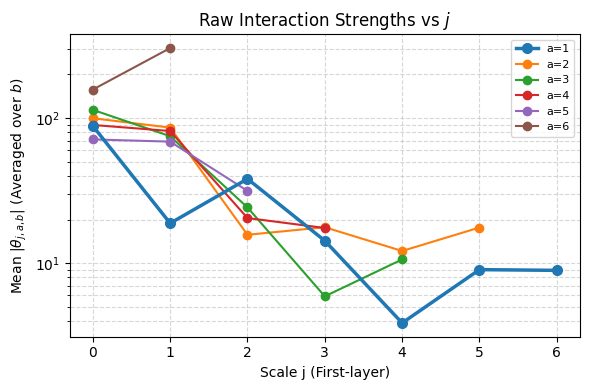

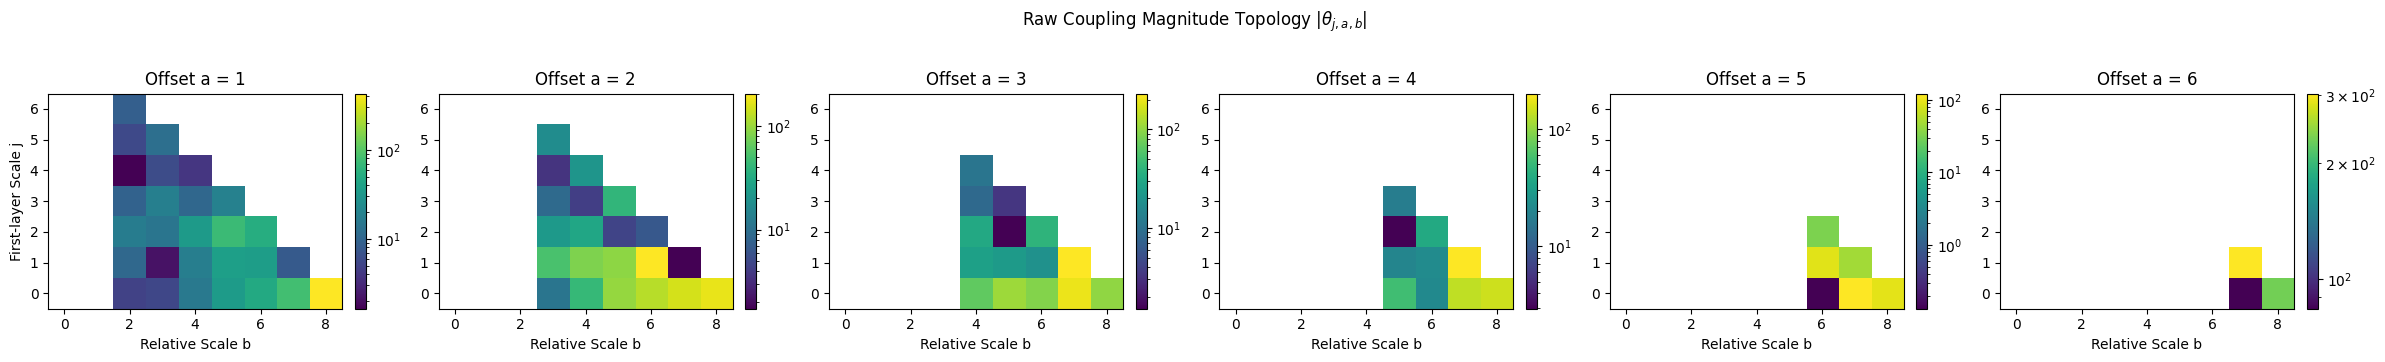

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. New Plot: Raw |theta_{j,a,b}| averaged over b, plotted vs j
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))

# Find all unique 'a' values present in our decoded data
unique_a = sorted({a for (_, a) in xi})

for a in unique_a:
    js_for_a = []
    avg_thetas = []
    
    # Loop over j to find what data exists for this specific 'a'
    for j in sorted(set(j_arr)):
        if (j, a) in groups:
            pts = groups[(j, a)]  # list of (b, abs_theta)
            
            # Collapse across all available 'b' values by taking the mean
            raw_vals = [p[1] for p in pts]
            avg_theta_over_b = np.mean(raw_vals) 
            
            js_for_a.append(j)
            avg_thetas.append(avg_theta_over_b)
            
    if js_for_a:
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        # We use semilogy here because physical coupling parameters 
        # span orders of magnitude across different scales
        plt.semilogy(js_for_a, avg_thetas, **kw)

plt.xlabel('Scale j (First-layer)')
plt.ylabel(r'Mean $|\theta_{j,a,b}|$ (Averaged over $b$)')
plt.title(r'Raw Interaction Strengths vs $j$')
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 2. Smart Alternative: 2D Heatmap Matrix of Raw |theta| (j vs b)
# ----------------------------------------------------------------------
# Dynamically determine the required grid dimensions from the data arrays
max_j = int(j_arr.max()) + 1
max_b = int(b_arr.max()) + 1

fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)

for idx, a in enumerate(unique_a):
    # Dynamically size the grid so an IndexError is structurally impossible
    grid = np.full((max_j, max_b), np.nan)
    
    for (j, aa, b), v in table.items():
        if aa == a and np.isfinite(v):
            # Ensuring coordinates fall safely inside the grid boundaries
            if j < max_j and b < max_b:
                grid[j, b] = abs(v)
            
    ax = axes[0, idx]
    from matplotlib.colors import LogNorm
    
    if not np.nanmax(grid) > 0:
        continue
        
    im = ax.imshow(grid, origin='lower', cmap='viridis', 
                   norm=LogNorm(vmin=np.nanmin(grid[grid>0]), vmax=np.nanmax(grid)),
                   aspect='auto') # 'auto' handles non-square aspect ratios beautifully
    
    ax.set_title(f'Offset a = {a}')
    ax.set_xlabel('Relative Scale b')
    if idx == 0:
        ax.set_ylabel('First-layer Scale j')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(r'Raw Coupling Magnitude Topology $|\theta_{j,a,b}|$', y=1.02)
plt.tight_layout()
plt.show()

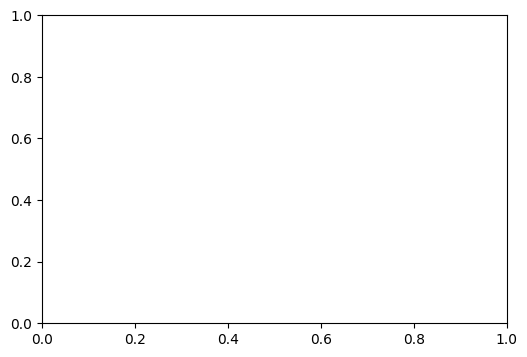

<class 'ValueError'>: x and y must have same first dimension, but have shapes (1,) and (7,)

In [13]:
# ----------------------------------------------------------------------
# 1. New Plot: Raw |theta_{j,a,b}| averaged over b, plotted vs j (Linear Scale)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))

# Find all unique 'a' values present in our decoded data
unique_a = sorted({a for (_, a) in xi})

for a in unique_a[:-1]:
    js_for_a = []
    avg_thetas = []
    
    # Loop over j to find what data exists for this specific 'a'
    for j in sorted(set(j_arr)):
        if (j, a) in groups:
            pts = groups[(j, a)]  # list of (b, abs_theta)
            
            # Collapse across all available 'b' values by taking the mean
            raw_vals = [p[1] for p in pts]
            avg_theta_over_b = np.mean(raw_vals) 
            
            js_for_a.append(j)
            avg_thetas.append(avg_theta_over_b)
            
    if js_for_a:
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        
        # Changed from plt.semilogy to plt.plot for a linear scale on both axes
        
        #plt.plot(js_for_a, avg_thetas, **kw)
        plt.plot(np.asarray(js_for_a).mean(), avg_thetas, **kw)

plt.xlabel('Scale j (First-layer)')
plt.ylabel(r'Mean $|\theta_{j,a,b}|$ (Averaged over $b$)')
plt.title(r'Raw Interaction Strengths vs $j$')
plt.legend(fontsize=8)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 2. Smart Alternative: 2D Heatmap Matrix of Raw |theta| (j vs b) (Linear Scale)
# ----------------------------------------------------------------------
# Dynamically determine the required grid dimensions from the data arrays
max_j = int(j_arr.max()) + 1
max_b = int(b_arr.max()) + 1

fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)

for idx, a in enumerate(unique_a):
    # Dynamically size the grid so an IndexError is structurally impossible
    grid = np.full((max_j, max_b), np.nan)
    
    for (j, aa, b), v in table.items():
        if aa == a and np.isfinite(v):
            # Ensuring coordinates fall safely inside the grid boundaries
            if j < max_j and b < max_b:
                grid[j, b] = abs(v)
            
    ax = axes[0, idx]
    
    if not np.nanmax(grid) > 0:
        continue
        
    # Removed LogNorm to display the intensity values on a linear scale
    im = ax.imshow(grid, origin='lower', cmap='viridis', 
                   vmin=0, vmax=np.nanmax(grid),
                   aspect='auto') # 'auto' handles non-square aspect ratios beautifully
    
    ax.set_title(f'Offset a = {a}')
    ax.set_xlabel('Relative Scale b')
    if idx == 0:
        ax.set_ylabel('First-layer Scale j')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(r'Raw Coupling Magnitude Topology $|\theta_{j,a,b}|$', y=1.02)
plt.tight_layout()
plt.show()

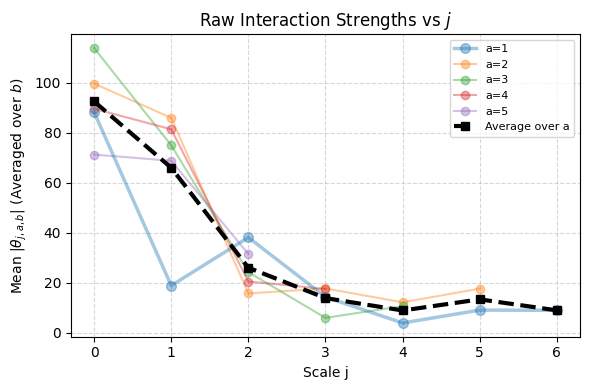

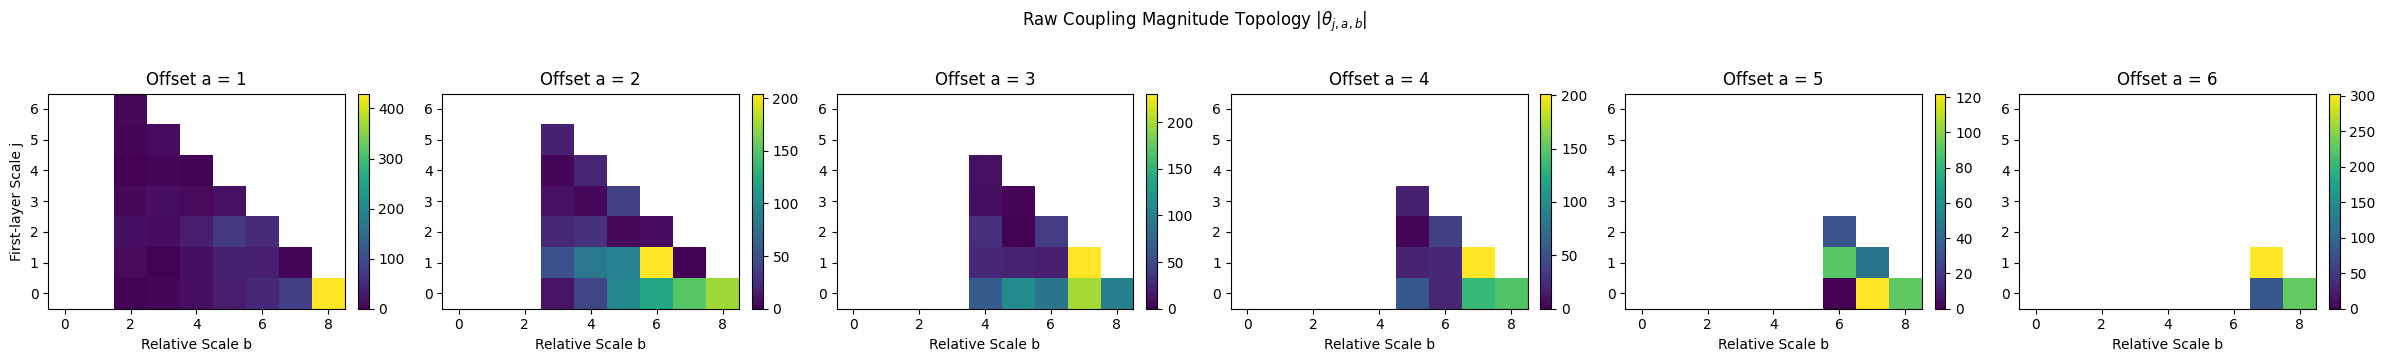

In [38]:
# ----------------------------------------------------------------------
# 1. New Plot: Raw |theta_{j,a,b}| averaged over b, plotted vs j (Linear Scale)
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))

# Find all unique 'a' values present in our decoded data
unique_a = sorted({a for (_, a) in xi})

# Dictionary to collect all avg_theta values per scale j across all 'a' values
global_j_vals = {j: [] for j in set(j_arr)}

for a in unique_a[:-1]:
    js_for_a = []
    avg_thetas = []
    
    # Loop over j to find what data exists for this specific 'a'
    for j in sorted(set(j_arr)):
        if (j, a) in groups:
            pts = groups[(j, a)]  # list of (b, abs_theta)
            
            # Collapse across all available 'b' values by taking the mean
            raw_vals = [p[1] for p in pts]
            avg_theta_over_b = np.mean(raw_vals) 
            
            js_for_a.append(j)
            avg_thetas.append(avg_theta_over_b)
            
            # Track this value for the overall average across all 'a'
            global_j_vals[j].append(avg_theta_over_b)
            
    if js_for_a:
        kw = dict(marker='o', label=f'a={a}', alpha=0.4)  # slight transparency for individual lines
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        
        plt.plot(js_for_a, avg_thetas, **kw)

# --- NEW: Compute and plot the grand average across all 'a' profiles ---
grand_js = []
grand_averages = []

for j in sorted(global_j_vals.keys()):
    if global_j_vals[j]:  # ensure data exists for this j
        grand_js.append(j)
        grand_averages.append(np.mean(global_j_vals[j]))

if grand_js:
    # Plotted with a thick black dashed line and a high zorder to sit on top
    plt.plot(grand_js, grand_averages, color='black', linestyle='--', 
             linewidth=3, marker='s', label='Average over a', zorder=20)
# -----------------------------------------------------------------------

plt.xlabel('Scale j')
plt.ylabel(r'Mean $|\theta_{j,a,b}|$ (Averaged over $b$)')
plt.title(r'Raw Interaction Strengths vs $j$')
plt.legend(fontsize=8)
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("theta_scaling.png") 


# ----------------------------------------------------------------------
# 2. Smart Alternative: 2D Heatmap Matrix of Raw |theta| (j vs b) (Linear Scale)
# ----------------------------------------------------------------------
max_j = int(j_arr.max()) + 1
max_b = int(b_arr.max()) + 1

fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)

for idx, a in enumerate(unique_a):
    grid = np.full((max_j, max_b), np.nan)
    
    for (j, aa, b), v in table.items():
        if aa == a and np.isfinite(v):
            if j < max_j and b < max_b:
                grid[j, b] = abs(v)
            
    ax = axes[0, idx]
    
    if not np.nanmax(grid) > 0:
        continue
        
    im = ax.imshow(grid, origin='lower', cmap='viridis', 
                   vmin=0, vmax=np.nanmax(grid),
                   aspect='auto')
    
    ax.set_title(f'Offset a = {a}')
    ax.set_xlabel('Relative Scale b')
    if idx == 0:
        ax.set_ylabel('First-layer Scale j')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(r'Raw Coupling Magnitude Topology $|\theta_{j,a,b}|$', y=1.02)
plt.tight_layout()
plt.show()


In [33]:
psi0 = torch.fft.ifft(filters[0,4,:]) 

In [34]:
torch.abs(psi0).sum()

tensor(1.0000, device='cuda:0')

## Moment matching diagnostics

CoshGt ψ


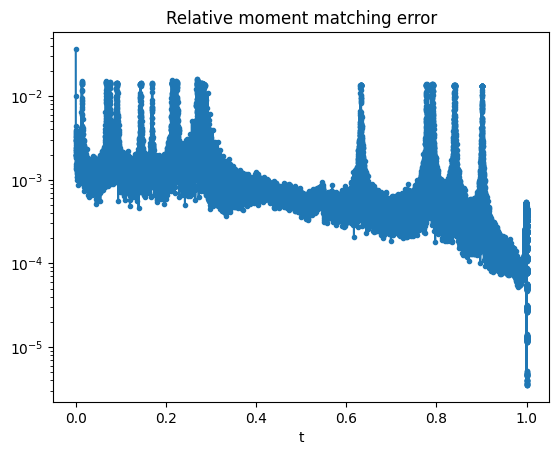

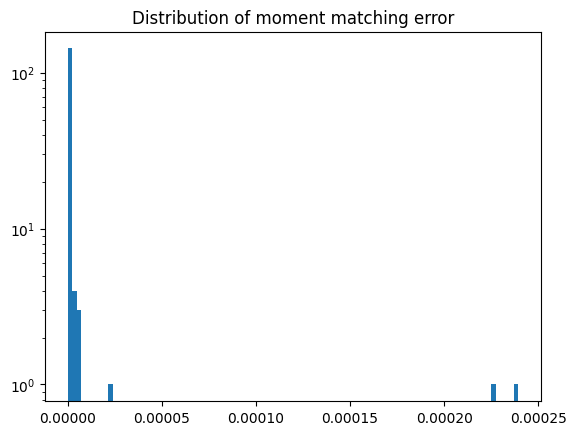

<Figure size 640x480 with 0 Axes>

In [10]:
threshold = 1e-8

for key, exp in experiments.items():
    res = results[key]
    print(exp['label'])
    if res.get('barphi_e') is None or res.get('barphi_p') is None:
        print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
    else:
        plot_moment_matching(res['barphi_e'], res['barphi_p'], res['t'], threshold)
        plt.suptitle(exp['label'])
        plt.show()


CoshGt ψ


/tmp/xpython_3000093/1200078448.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xt = np.array(res['xt'].detach().cpu())


(5000, 1, 256)


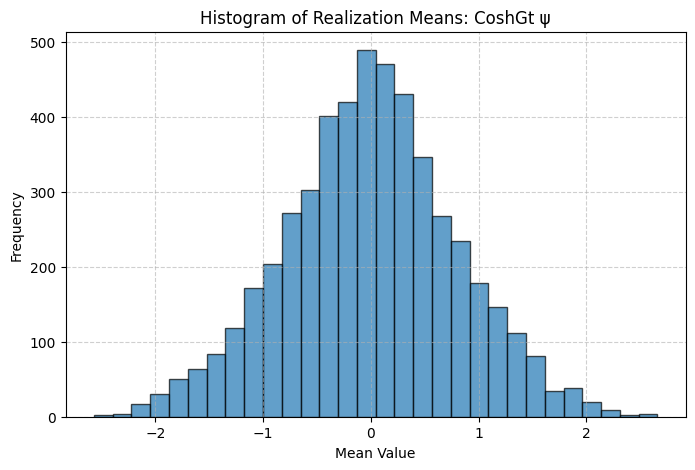

In [11]:
for key, exp in experiments.items():
    res = results[key]
    print(exp['label'])
    xt = np.array(res['xt'].detach().cpu())
    print(xt.shape) 
    realization_means = np.mean(xt, axis=2).squeeze()  # Shape becomes (1000,)
        
    # 2. Plot the histogram
    plt.figure(figsize=(8, 5))
    plt.hist(realization_means, bins=30, edgecolor='black', alpha=0.7)
    
    # 3. Add labels and titles dynamically using your experiment labels
    plt.title(f"Histogram of Realization Means: {exp['label']}")
    plt.xlabel("Mean Value")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Display the plot for the current experiment
    plt.show()

## Checking thetas

=== Experiment: coshgt_psi ===
torch.Size([50001, 153])


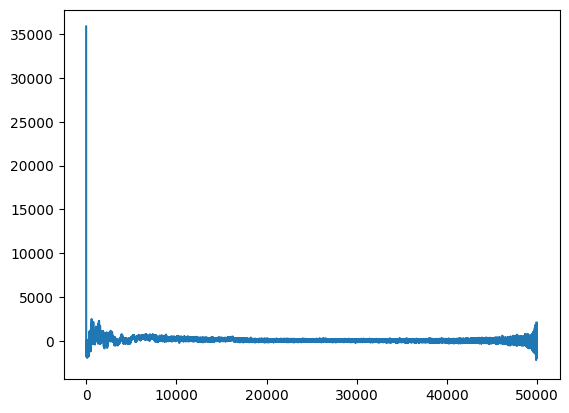

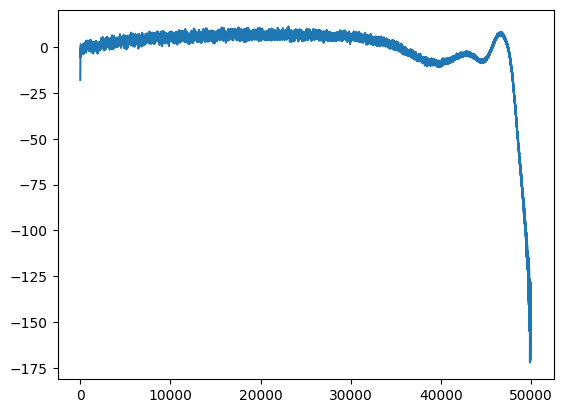

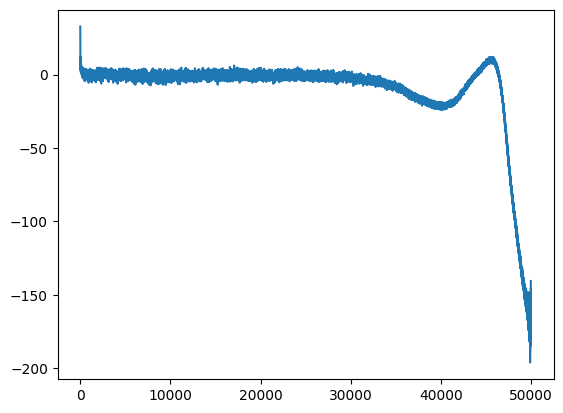

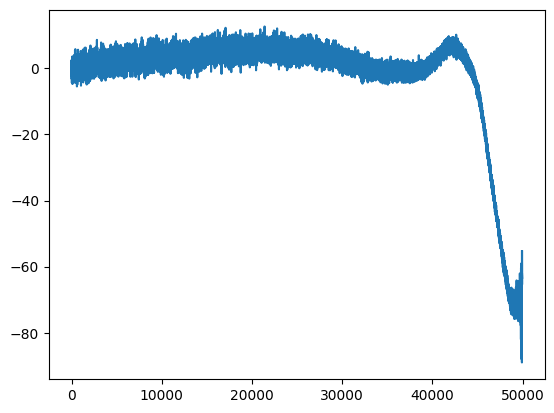

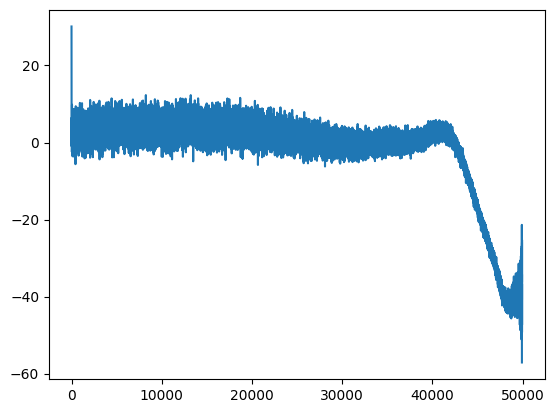

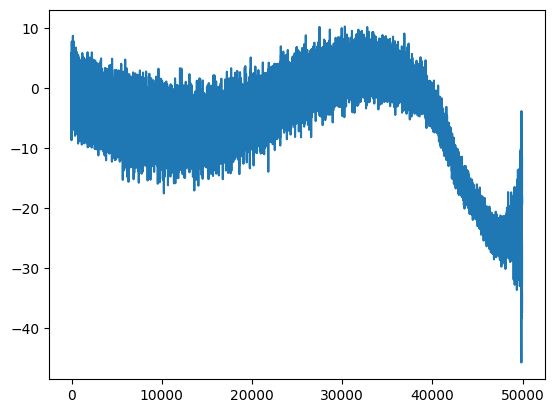

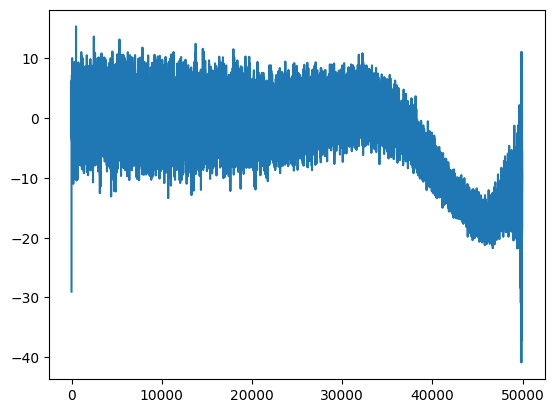

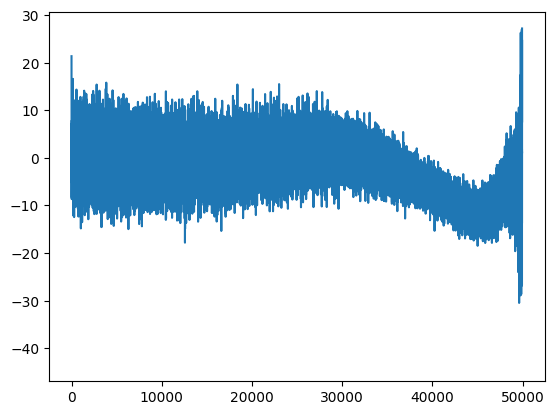

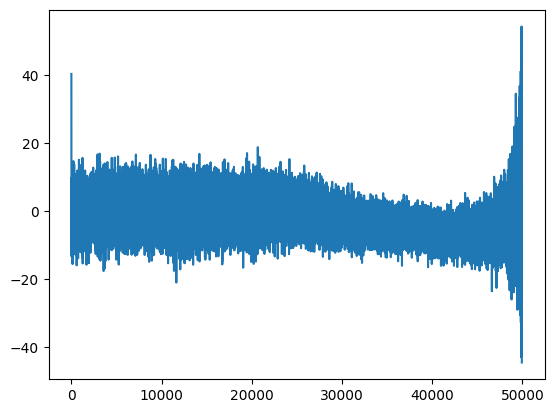

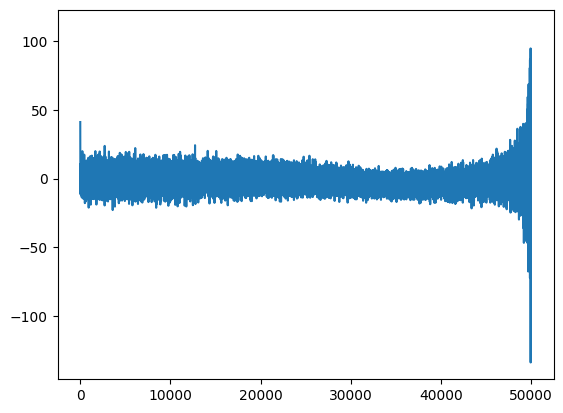

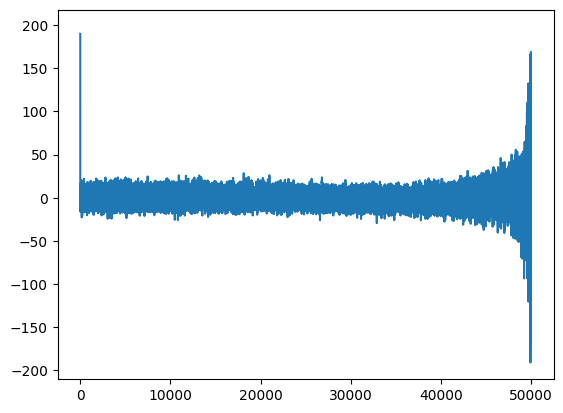

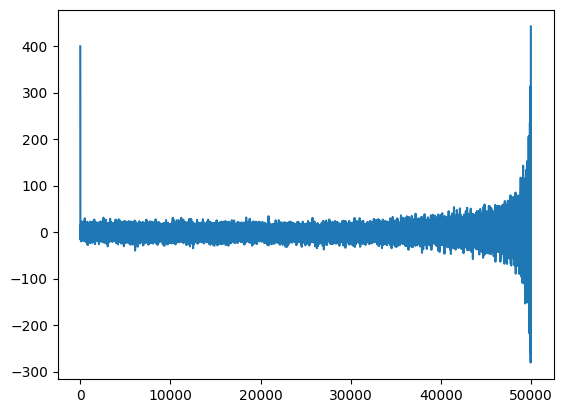

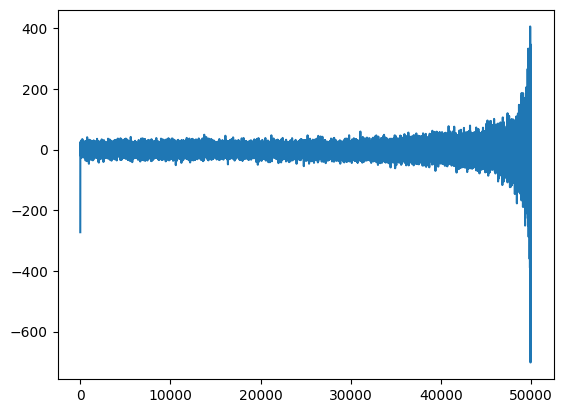

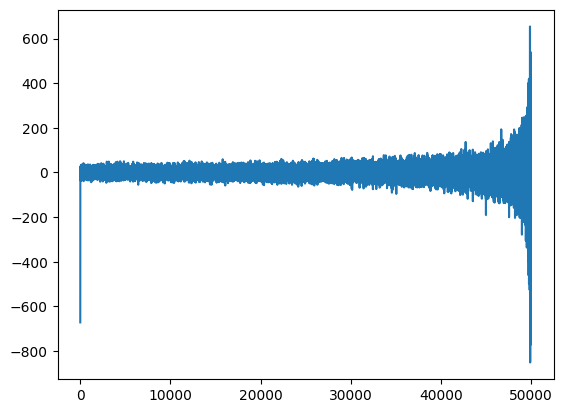

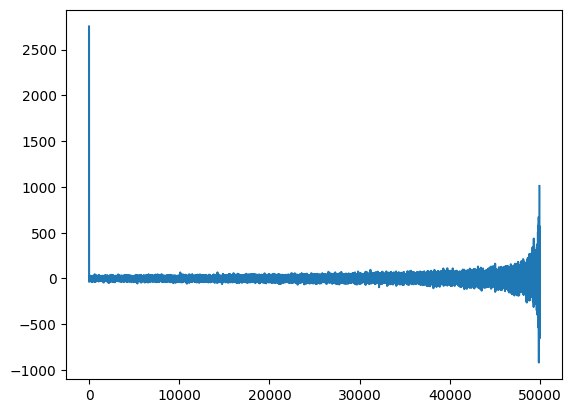

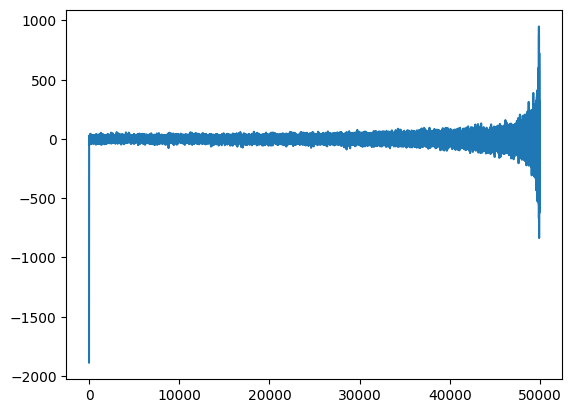

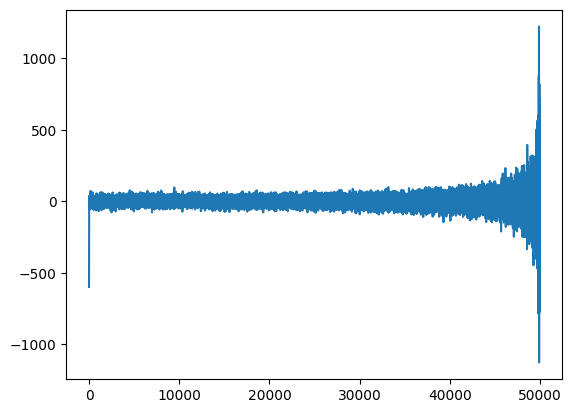

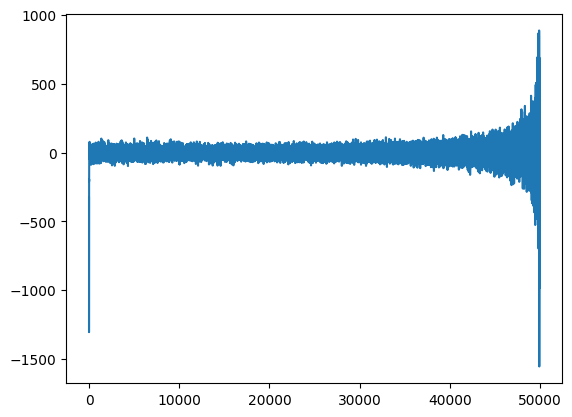

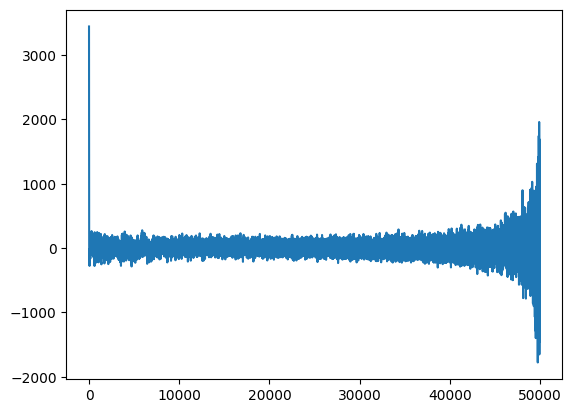

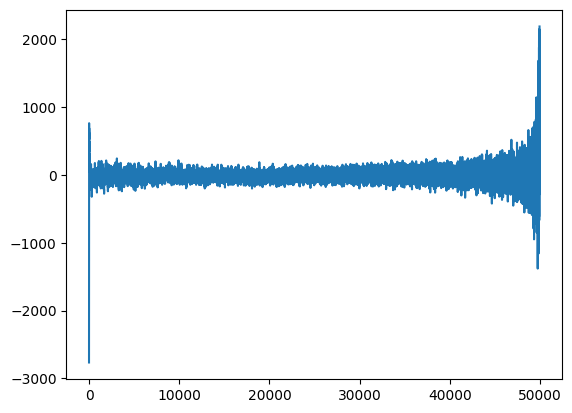

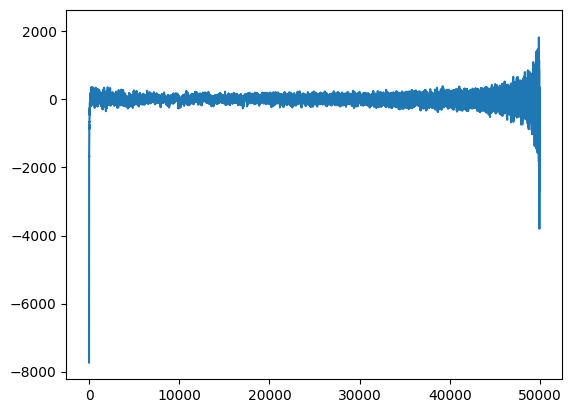

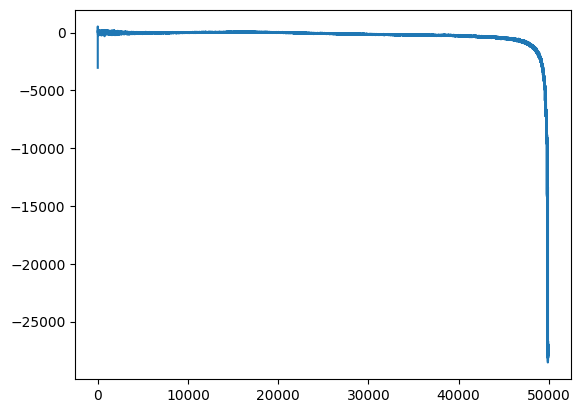

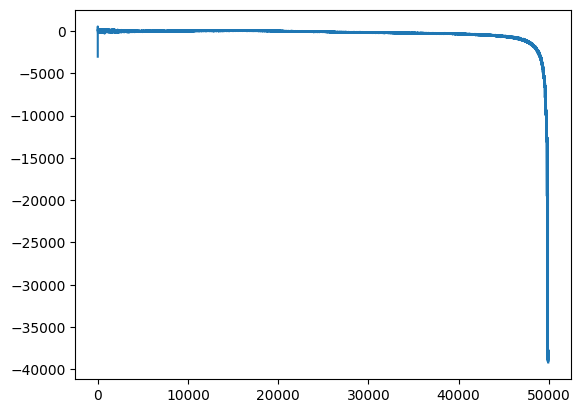

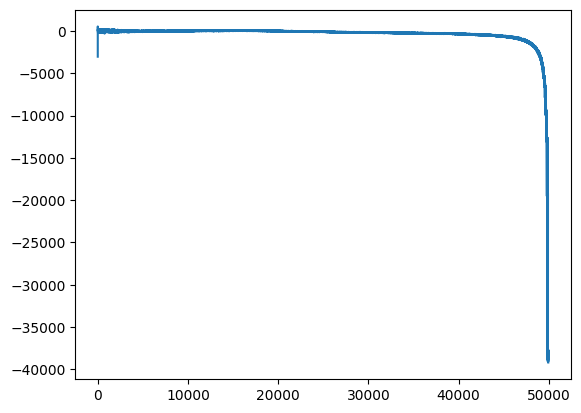

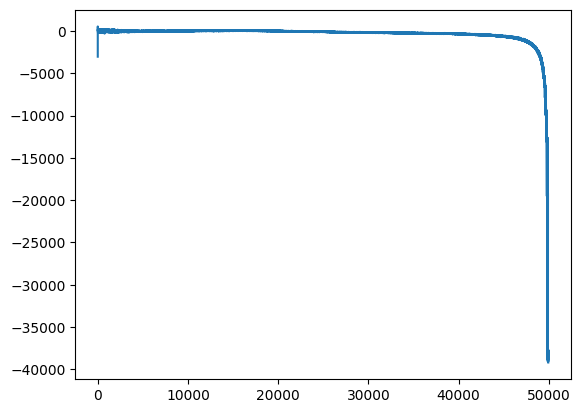

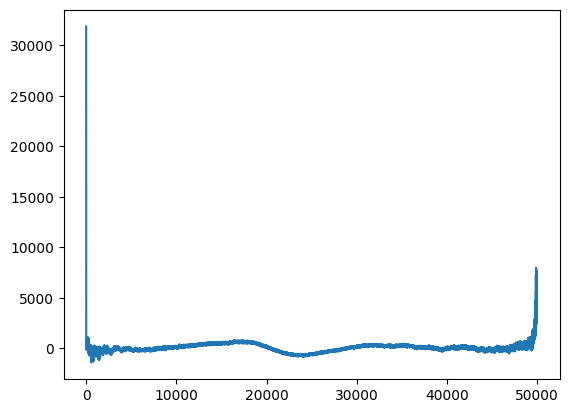

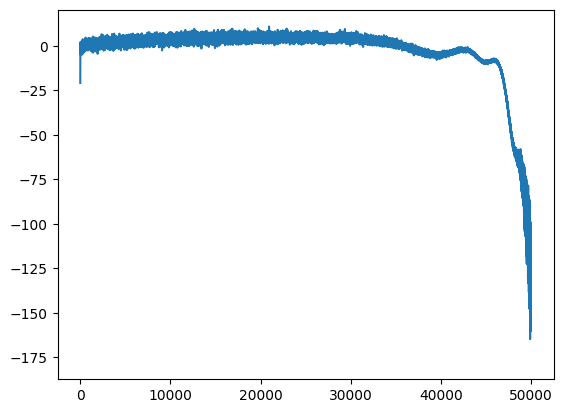

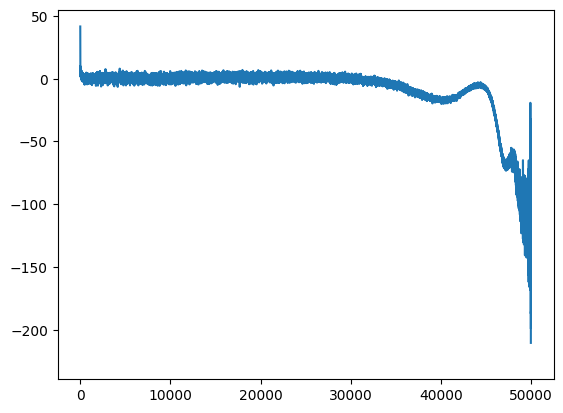

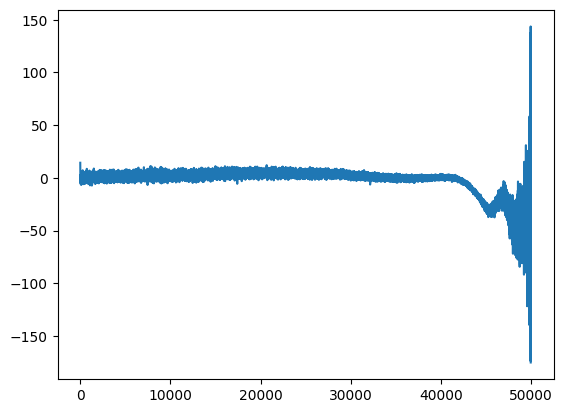

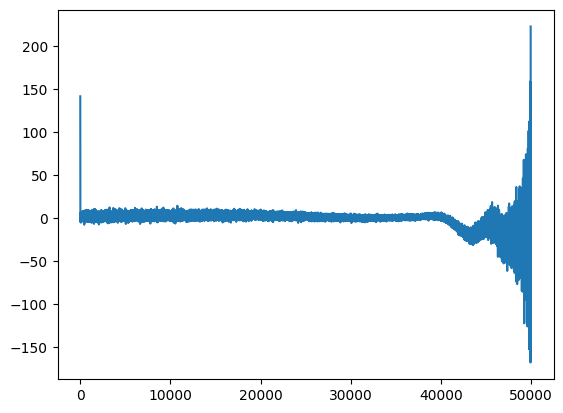

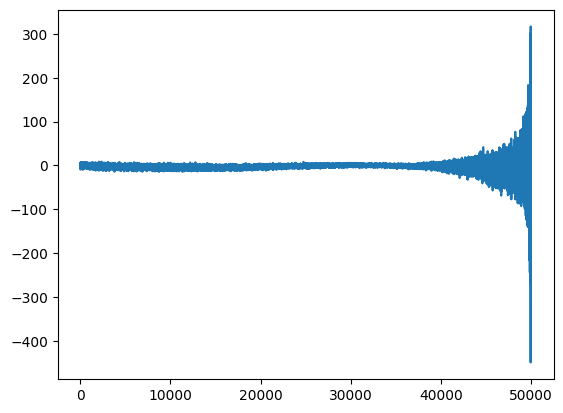

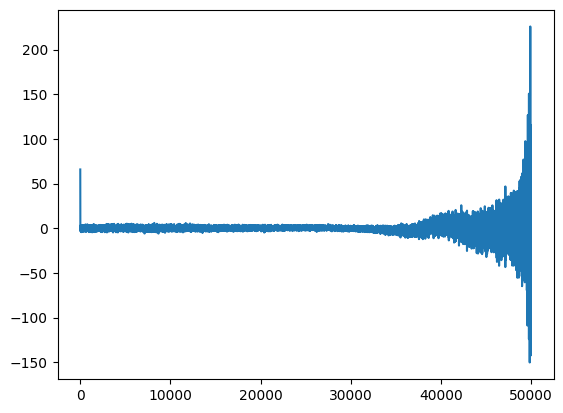

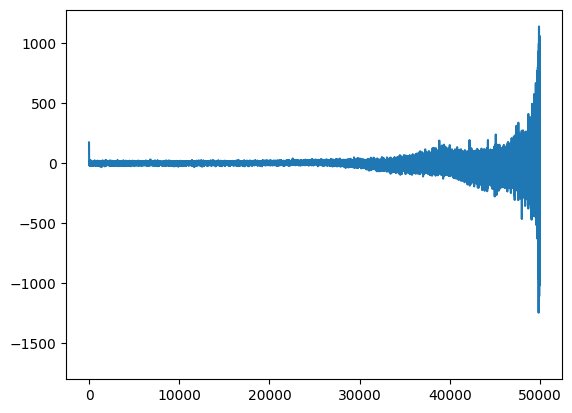

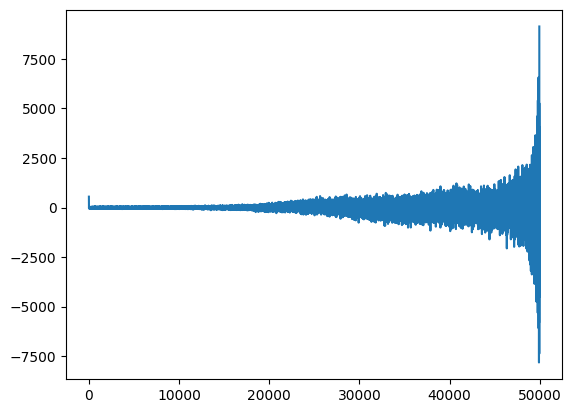

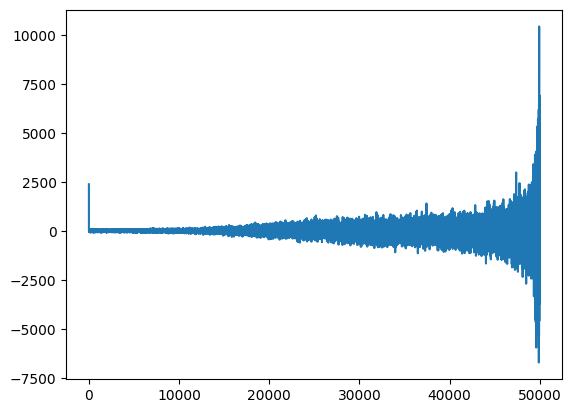

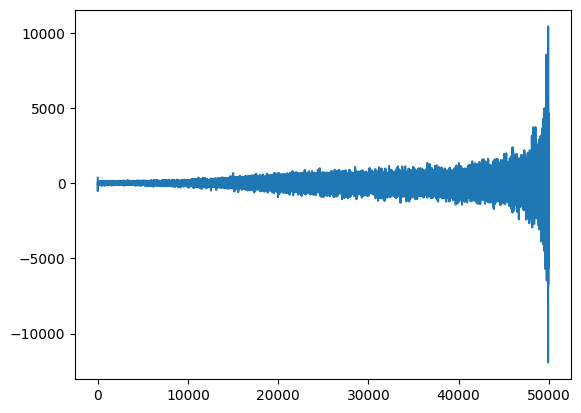

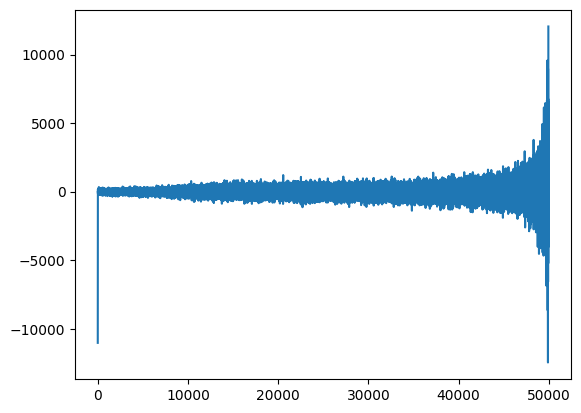

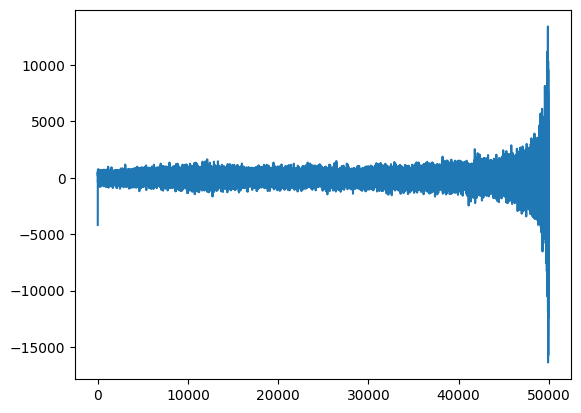

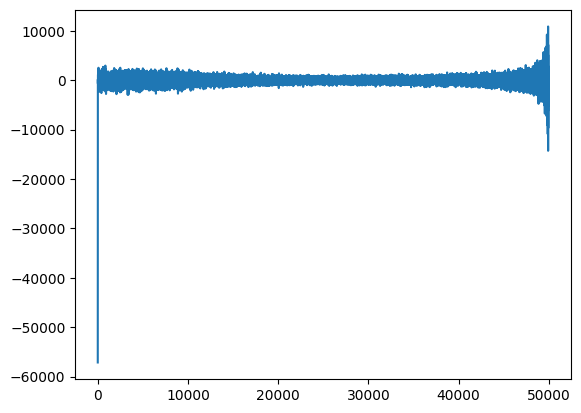

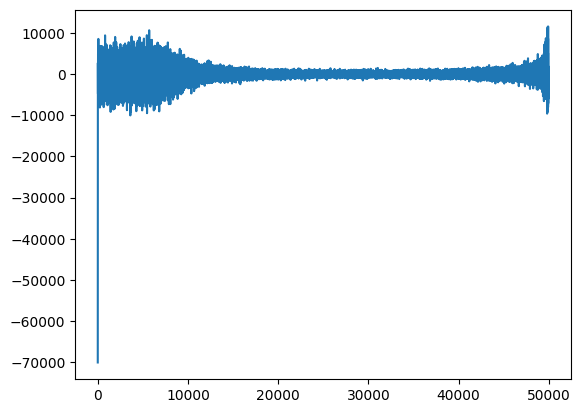

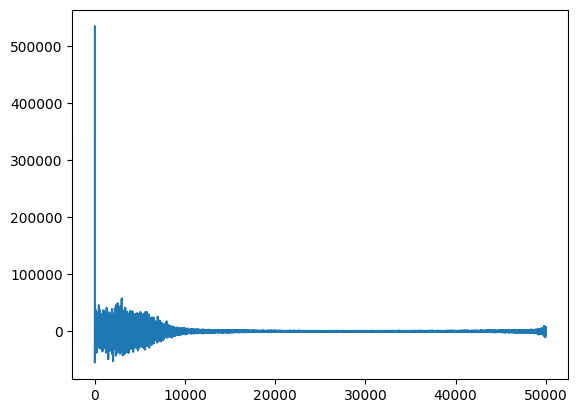

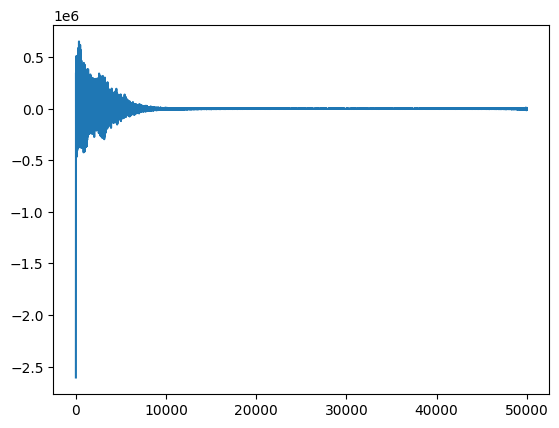

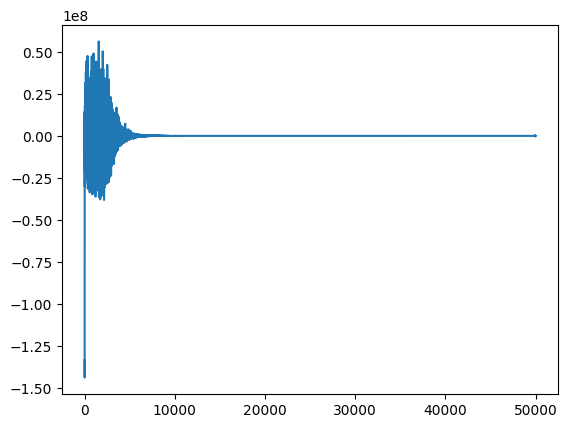

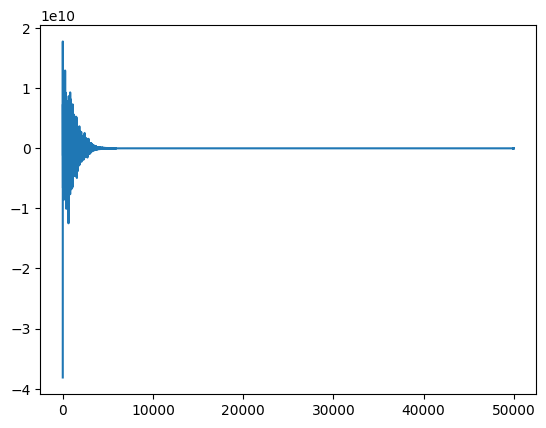

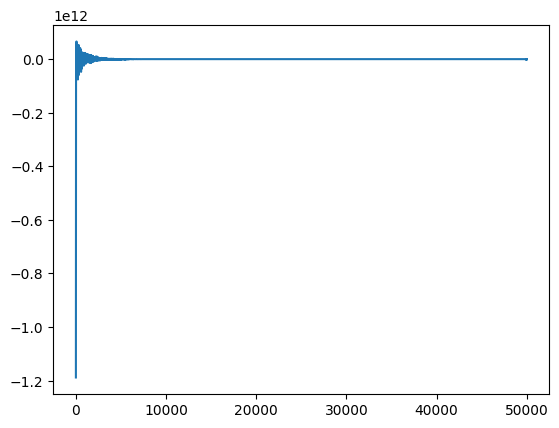

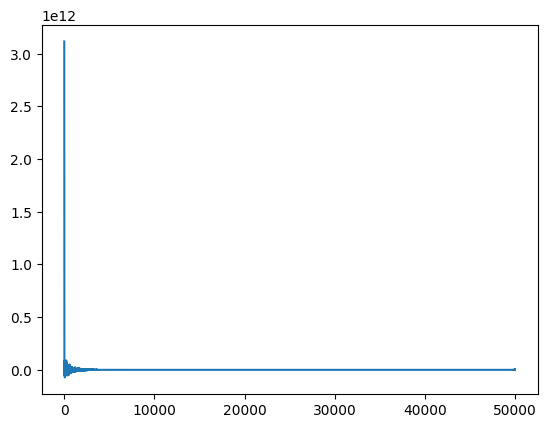

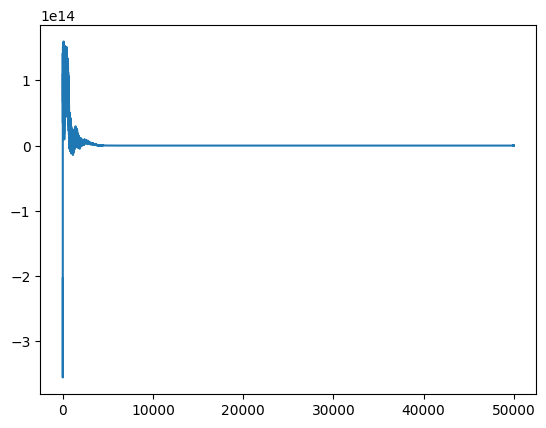

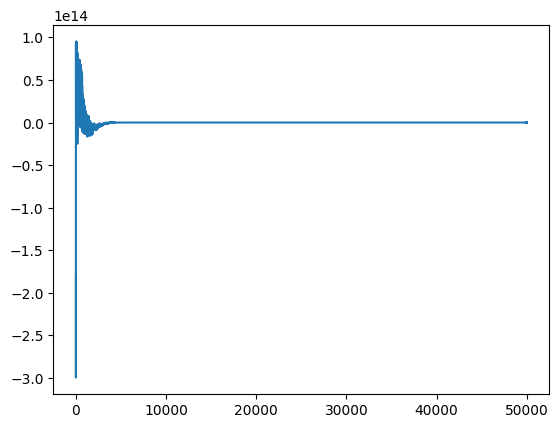

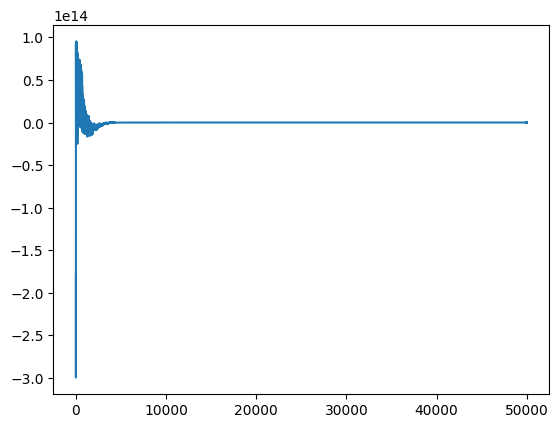

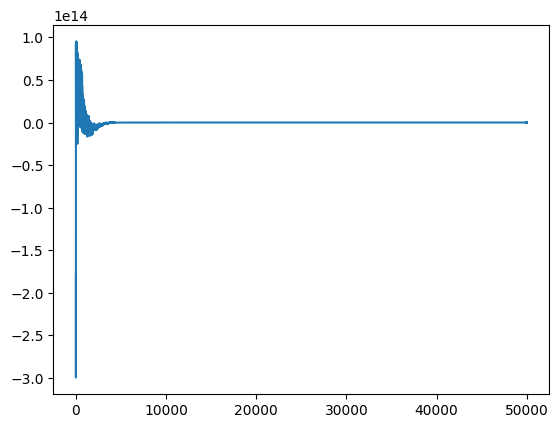

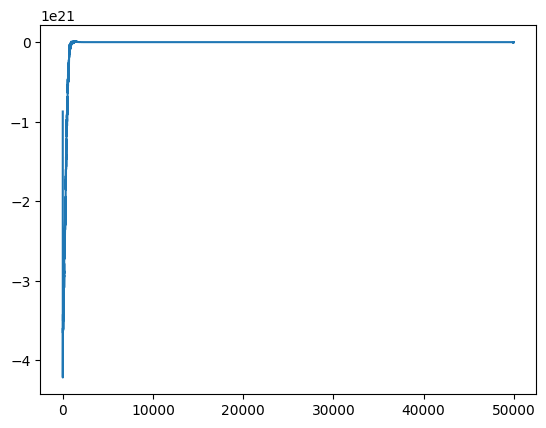

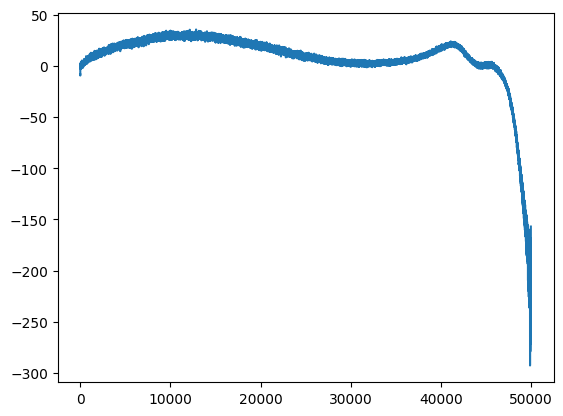

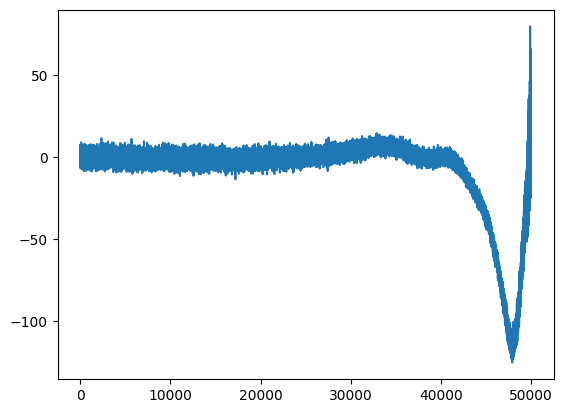

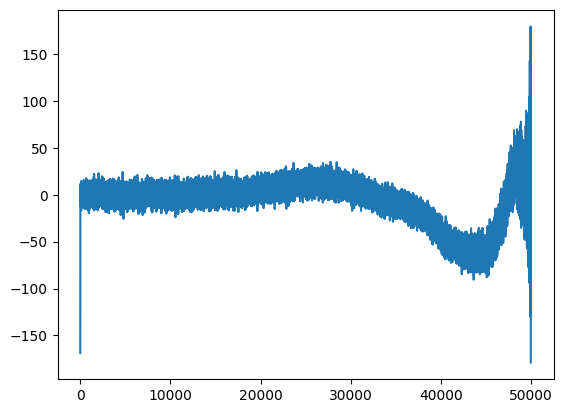

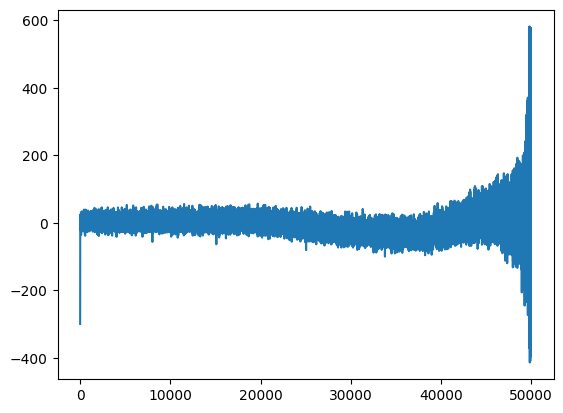

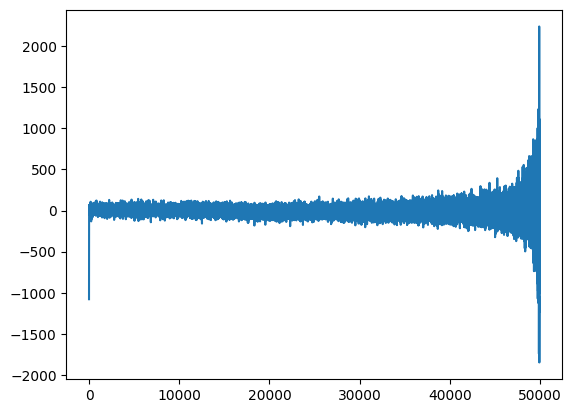

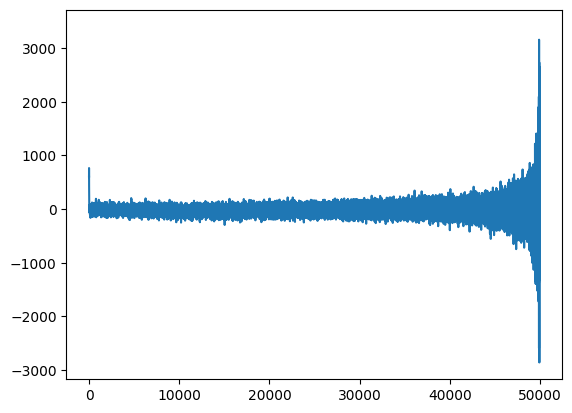

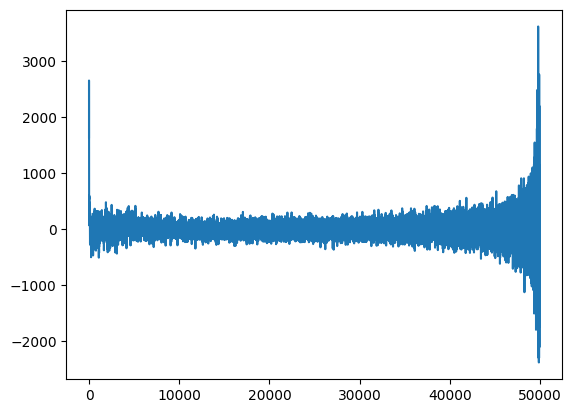

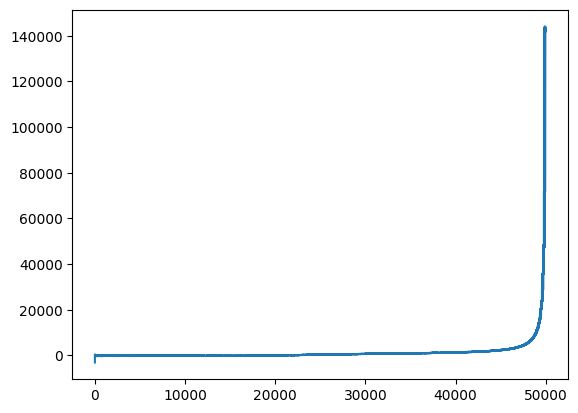

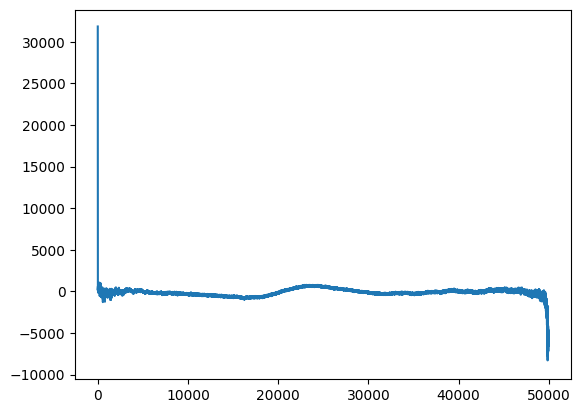

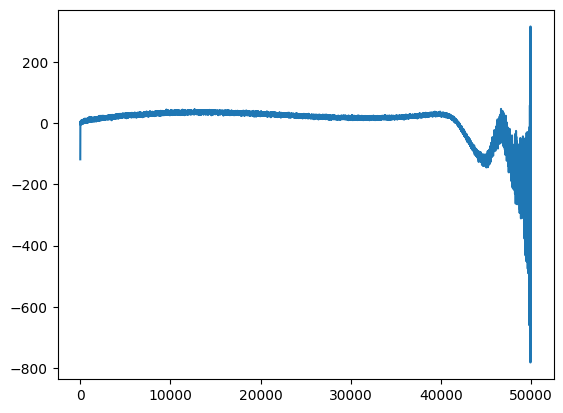

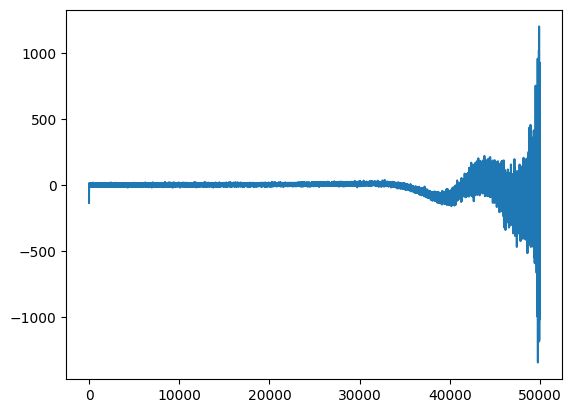

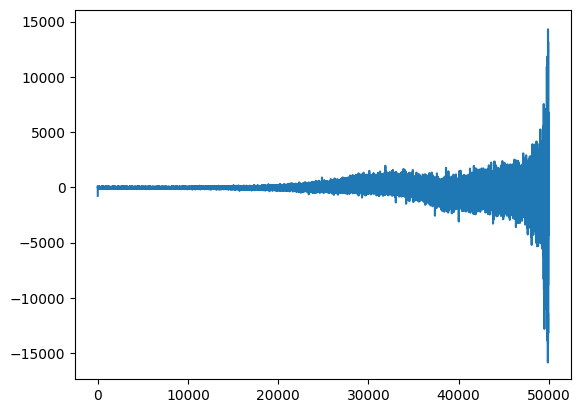

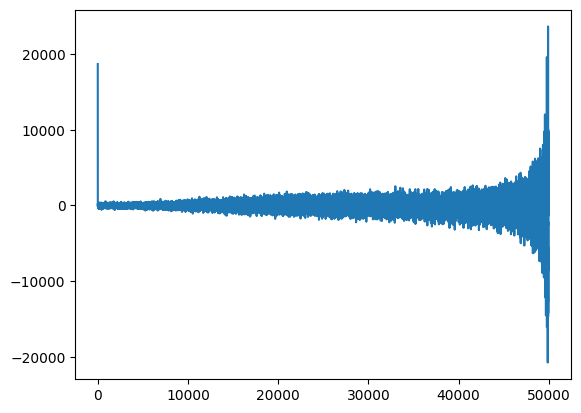

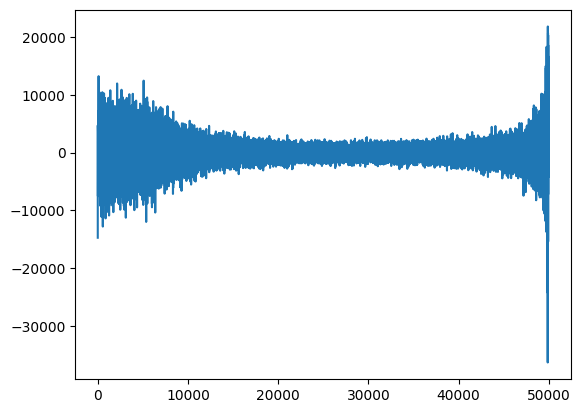

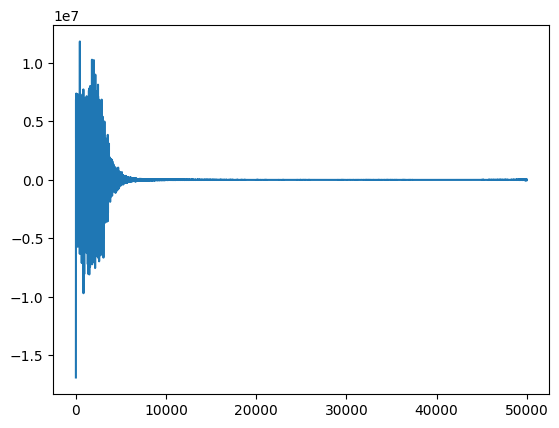

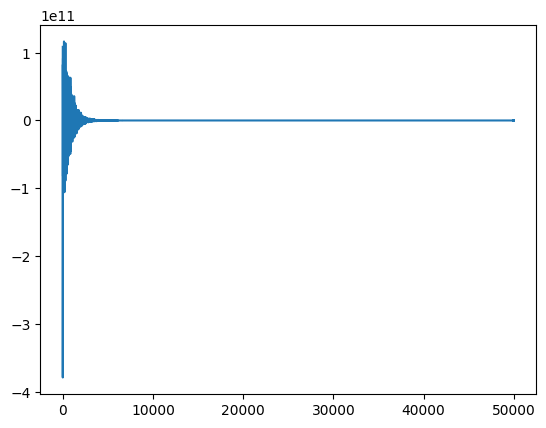

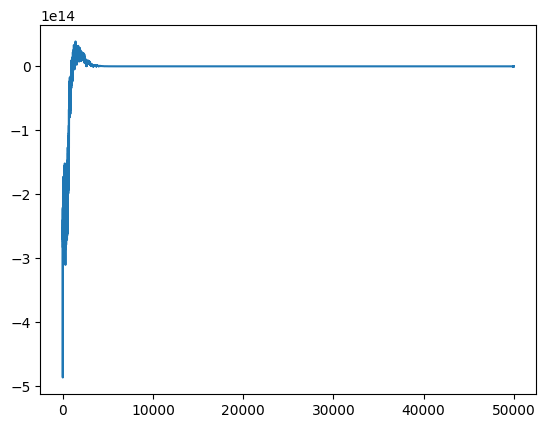

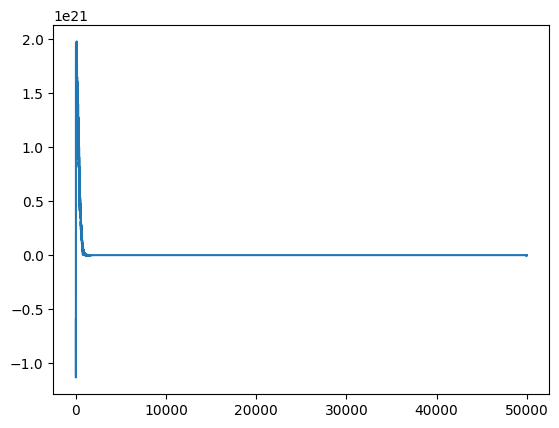

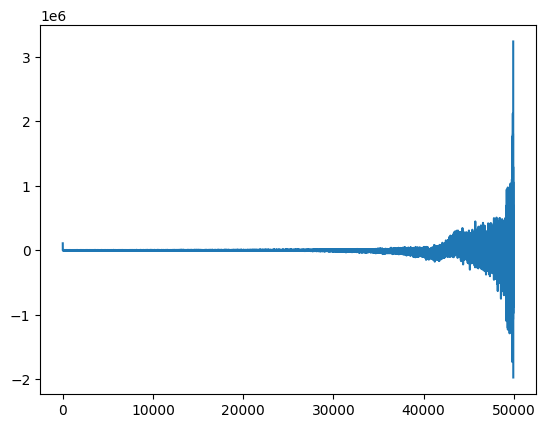

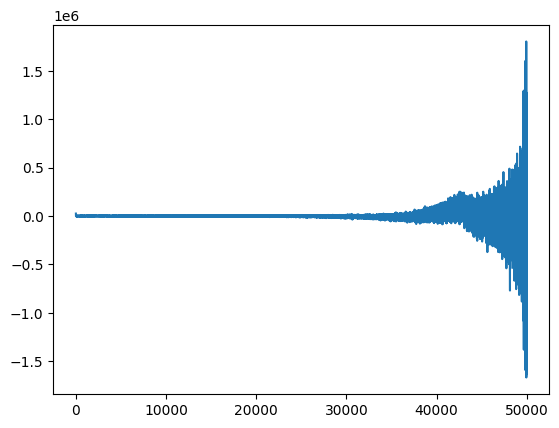

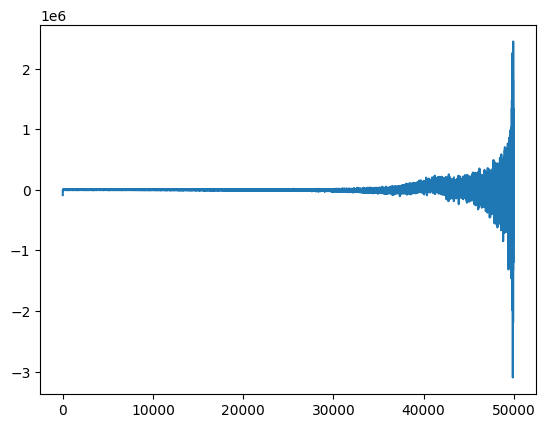

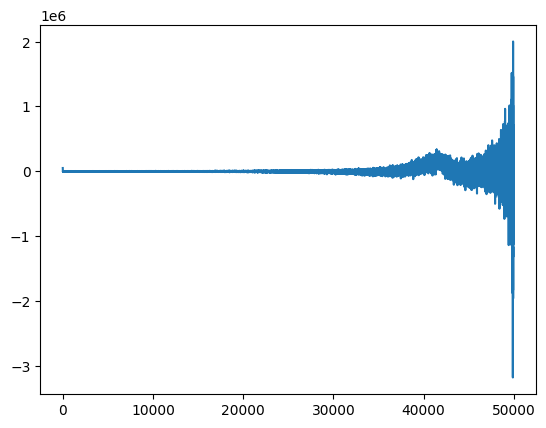

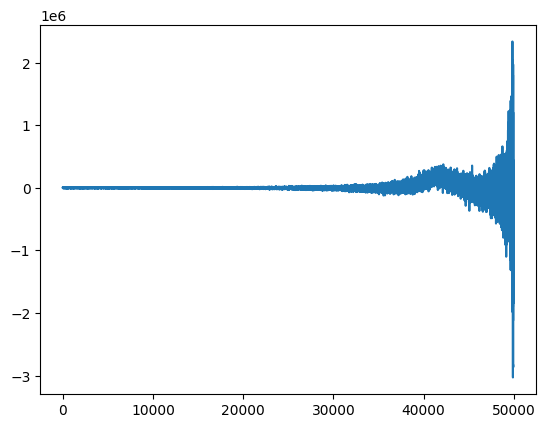

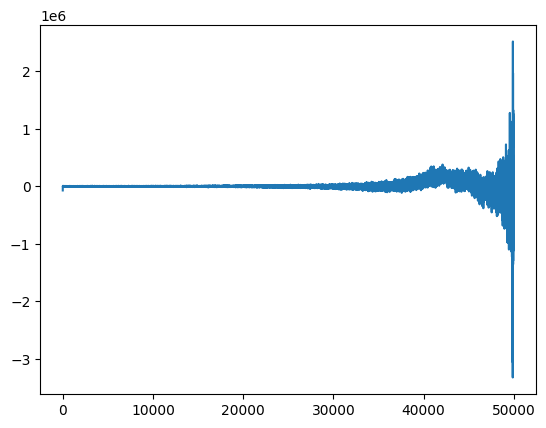

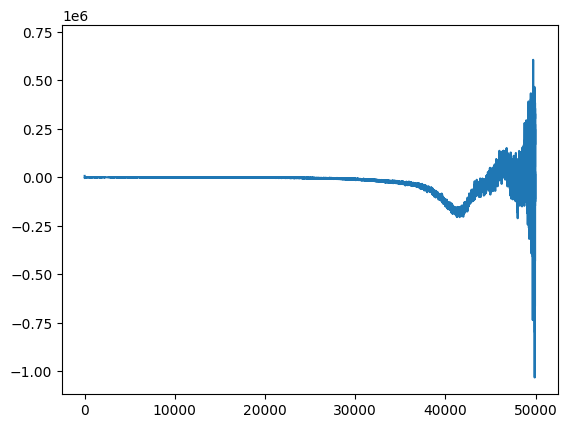

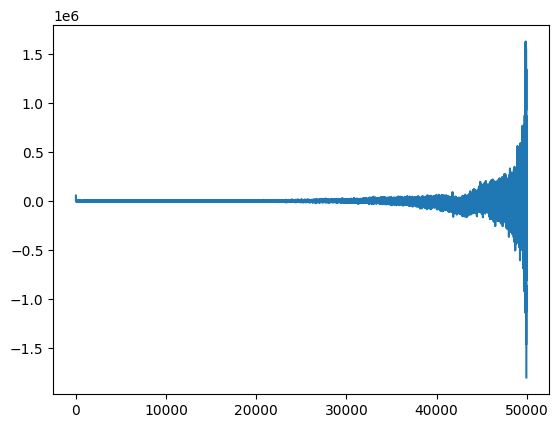

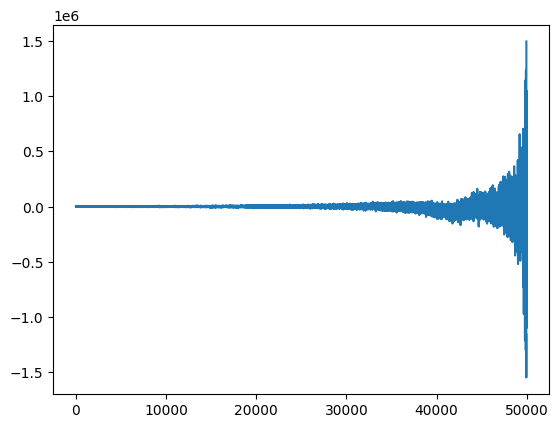

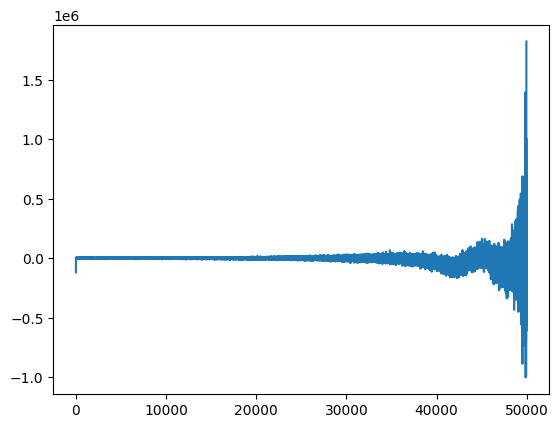

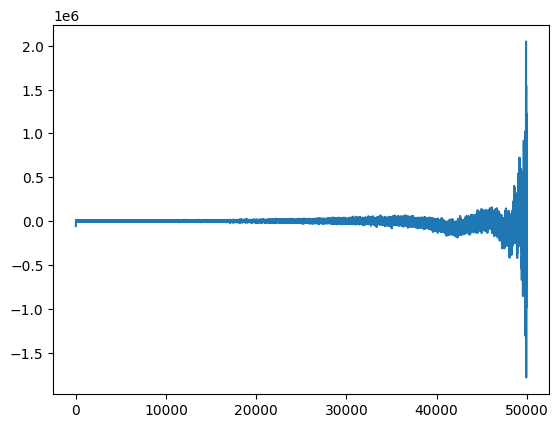

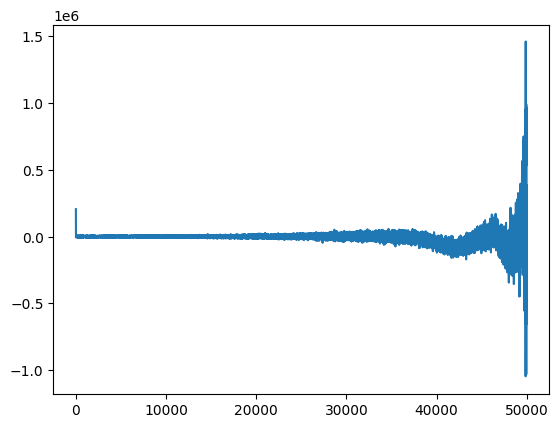

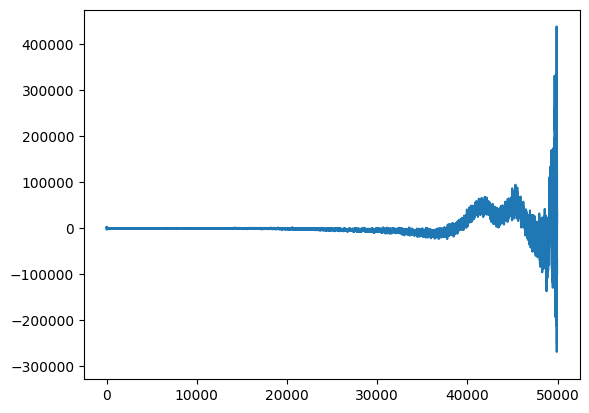

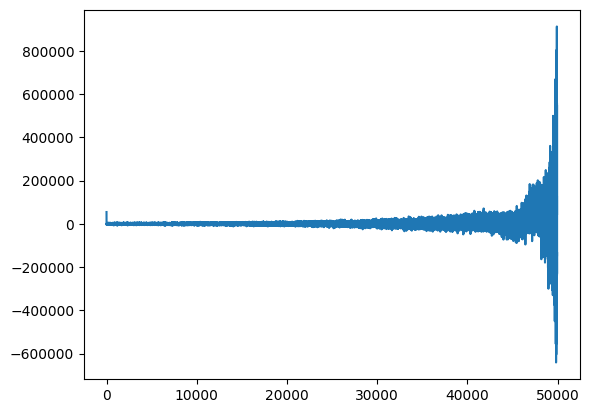

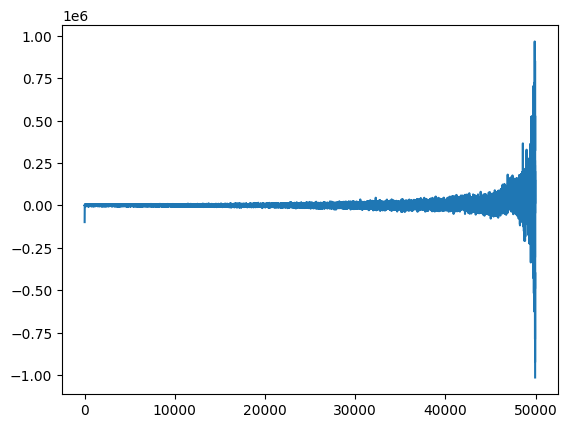

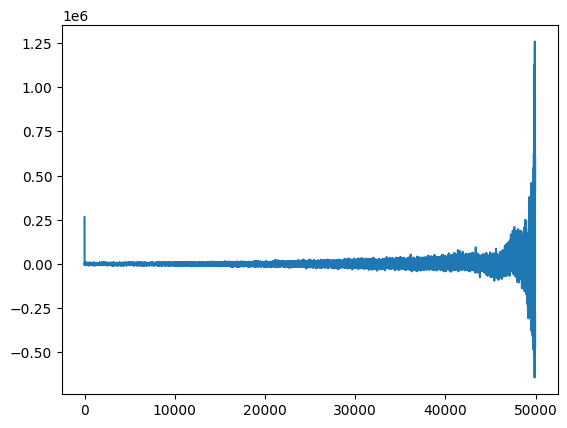

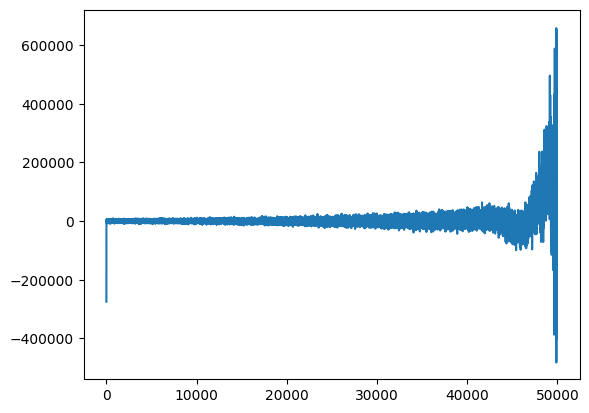

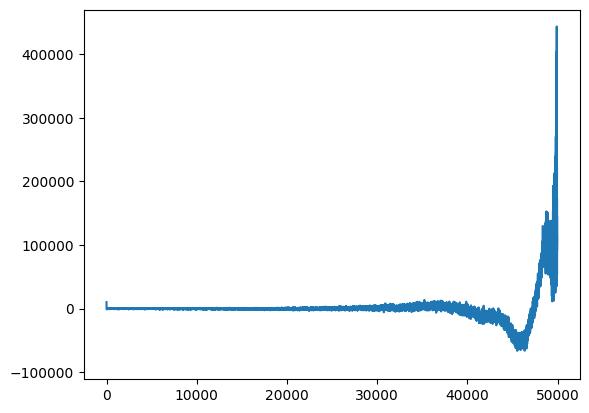

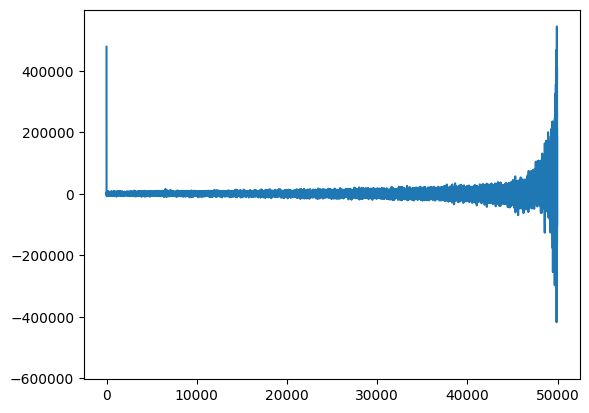

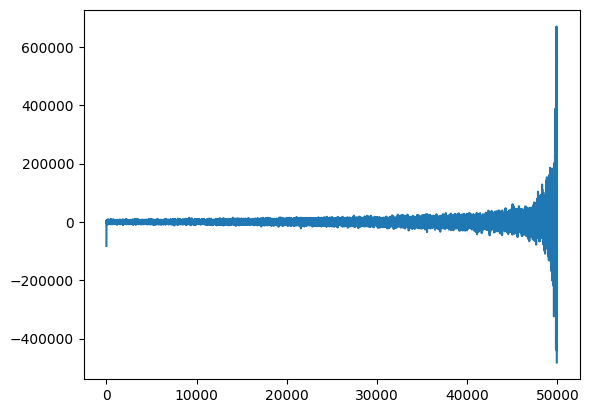

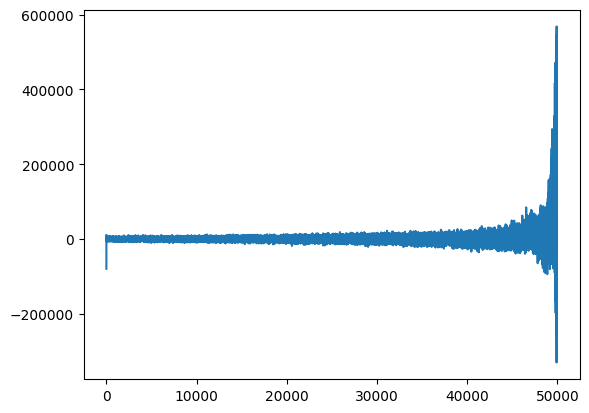

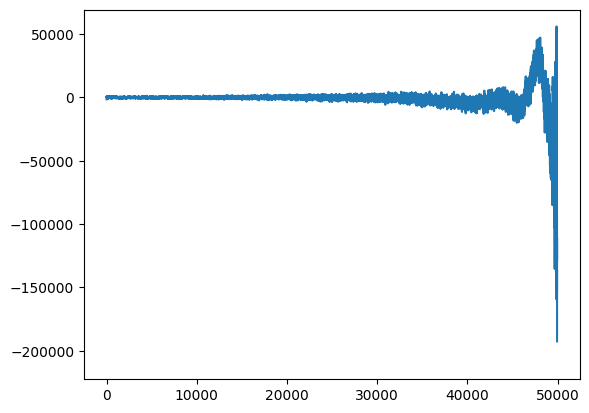

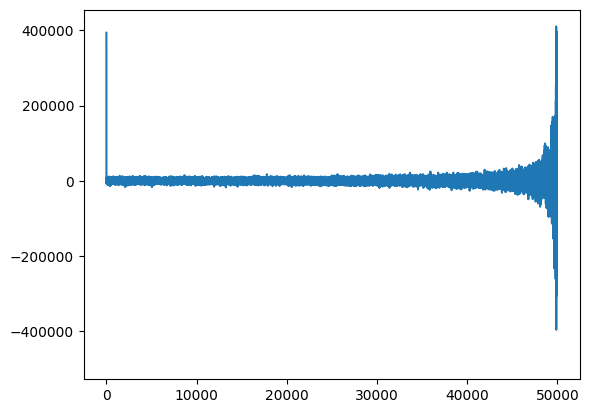

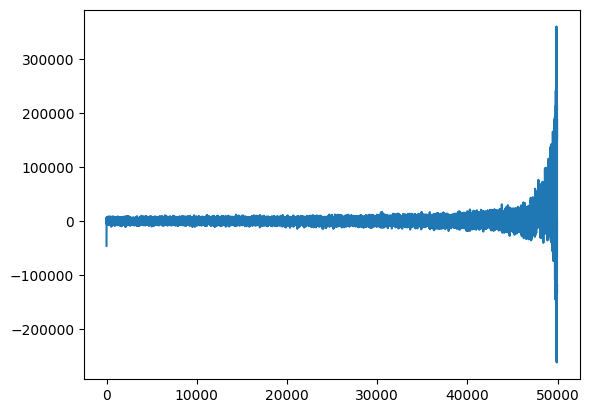

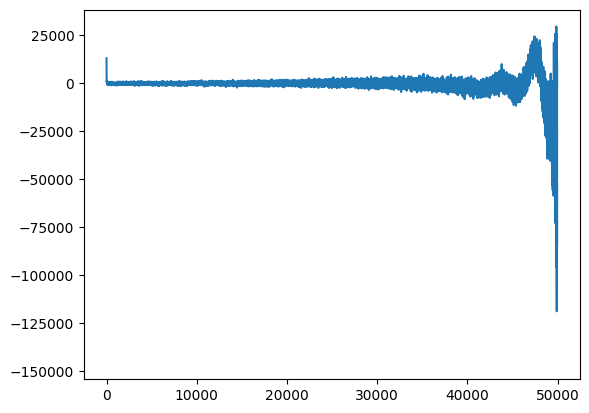

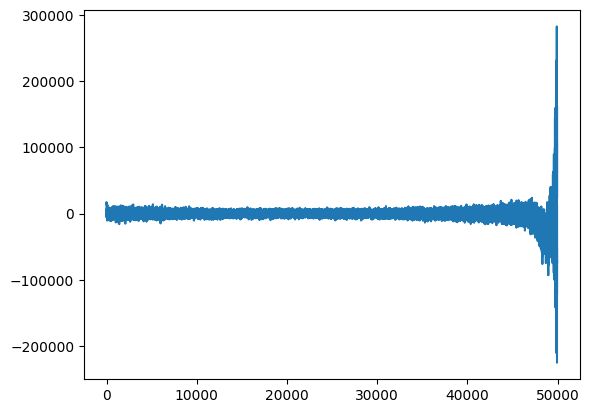

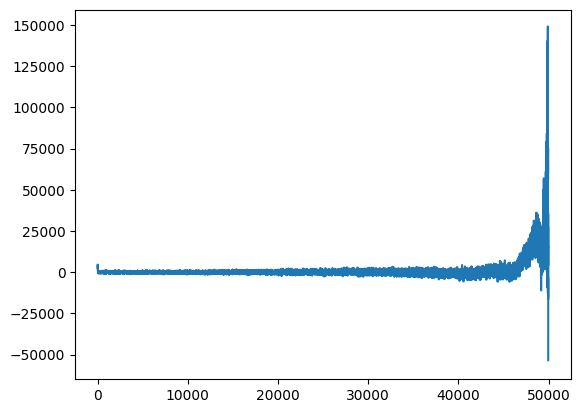

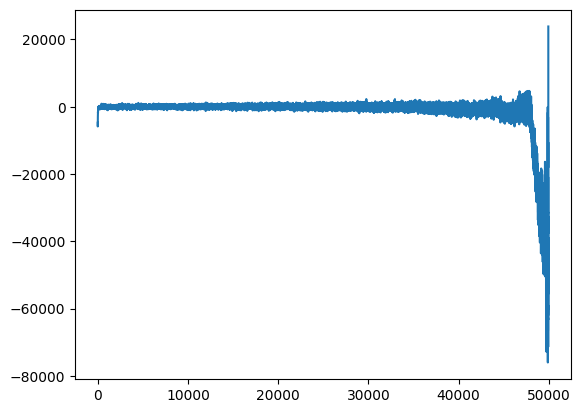

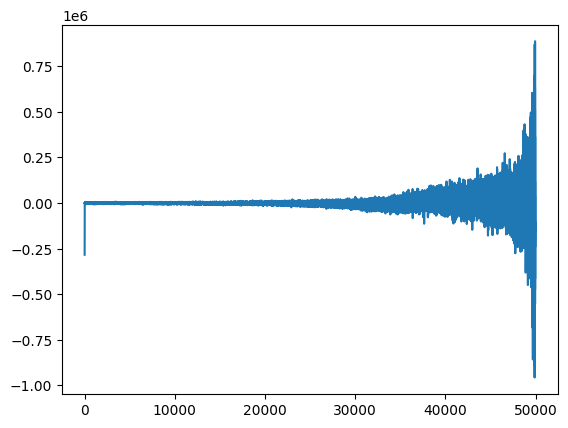

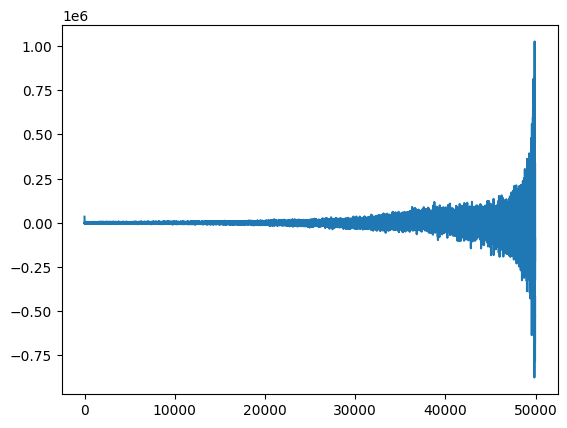

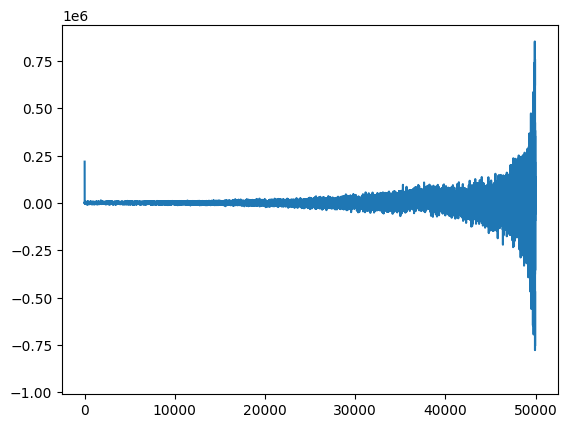

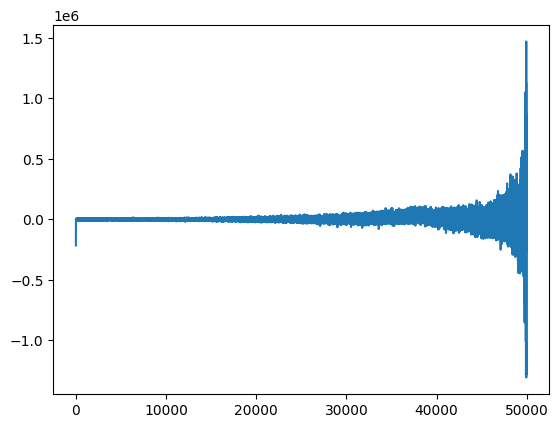

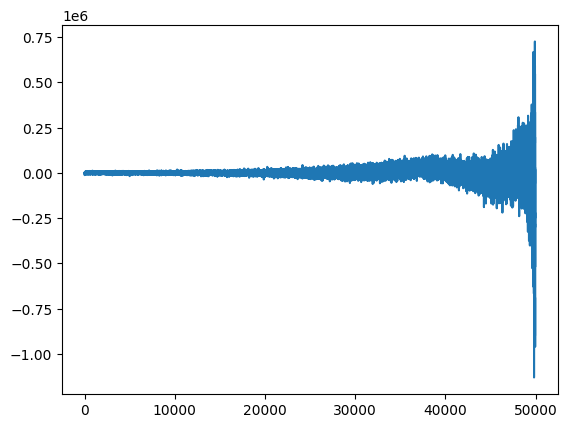

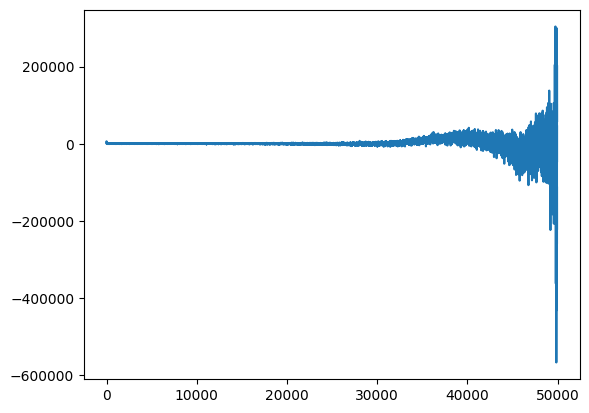

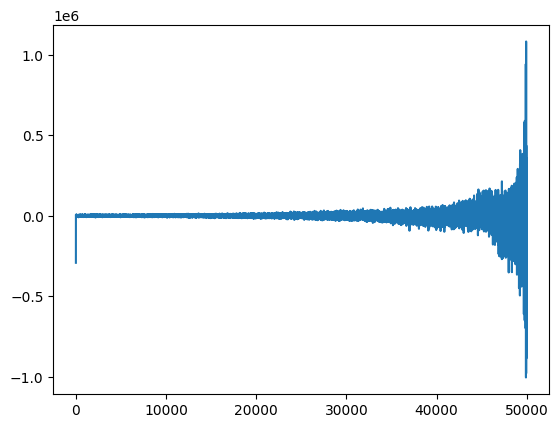

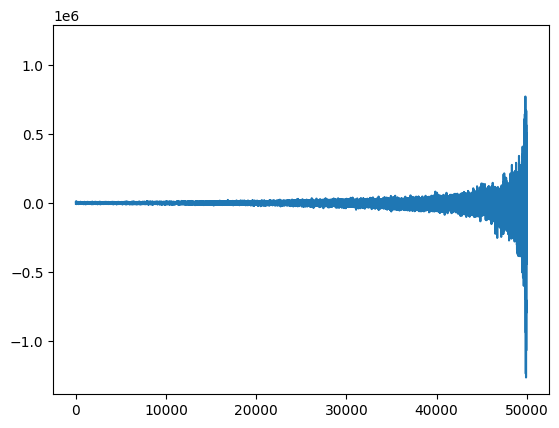

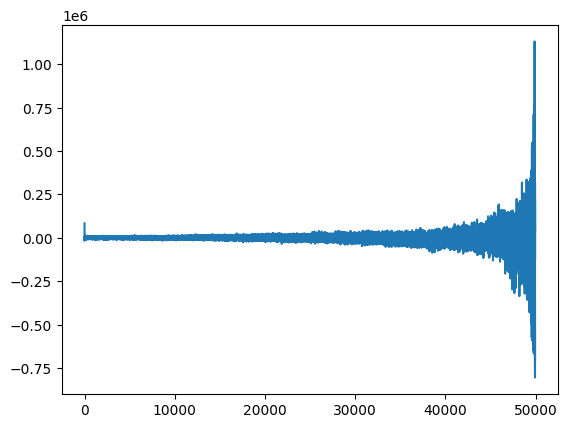

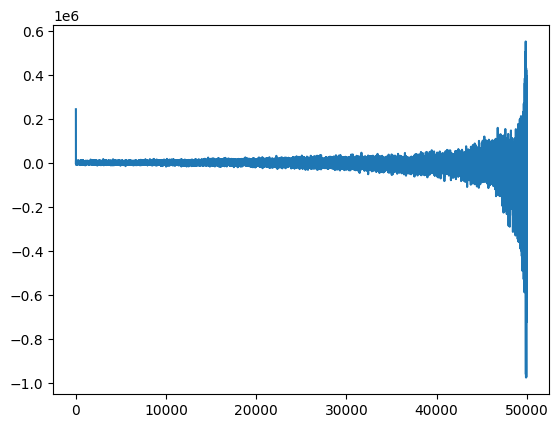

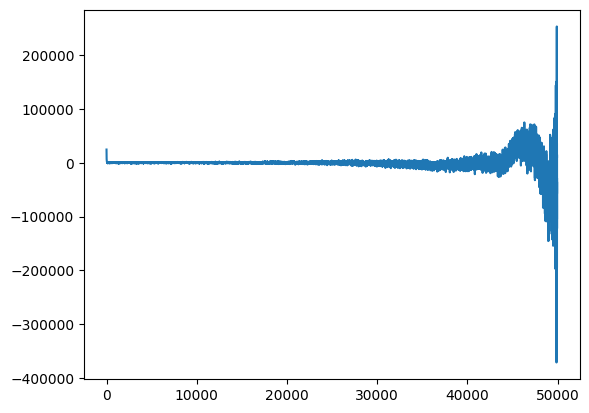

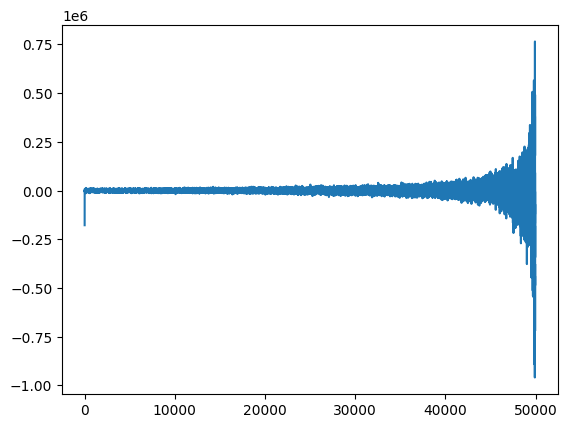

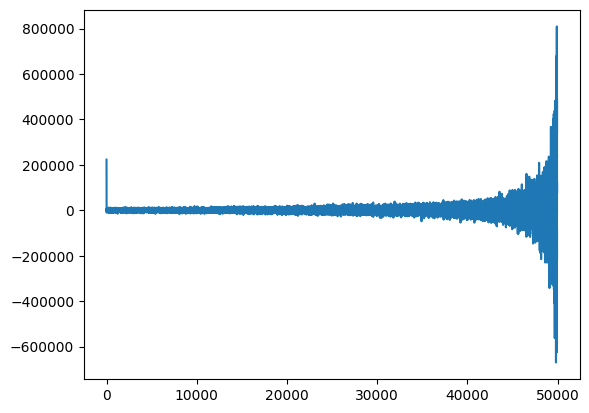

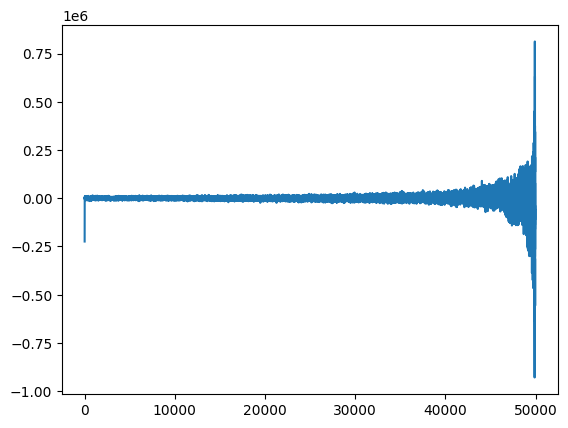

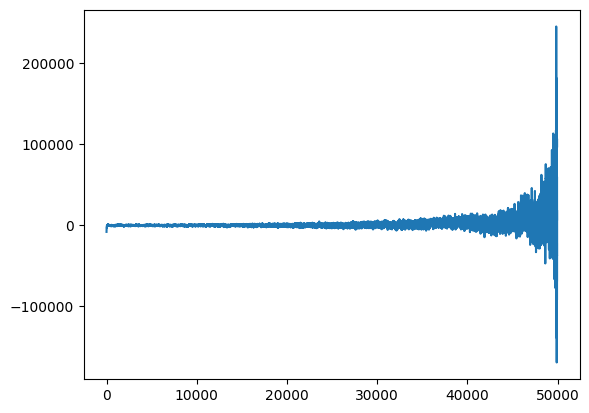

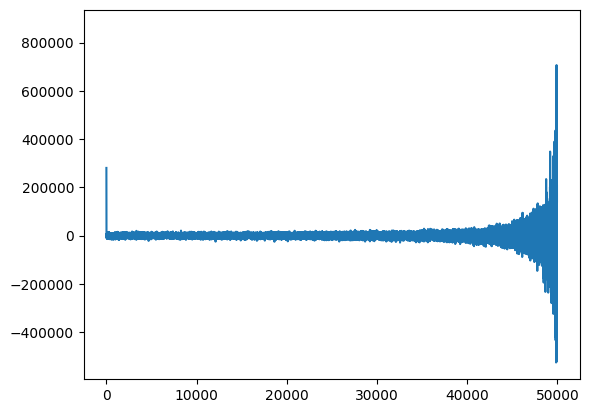

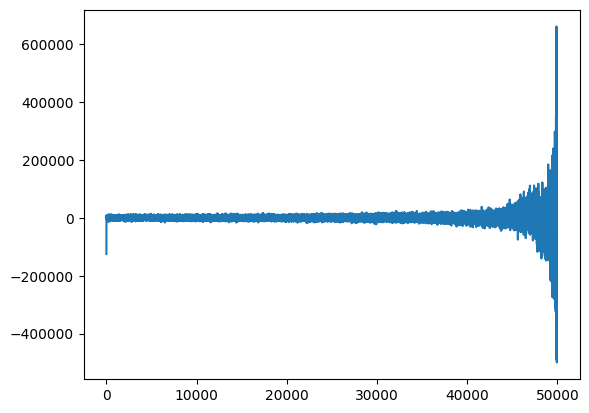

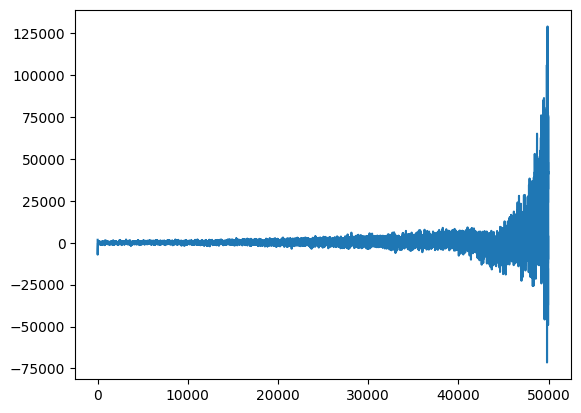

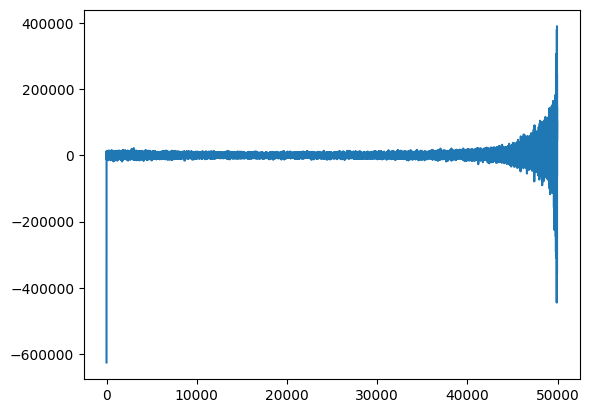

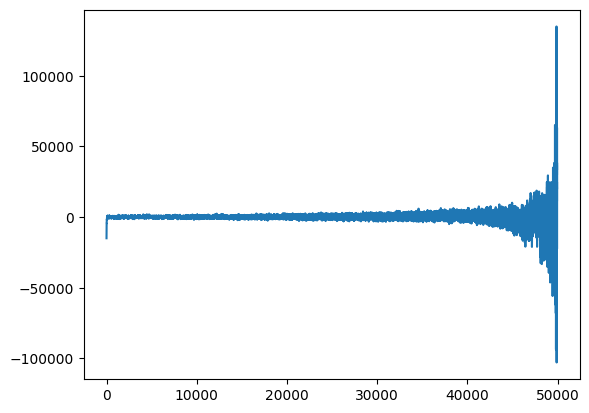

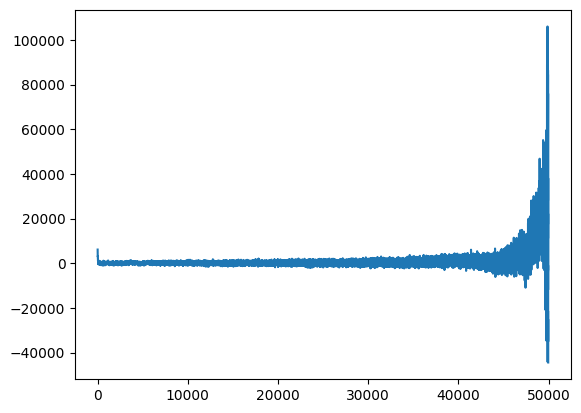

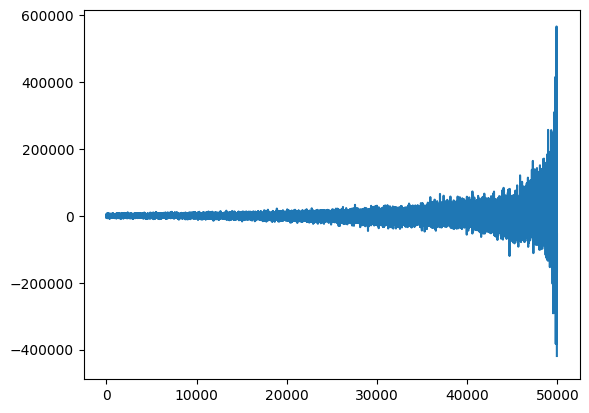

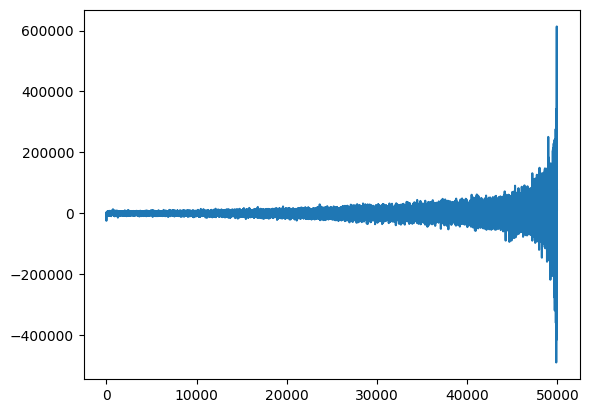

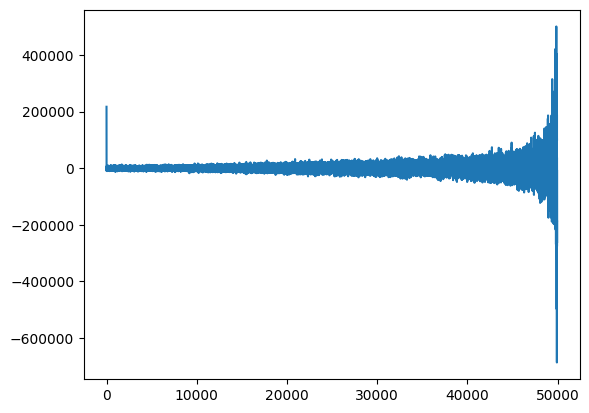

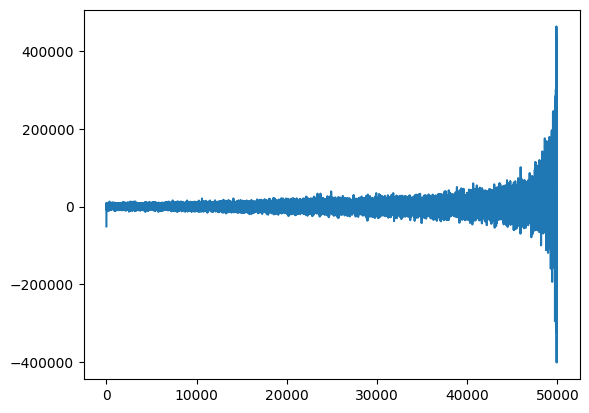

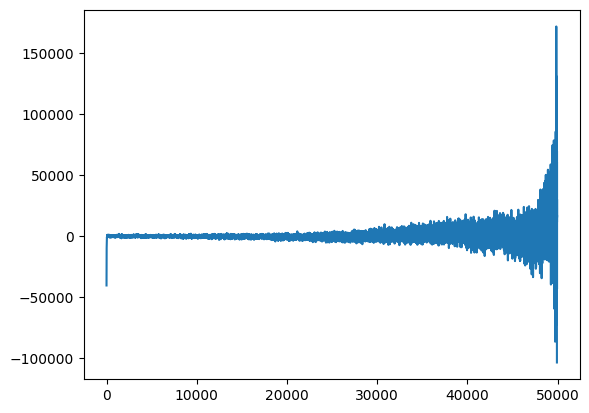

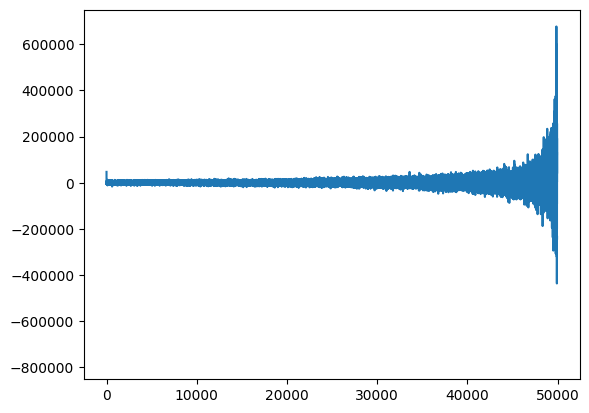

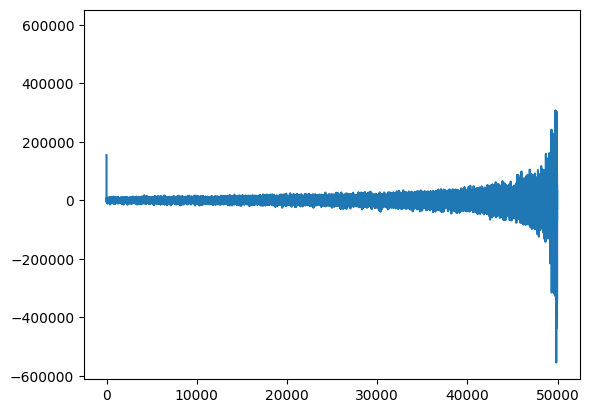

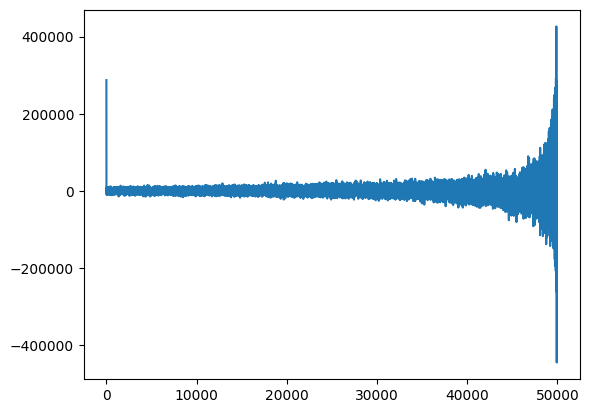

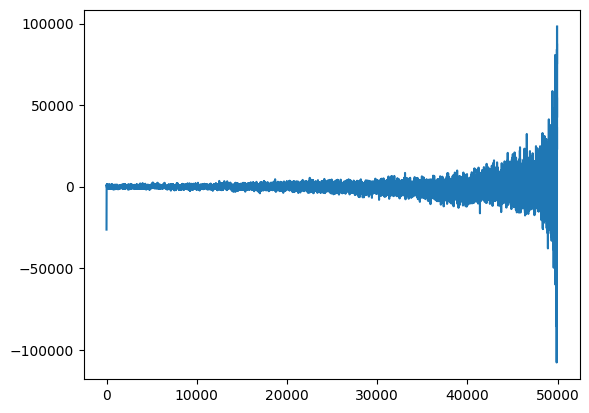

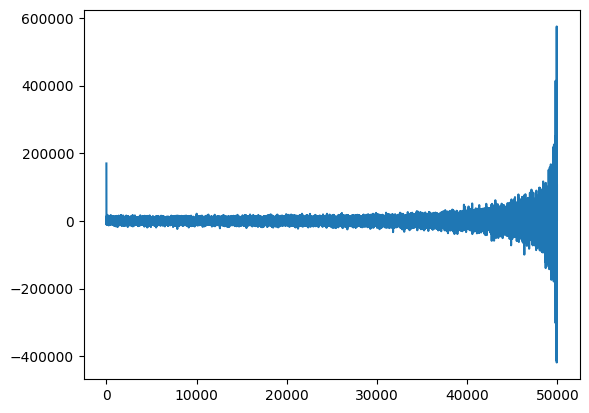

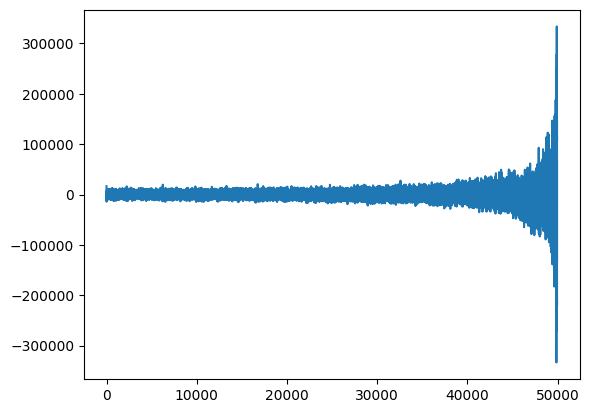

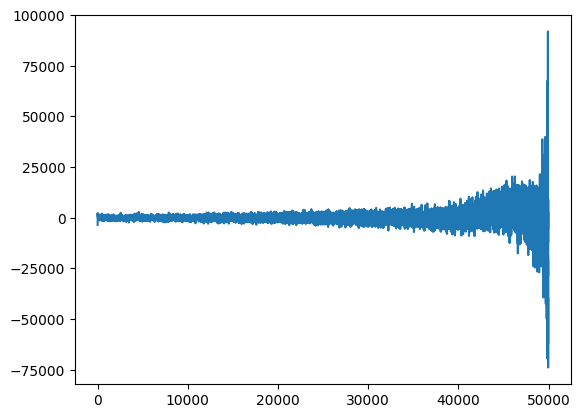

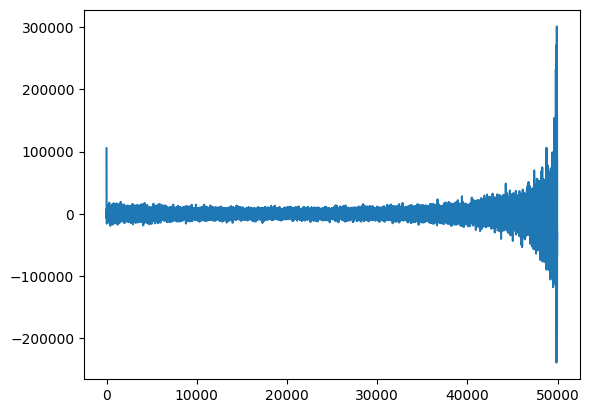

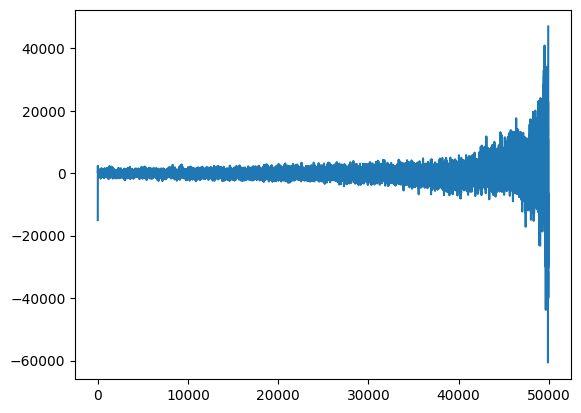

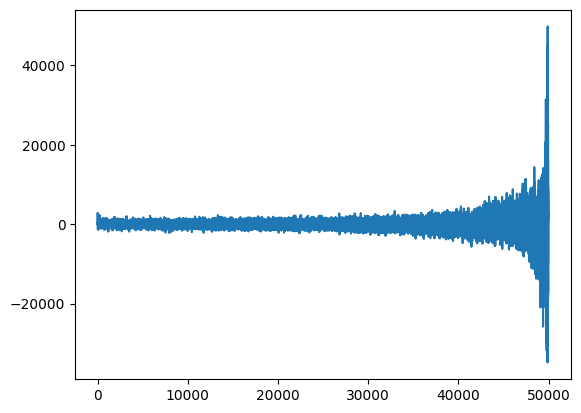

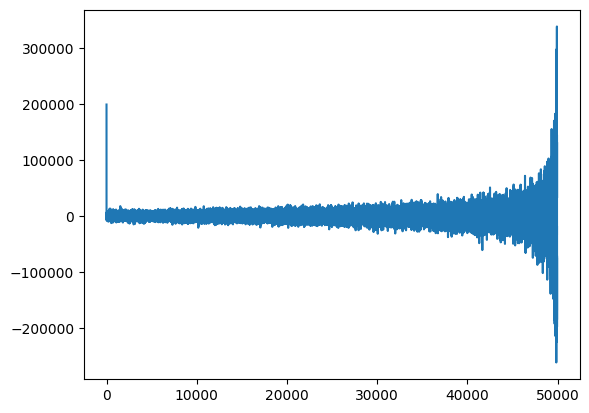

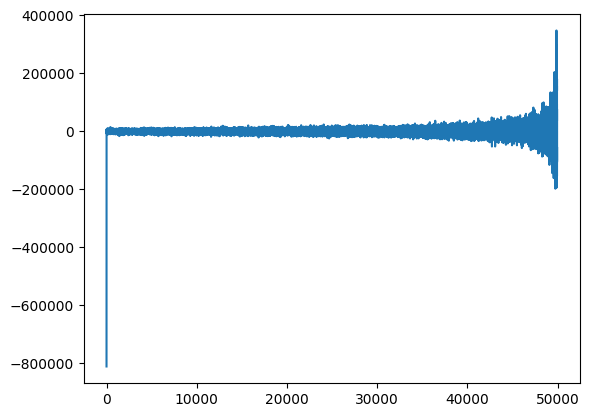

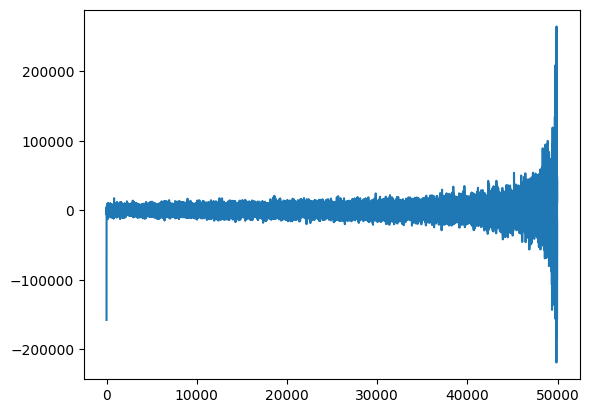

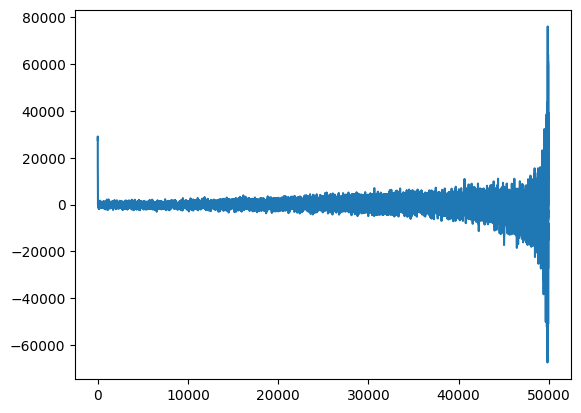

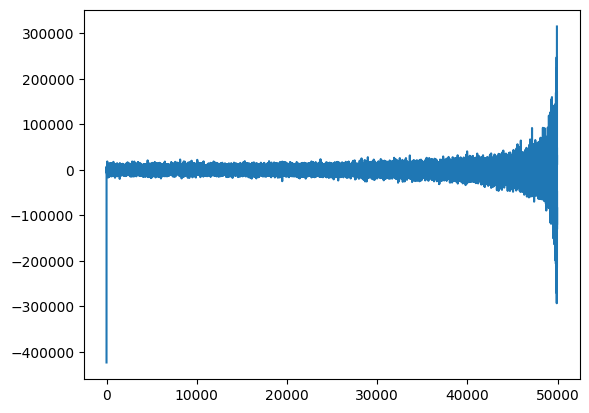

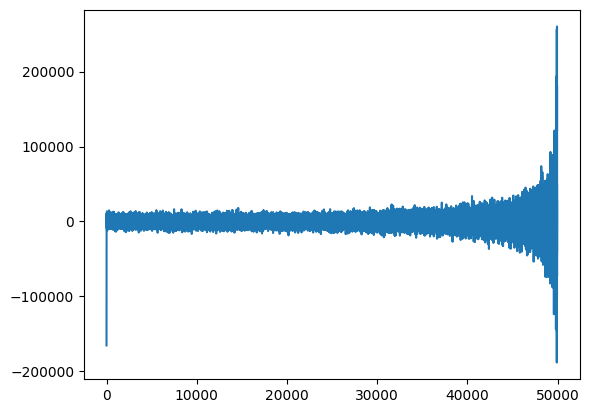

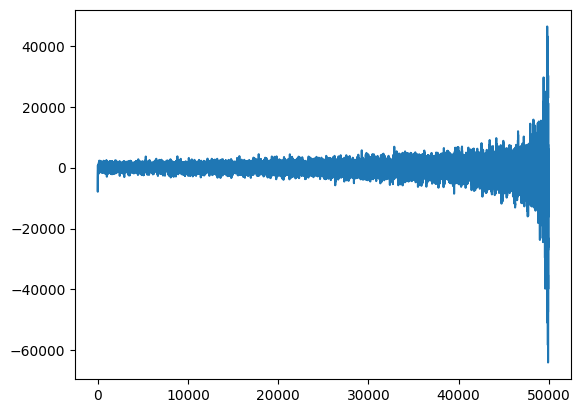

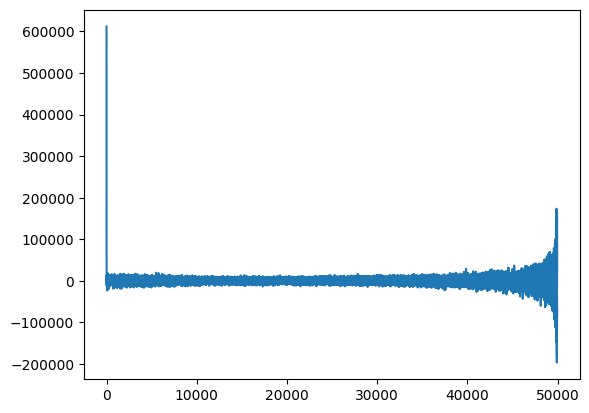

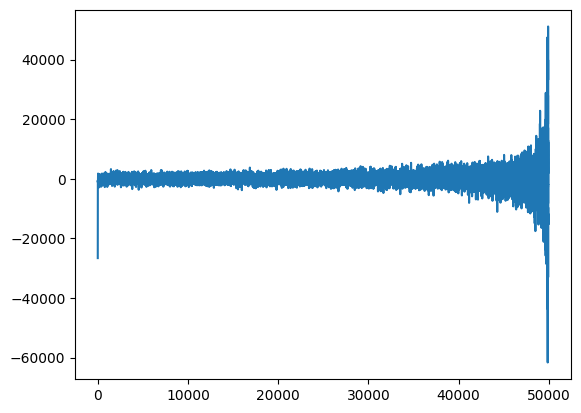

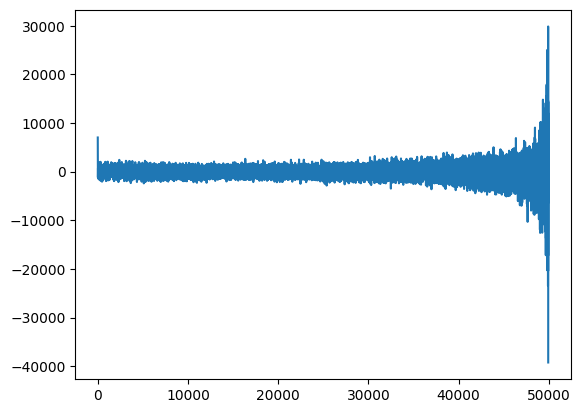

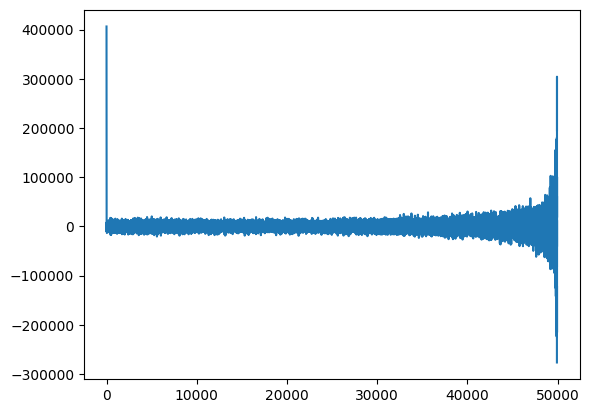

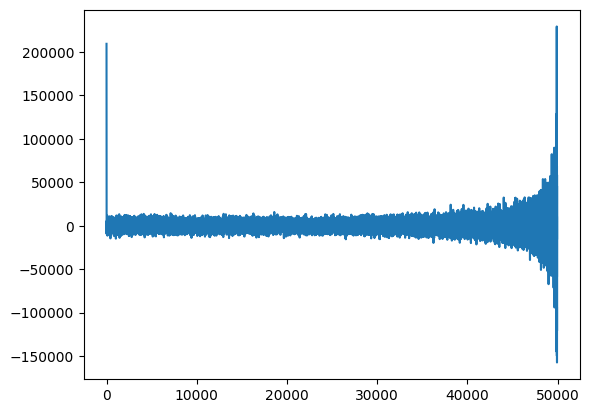

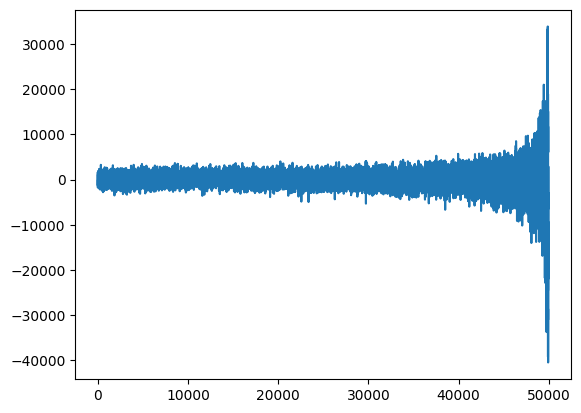

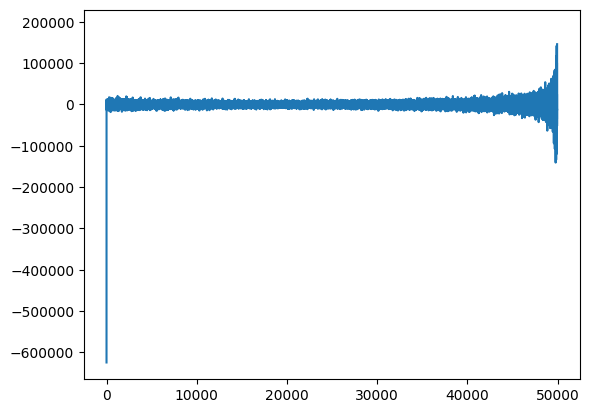

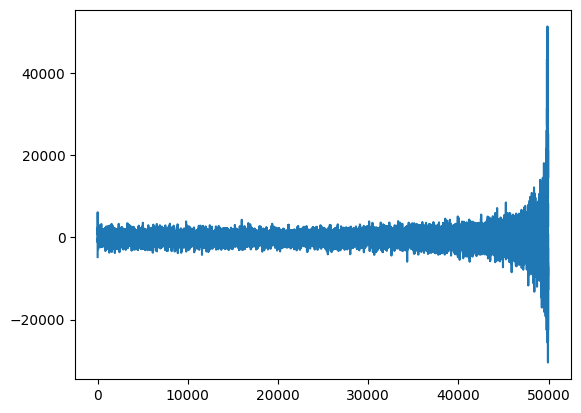

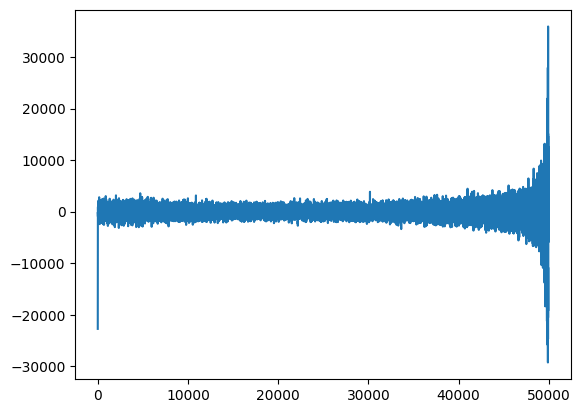

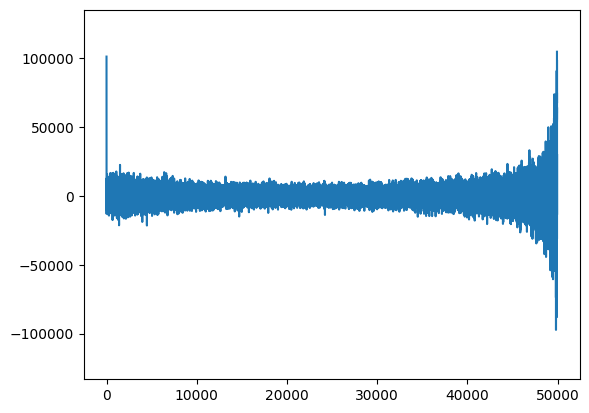

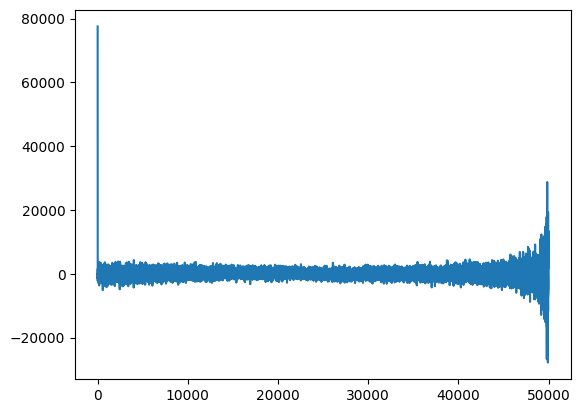

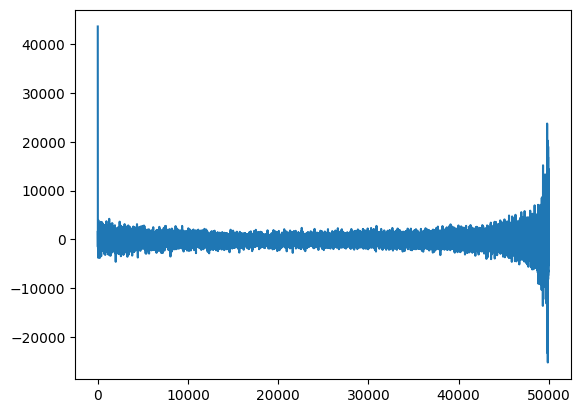

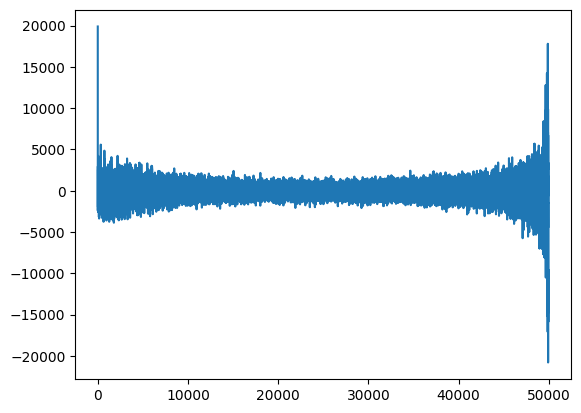

In [12]:
for key, exp in experiments.items():
    res = results[key]
    print(f"=== Experiment: {key} ===")
    
    theta_t = res["theta_t"].cpu() 
    print(theta_t.shape) 
    

    for i in range(0,theta_t.shape[1]): 
        plt.plot(theta_t[:,i]) 
        plt.show() 
        

## Coarse graining signal (1 scale) 

In [13]:
for key, exp in experiments.items():
    xt = results[key]['xt']
    print(xt.shape) 
    print(x1.shape) 

    for j in range(1):
        xt_cg = W.decompose(xt)[1]
        x1_cg = W.decompose(x1)[1]
    print(xt_cg.shape) 
    print(x1_cg.shape) 


torch.Size([5000, 1, 256])
torch.Size([5000, 1, 256])
torch.Size([5000, 1, 128])
torch.Size([5000, 1, 128])


## Visual comparison of samples

CoshGt ψ


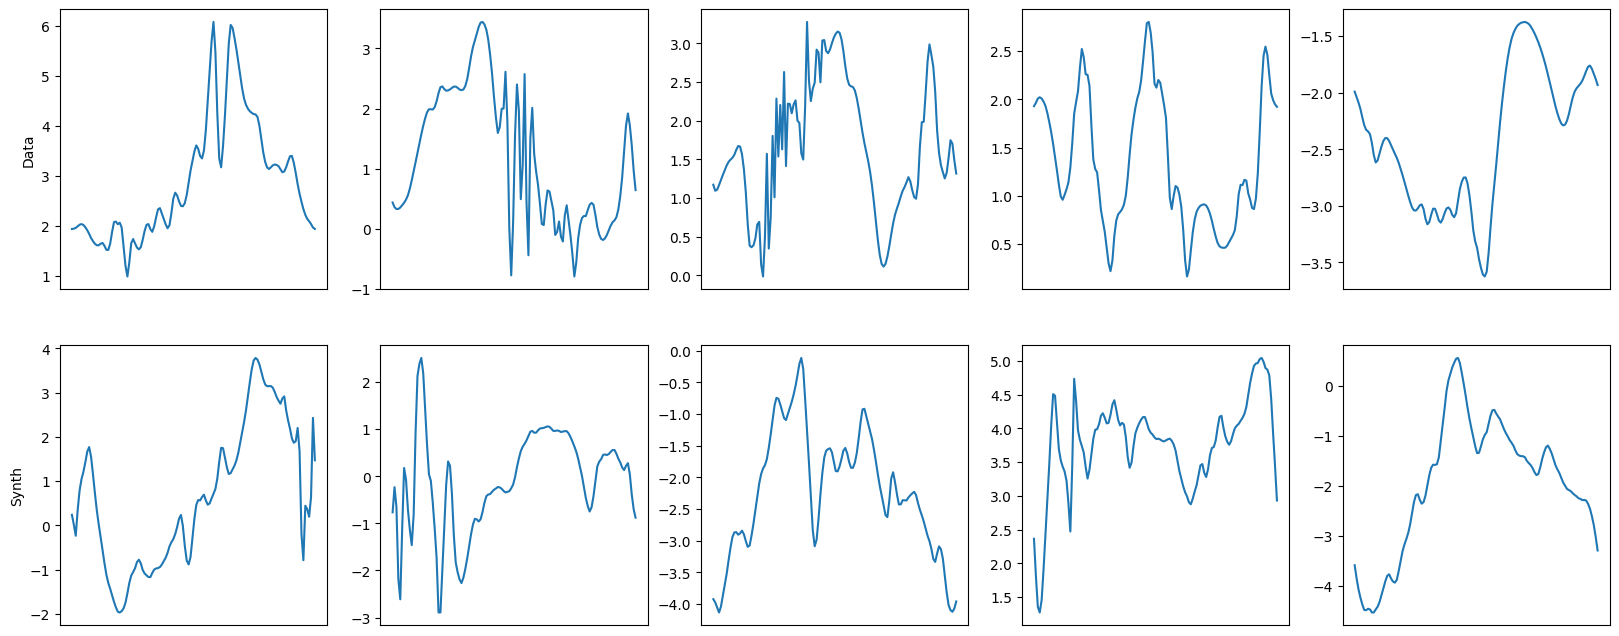

<Figure size 640x480 with 0 Axes>

CoshGt ψ


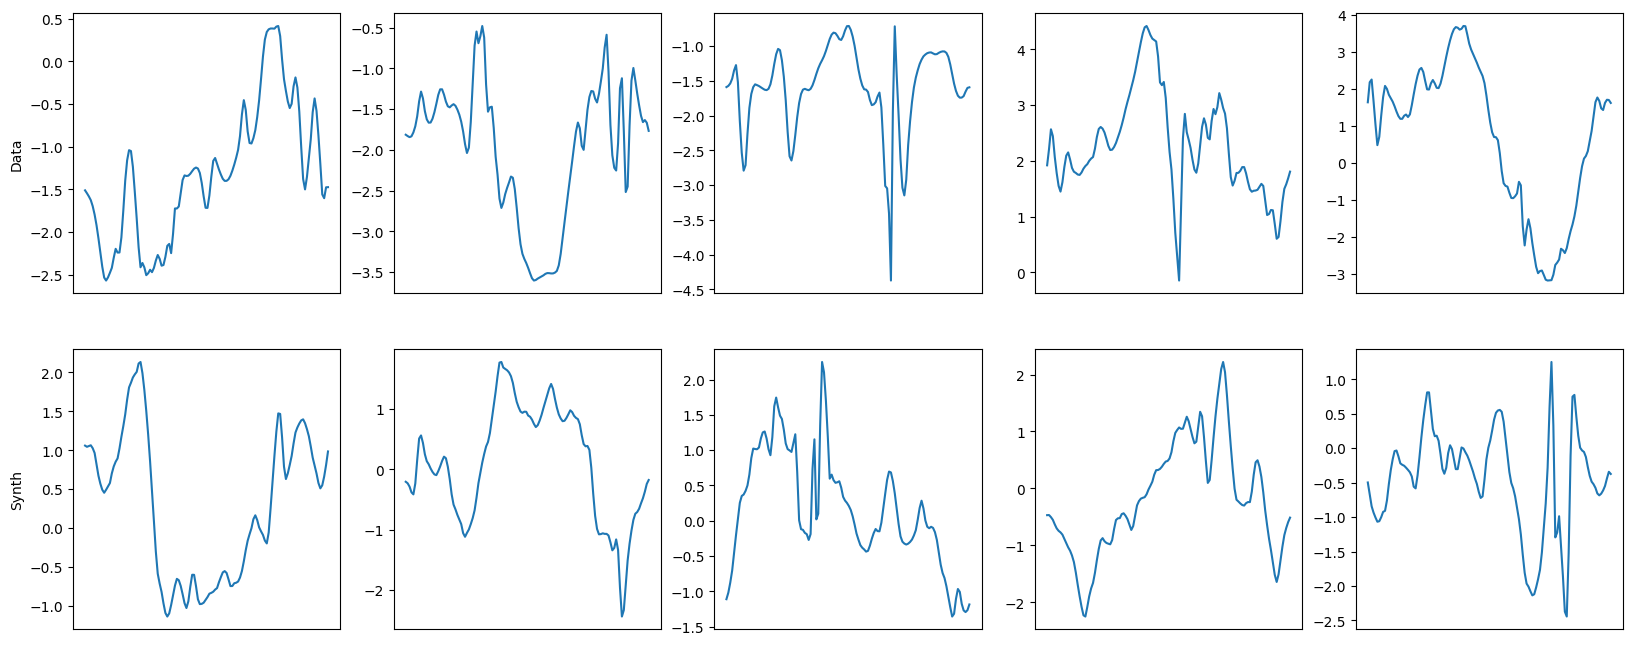

<Figure size 640x480 with 0 Axes>

CoshGt ψ


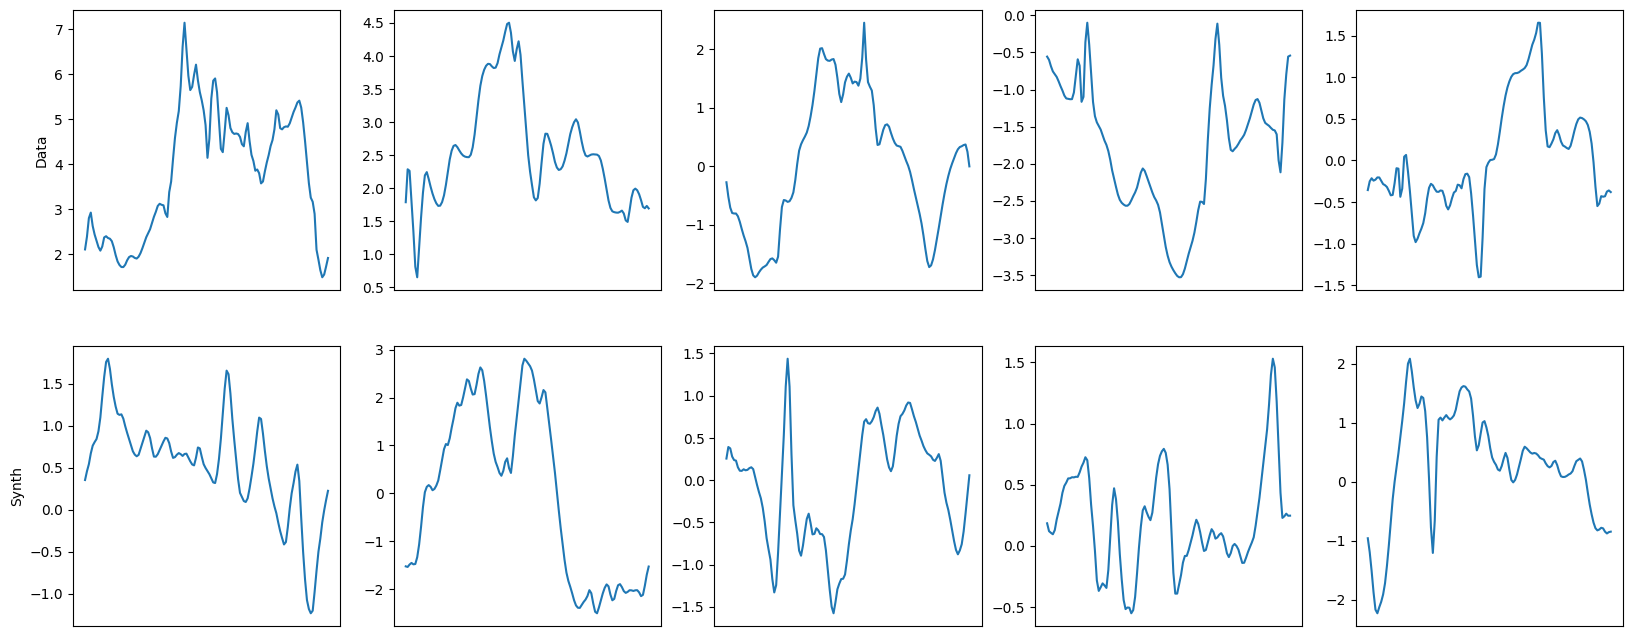

<Figure size 640x480 with 0 Axes>

CoshGt ψ


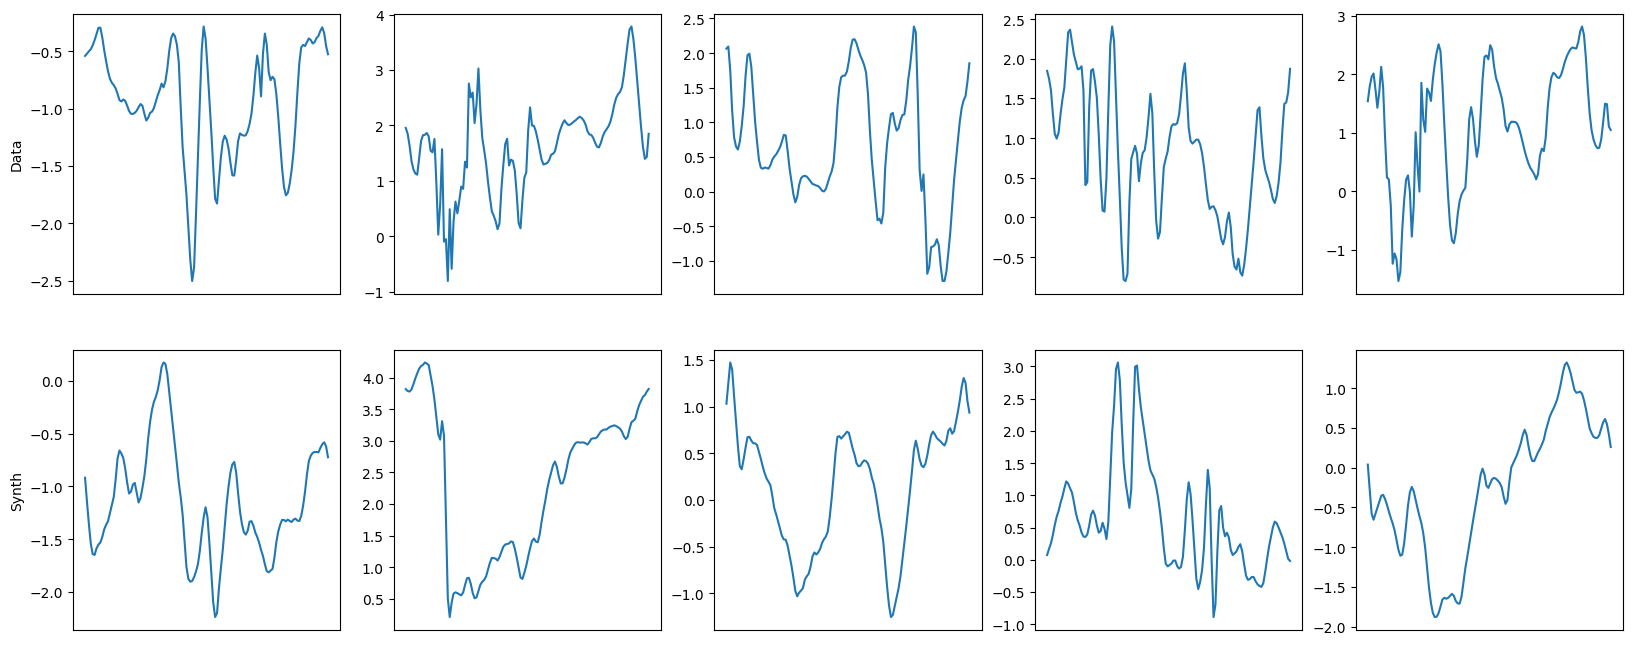

<Figure size 640x480 with 0 Axes>

CoshGt ψ


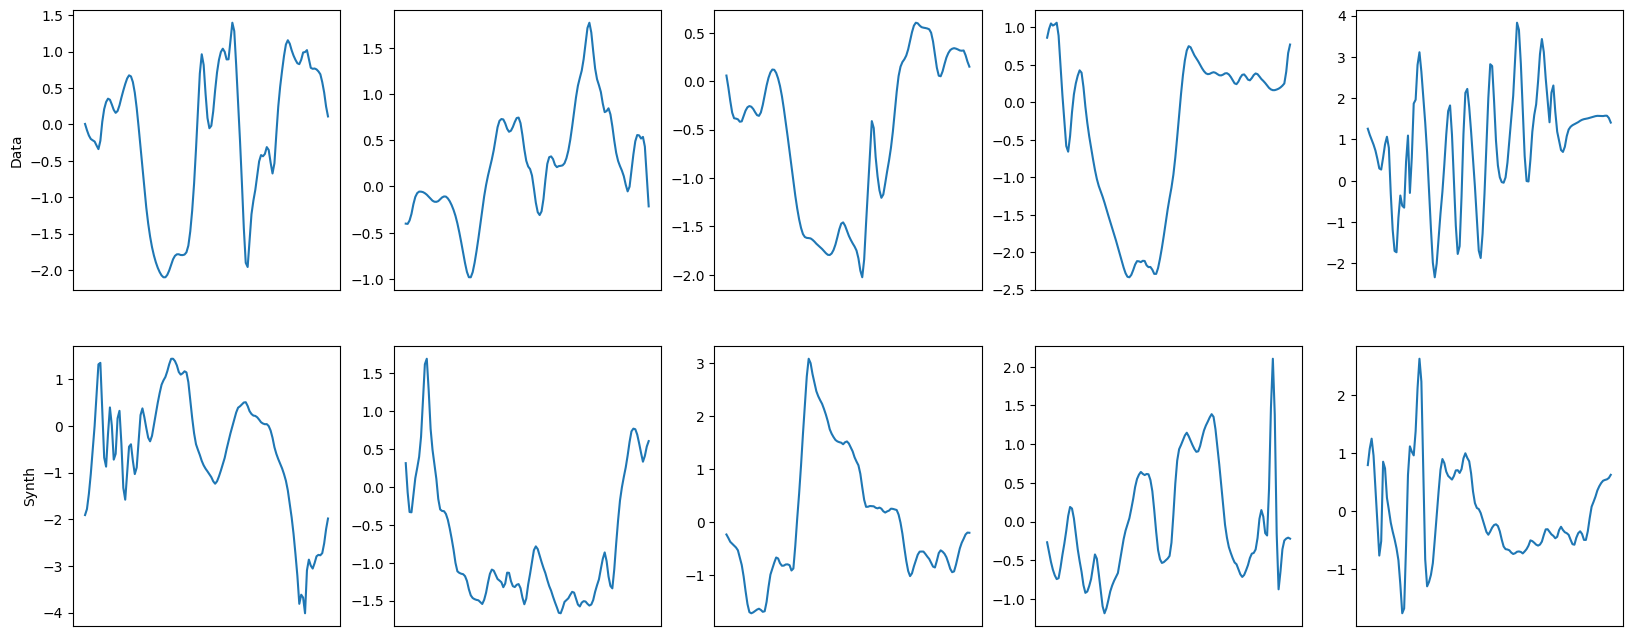

<Figure size 640x480 with 0 Axes>

CoshGt ψ


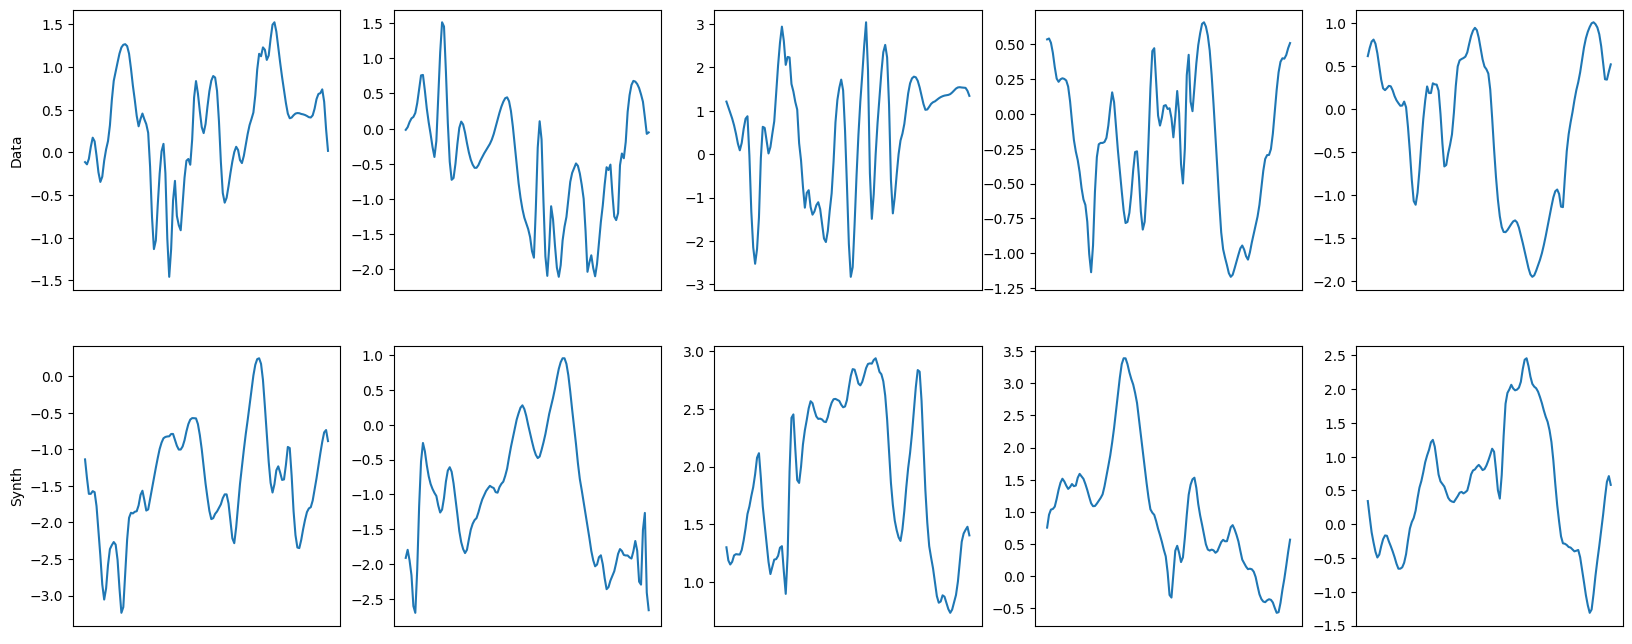

<Figure size 640x480 with 0 Axes>

CoshGt ψ


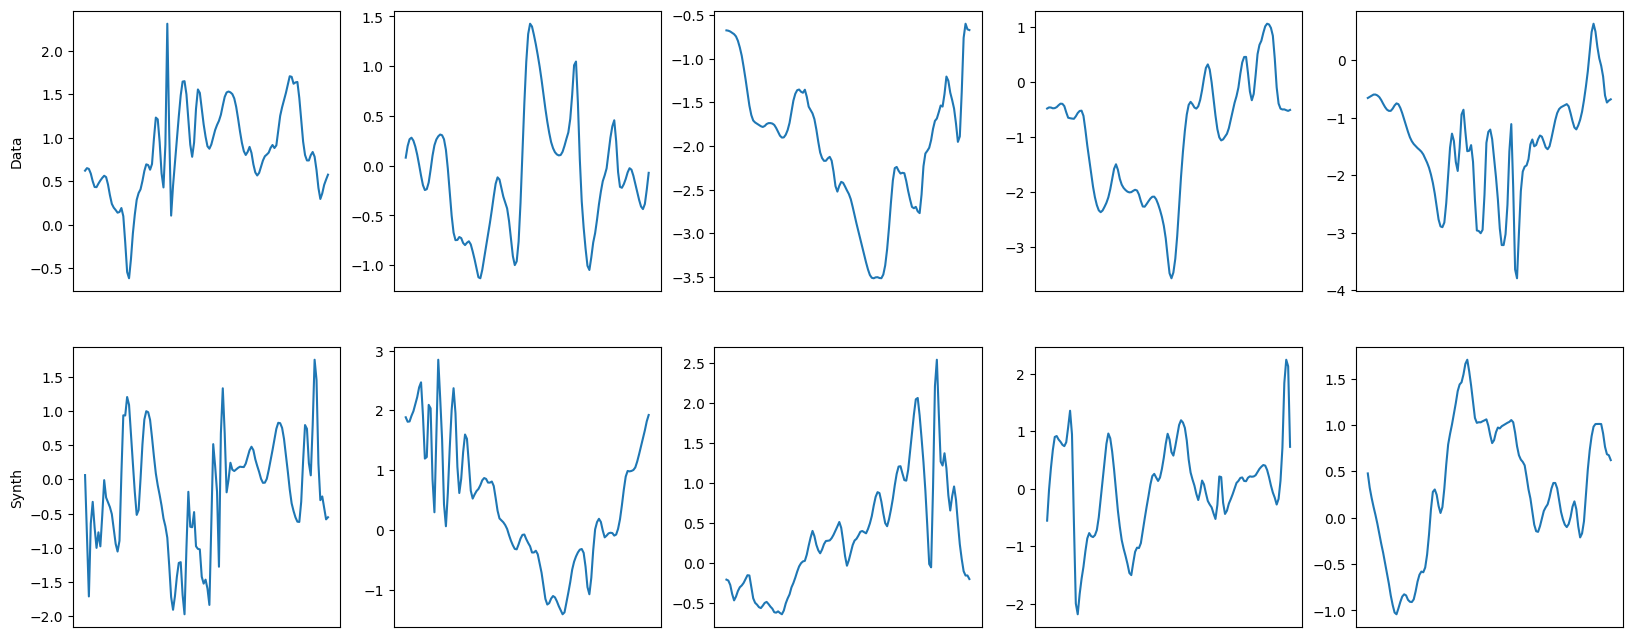

<Figure size 640x480 with 0 Axes>

CoshGt ψ


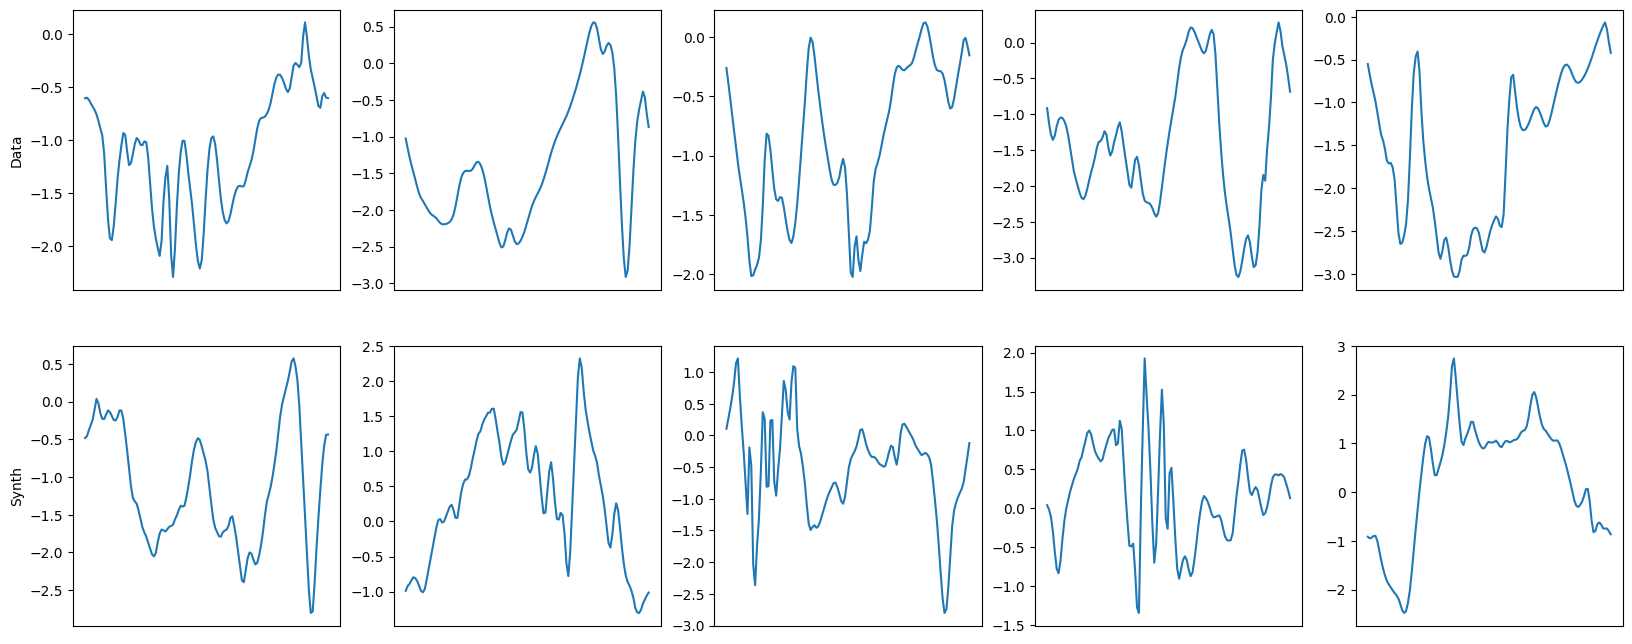

<Figure size 640x480 with 0 Axes>

CoshGt ψ


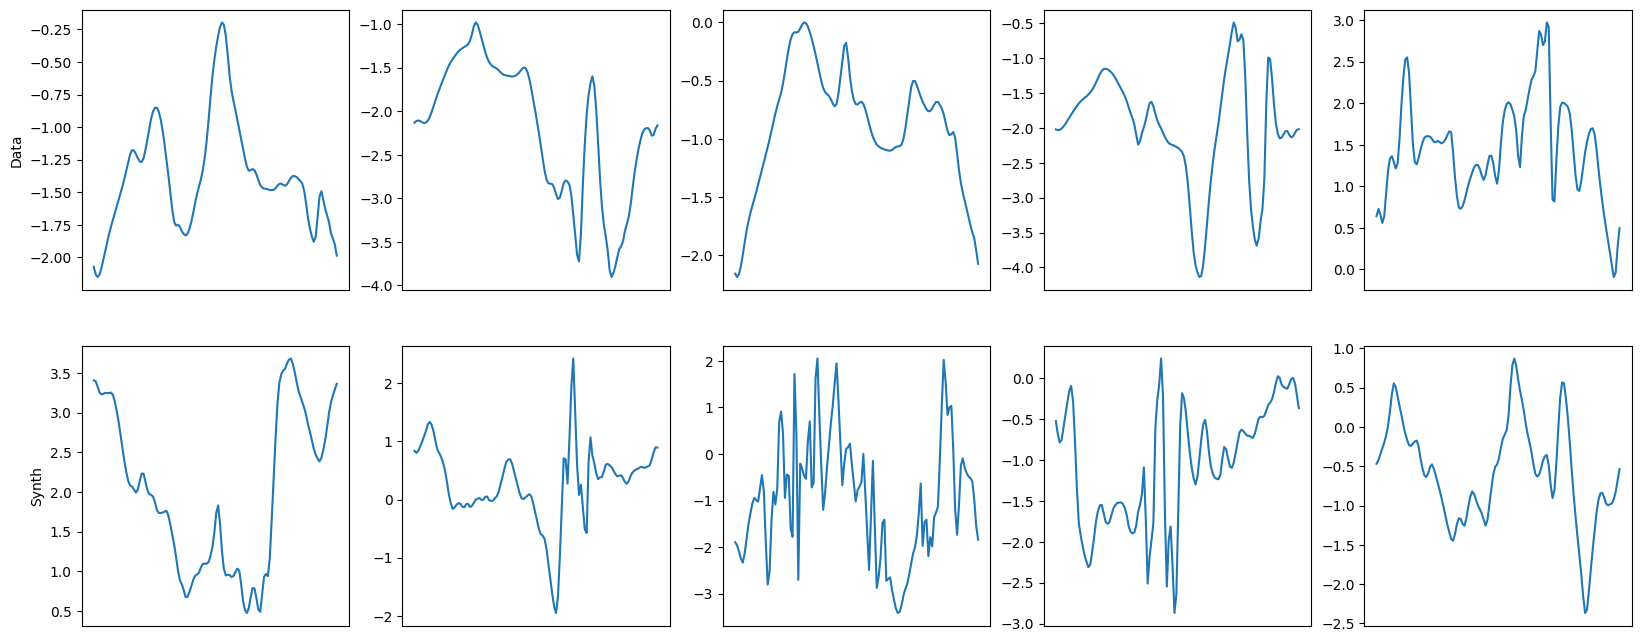

<Figure size 640x480 with 0 Axes>

CoshGt ψ


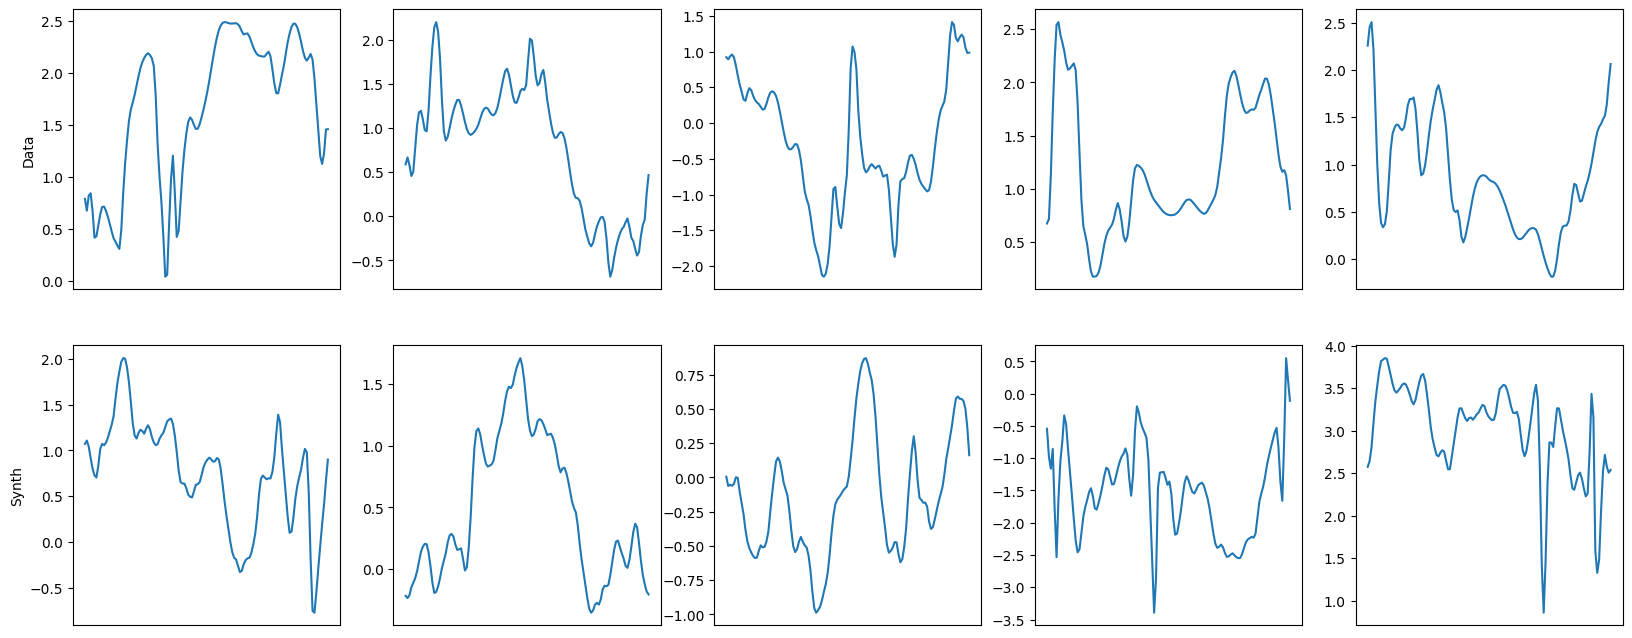

<Figure size 640x480 with 0 Axes>

CoshGt ψ


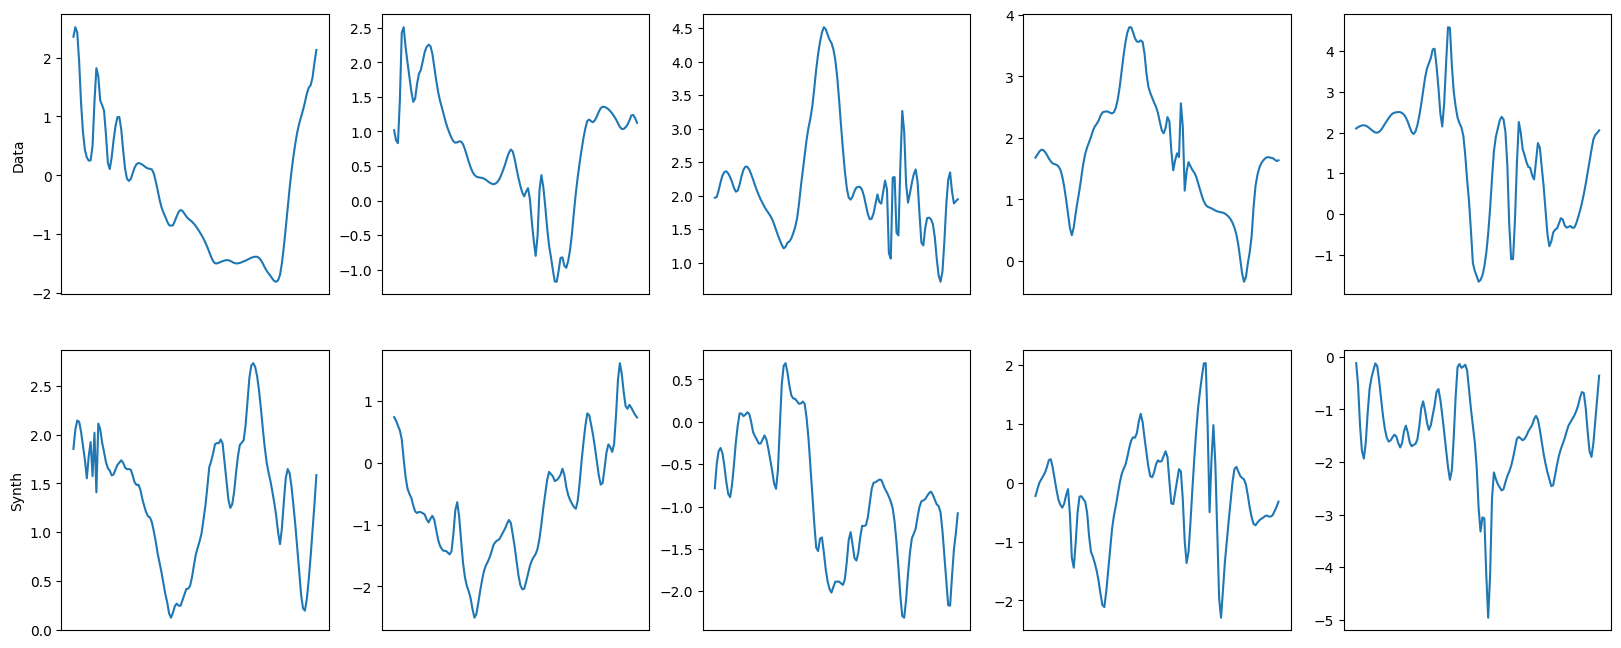

<Figure size 640x480 with 0 Axes>

CoshGt ψ


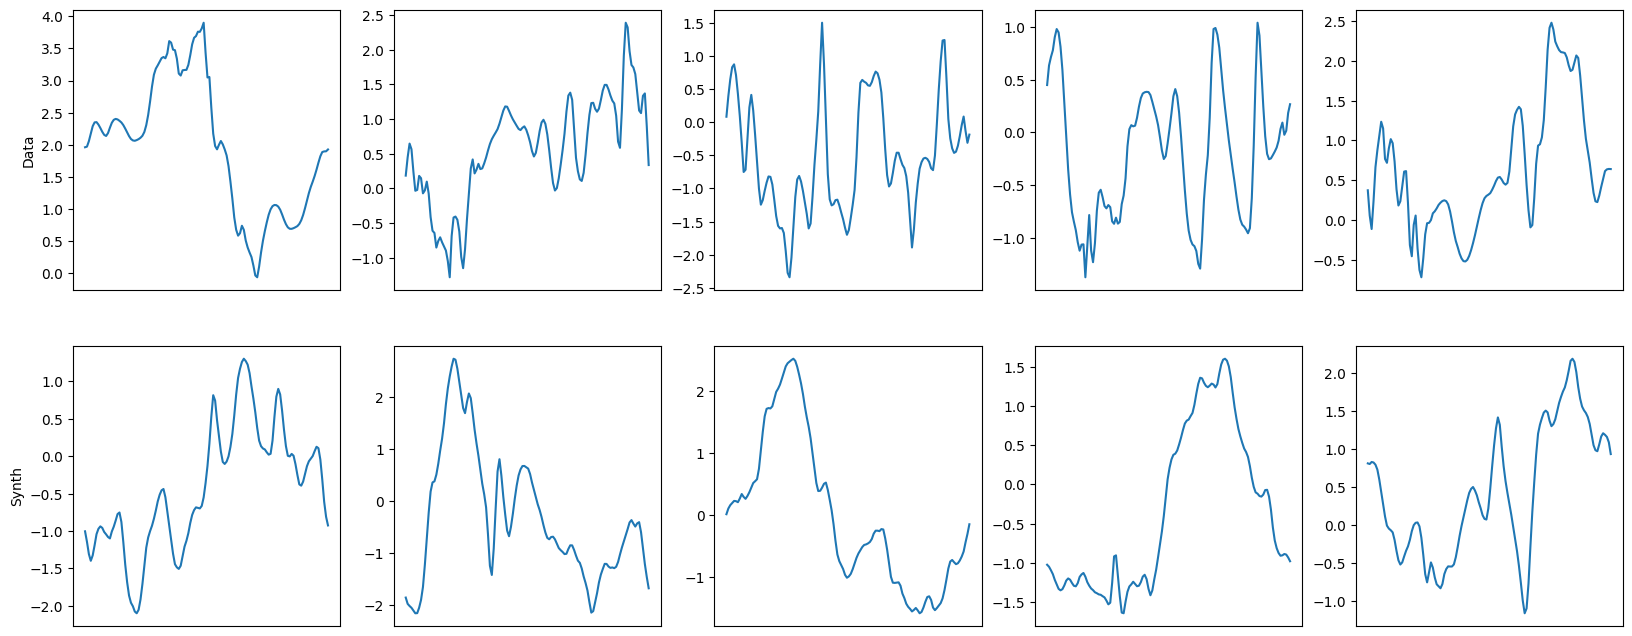

<Figure size 640x480 with 0 Axes>

CoshGt ψ


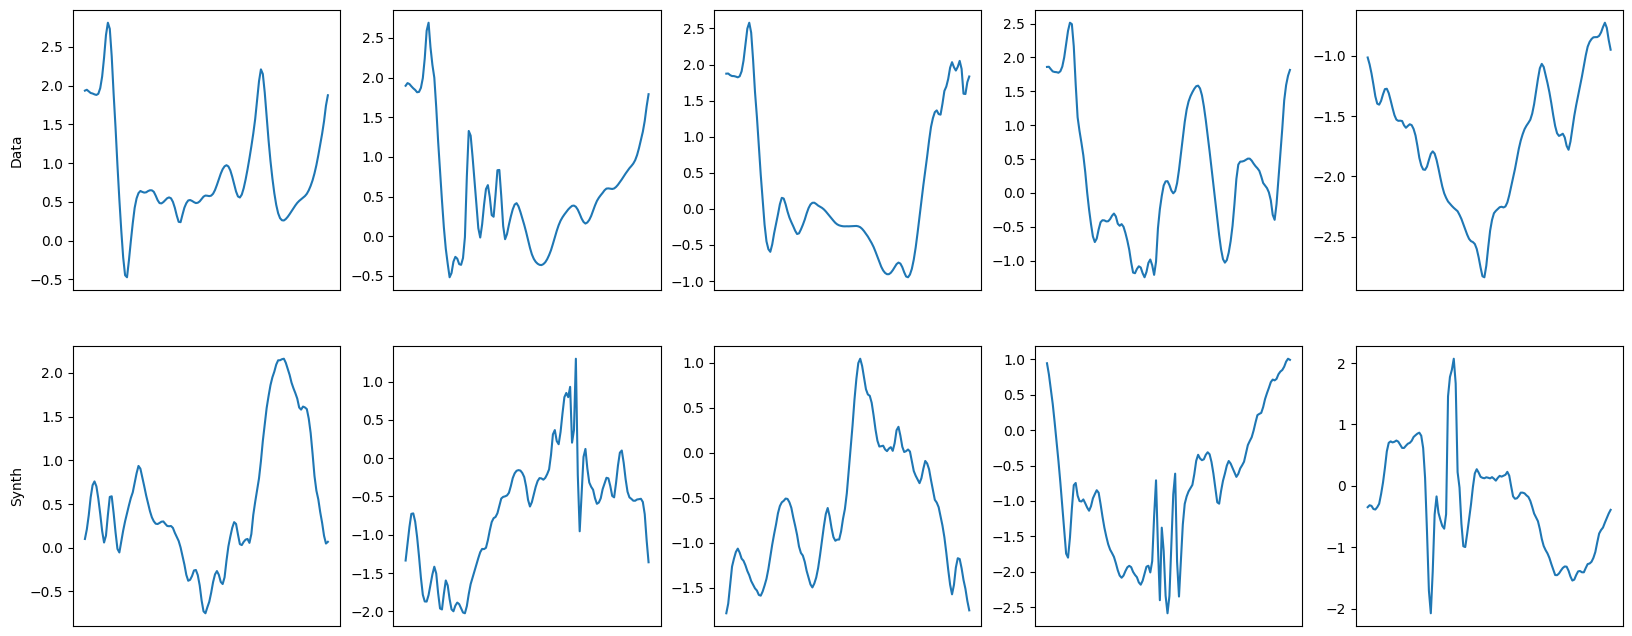

<Figure size 640x480 with 0 Axes>

CoshGt ψ


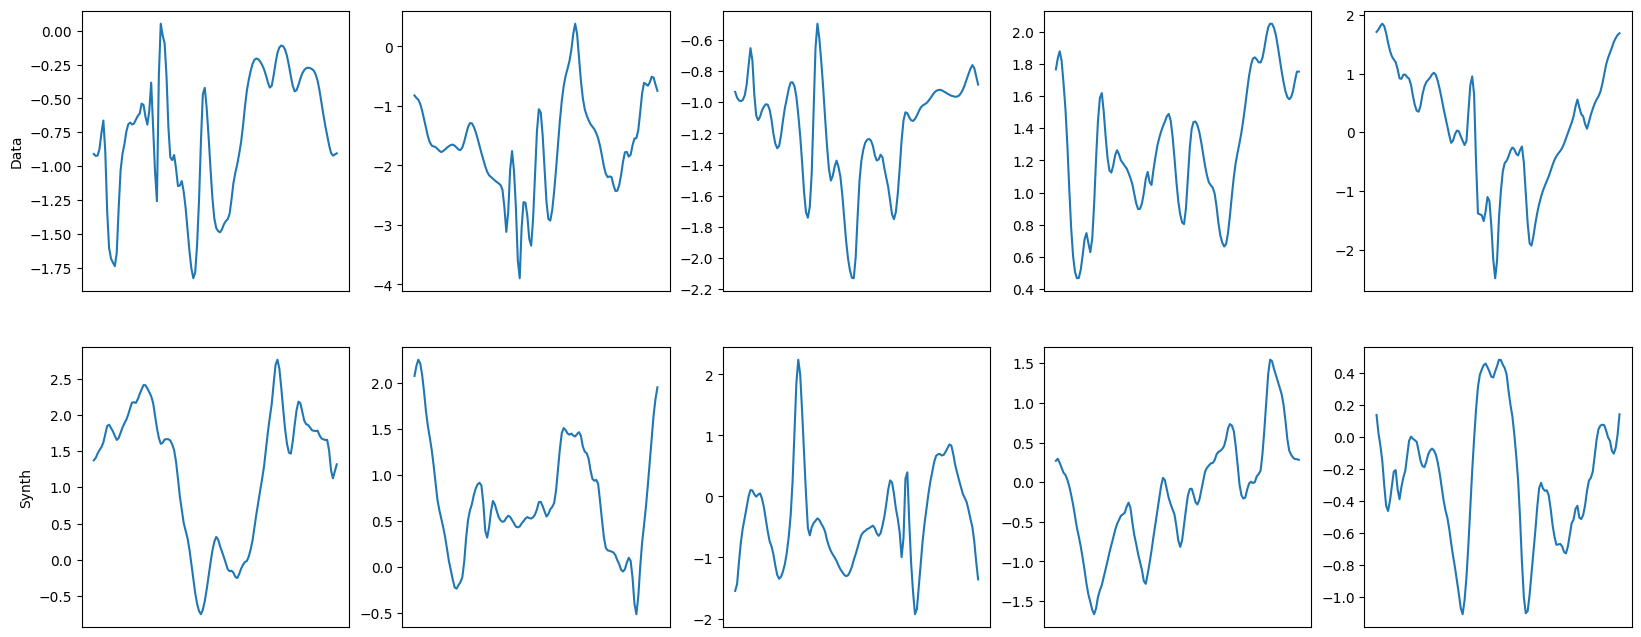

<Figure size 640x480 with 0 Axes>

CoshGt ψ


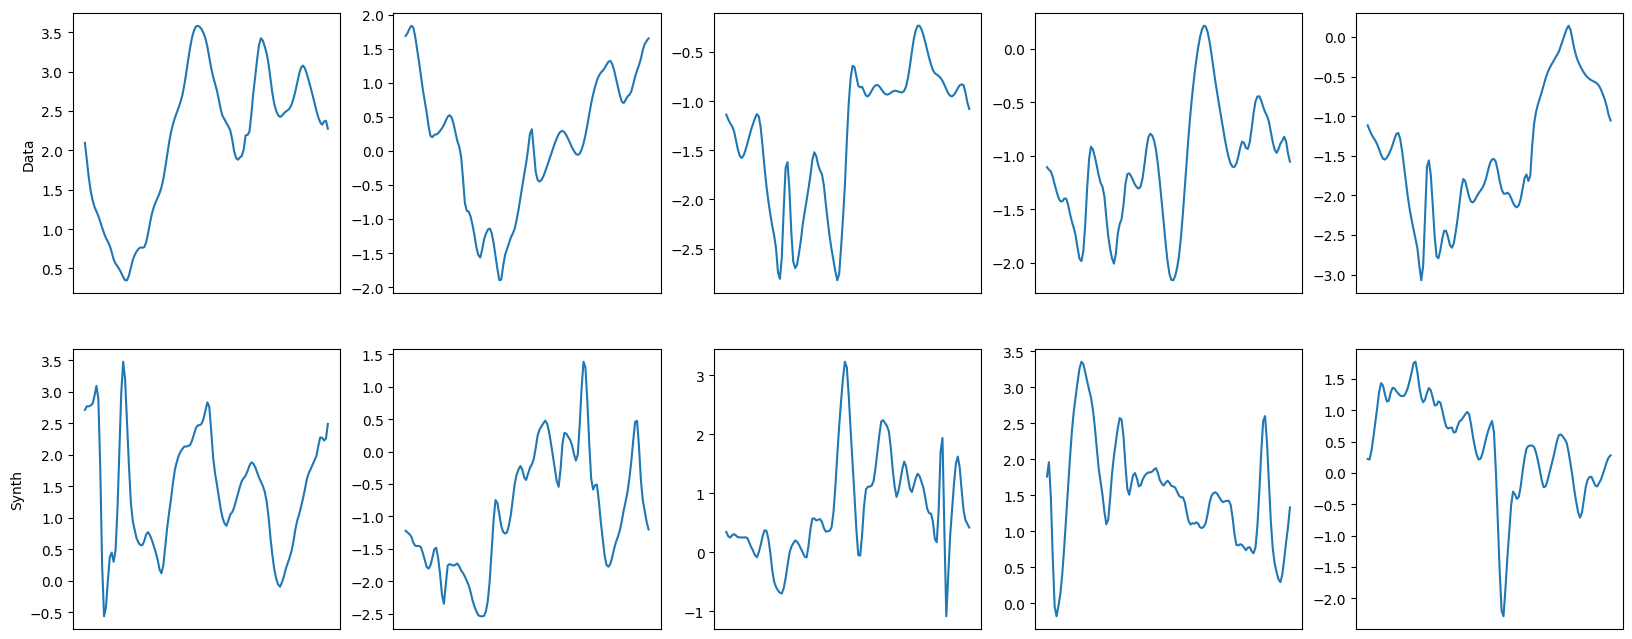

<Figure size 640x480 with 0 Axes>

In [14]:
for i in range(0,15): 
    for key, exp in experiments.items():
        print(exp['label'])
        Compare_time_series_row(x1_cg[i*5:i*5+5,:,:], xt_cg[i*5:i*5+5,:,:],5)
        plt.suptitle(exp['label'])
        plt.show()


## Existing project diagnostics, side by side by model

Spectrum
CoshGt ψ


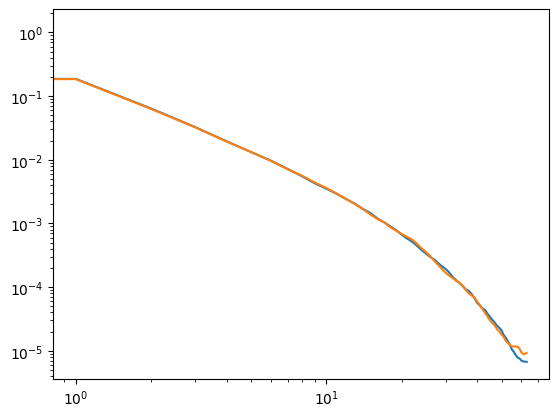

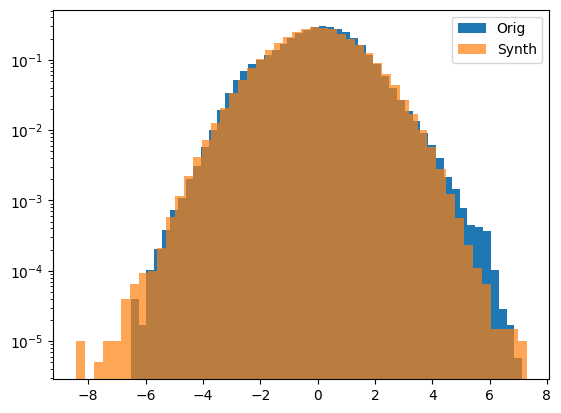

<Figure size 640x480 with 0 Axes>

Histogram
CoshGt ψ


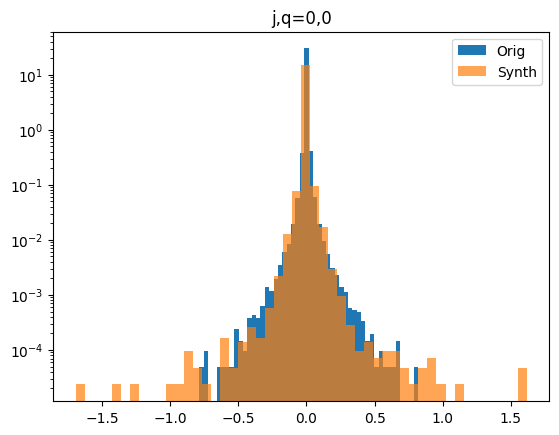

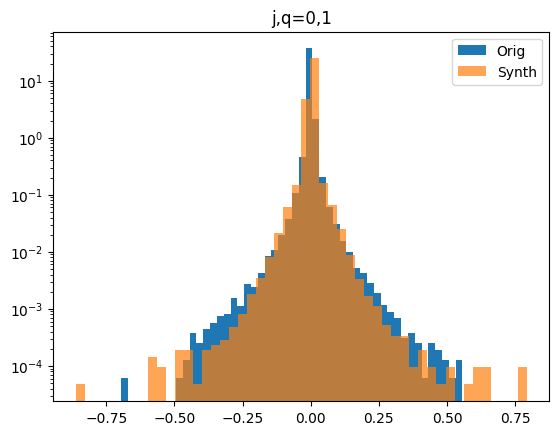

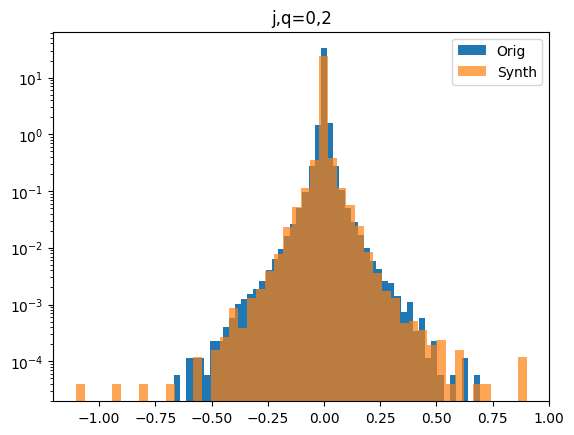

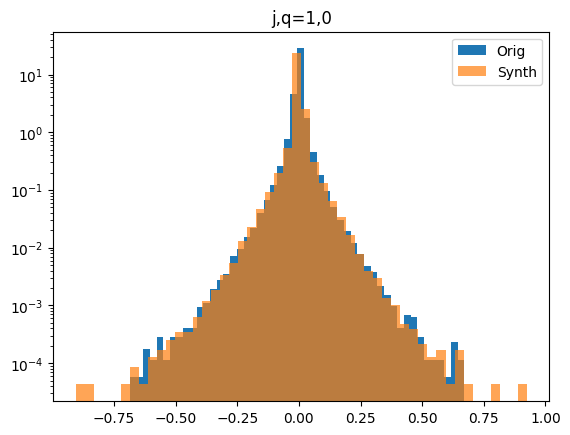

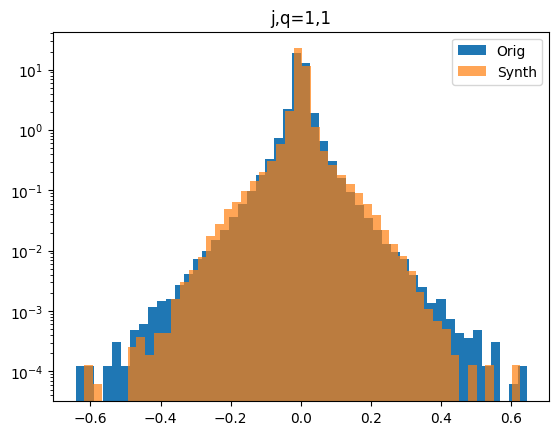

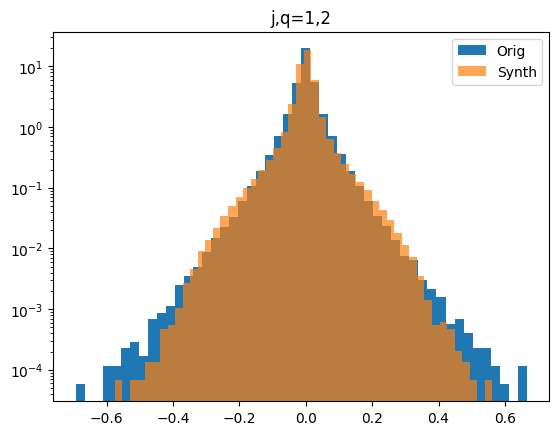

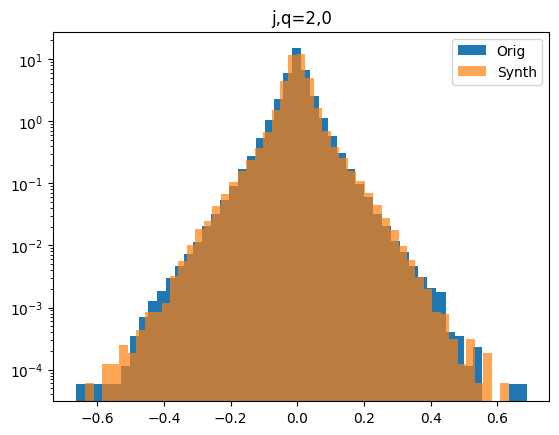

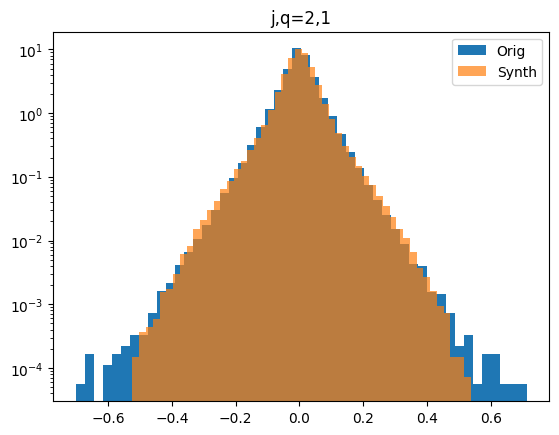

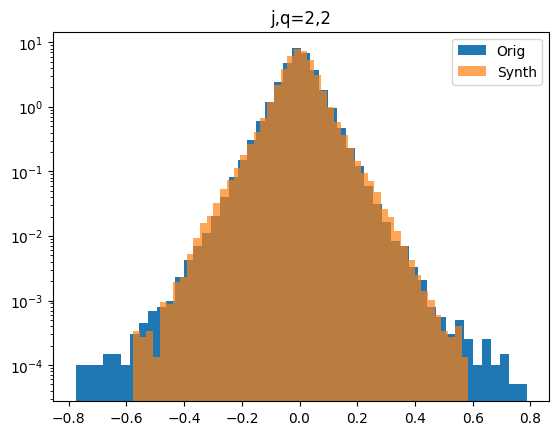

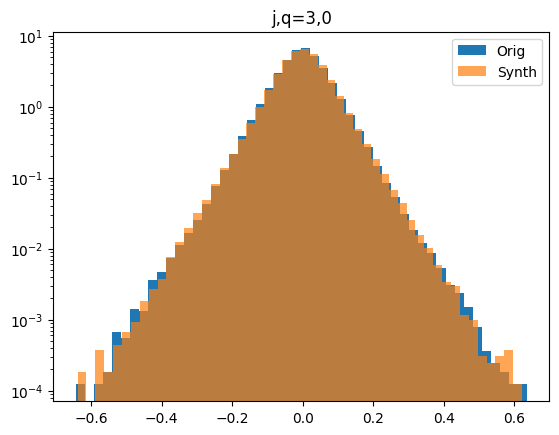

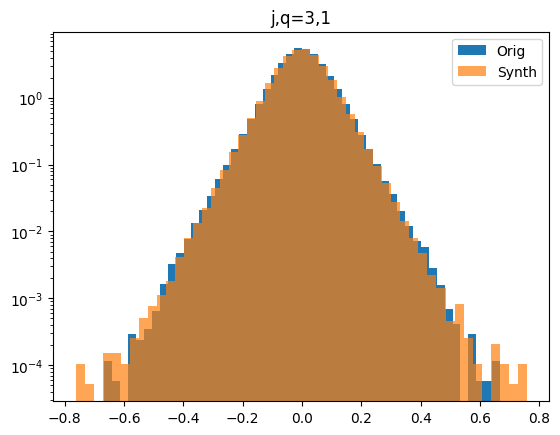

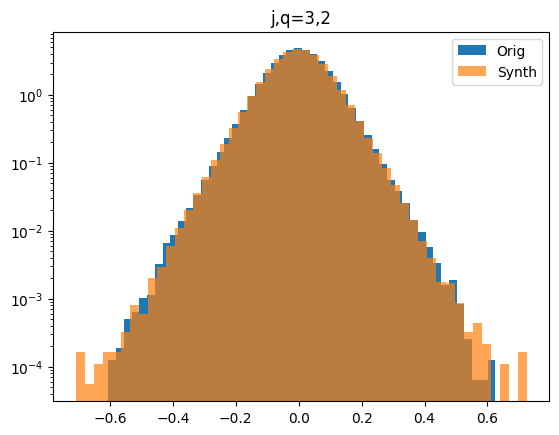

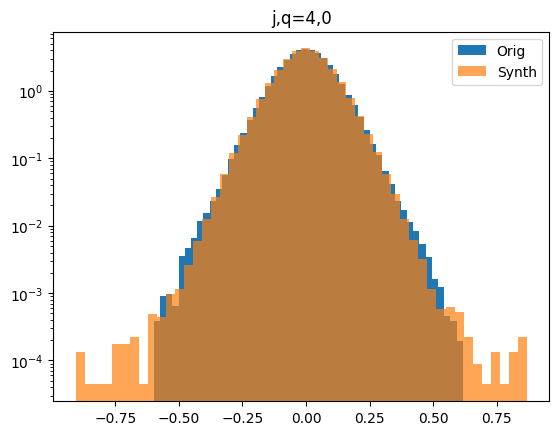

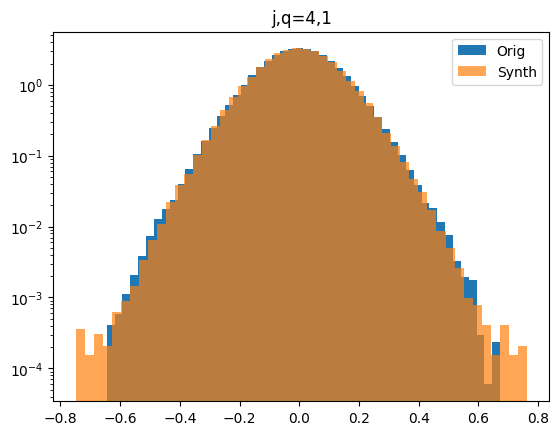

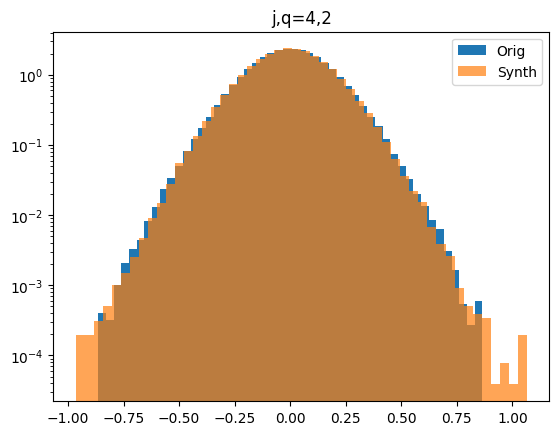

<Figure size 640x480 with 0 Axes>

Structure functions
CoshGt ψ


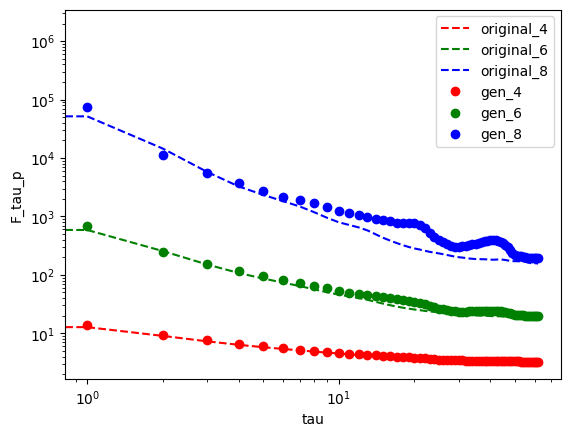

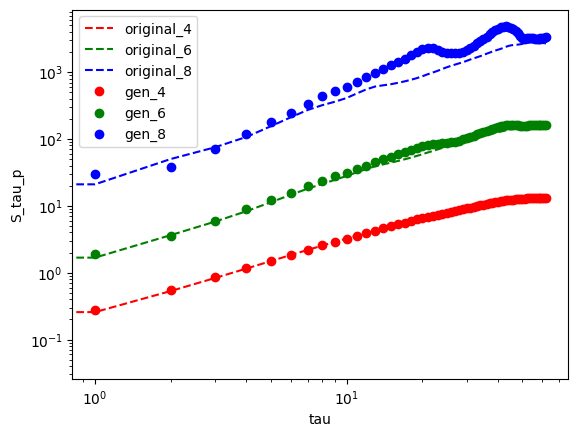

<Figure size 640x480 with 0 Axes>

Cross statistics
CoshGt ψ
(p,q)= (3, 1)


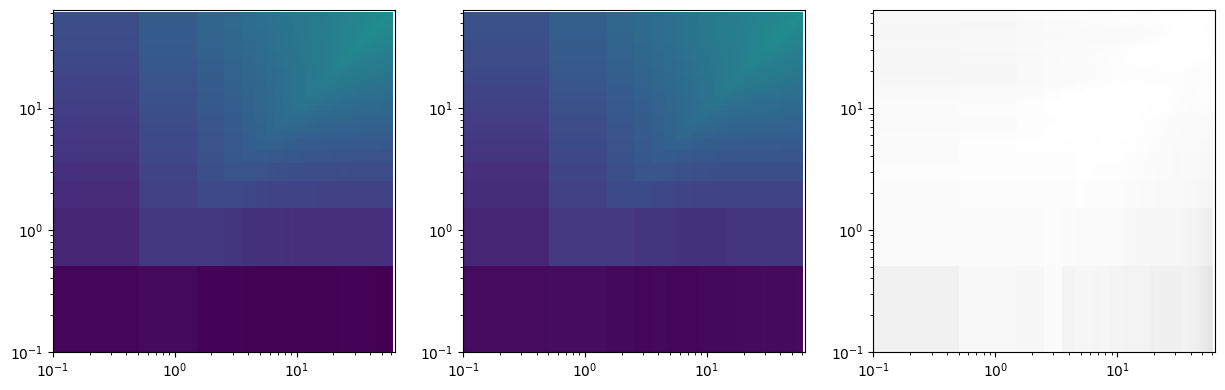

(p,q)= (3, 3)


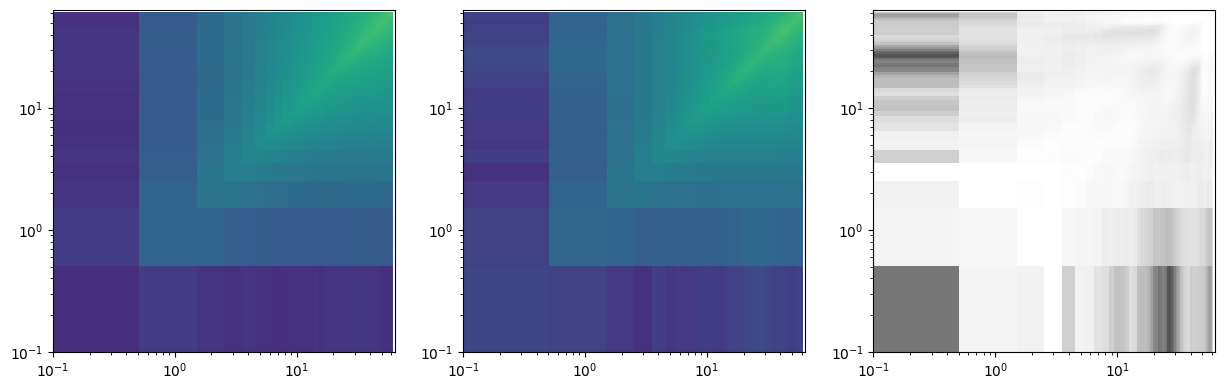

(p,q)= (4, 4)


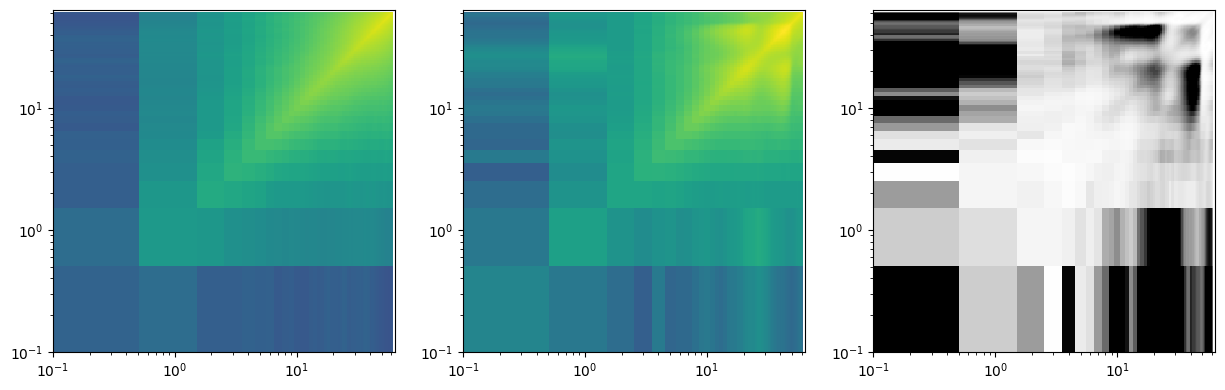

<Figure size 640x480 with 0 Axes>

In [15]:
def run_project_diagnostics(x_ref, results, experiments):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        for key, exp in experiments.items():
            print(exp['label'])
            diag_fun(x_ref, xt_cg)
            plt.suptitle(f"{diag_name}: {exp['label']}")
            plt.show()

    print('' + '=' * 80)
    print('Cross statistics')
    print('=' * 80)
    for key, exp in experiments.items():
        print(exp['label'])
        cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        plt.suptitle(f"Cross statistics: {exp['label']}")
        plt.show()

run_project_diagnostics(x1_cg, results, experiments)


## Quantitative comparison metrics

The following metrics are intentionally simple and independent from the plotting utilities:

- **Mean / std error:** relative mismatch of first two moments.
- **Spectrum relative MSE:** mismatch of the average Fourier power spectrum.
- **Histogram Wasserstein distance:** average 1D Wasserstein distance over channels.
- **Structure-function relative MSE:** mismatch of selected structure functions.


In [16]:
def to_numpy_flat_channels(x):
    """Return array of shape [channels, batch*time]."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    return np.transpose(x, (1, 0, 2)).reshape(x.shape[1], -1)


def average_power_spectrum(x):
    """Average power spectrum over batch and channels."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    fft = np.fft.rfft(x, axis=-1)
    ps = np.abs(fft)**2
    return ps.mean(axis=(0, 1))


def structure_functions_np(x, qs=(1, 2, 3, 4), lags=None):
    """Simple structure functions E[|x(t+lag)-x(t)|^q]."""
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    T = x.shape[-1]
    if lags is None:
        max_lag = max(2, T // 4)
        lags = np.unique(np.logspace(0, np.log10(max_lag), 20).astype(int))

    sf = np.zeros((len(qs), len(lags)))
    for j, lag in enumerate(lags):
        increments = x[..., lag:] - x[..., :-lag]
        abs_inc = np.abs(increments)
        for i, q in enumerate(qs):
            sf[i, j] = np.mean(abs_inc**q)
    return np.asarray(qs), np.asarray(lags), sf


def relative_mse(a, b, eps=1e-12):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.mean((a - b)**2) / (np.mean(a**2) + eps)


def compute_metrics(x_ref, x_gen):
    ref_flat = to_numpy_flat_channels(x_ref)
    gen_flat = to_numpy_flat_channels(x_gen)

    mean_ref = ref_flat.mean(axis=1)
    mean_gen = gen_flat.mean(axis=1)
    std_ref = ref_flat.std(axis=1)
    std_gen = gen_flat.std(axis=1)

    mean_rel_err = np.linalg.norm(mean_gen - mean_ref) / (np.linalg.norm(mean_ref) + 1e-12)
    std_rel_err = np.linalg.norm(std_gen - std_ref) / (np.linalg.norm(std_ref) + 1e-12)

    ps_ref = average_power_spectrum(x_ref)
    ps_gen = average_power_spectrum(x_gen)
    spectrum_rel_mse = relative_mse(ps_ref, ps_gen)

    wass = []
    for c in range(ref_flat.shape[0]):
        wass.append(stats.wasserstein_distance(ref_flat[c], gen_flat[c]))
    wasserstein_mean = float(np.mean(wass))

    qs, lags, sf_ref = structure_functions_np(x_ref)
    _, _, sf_gen = structure_functions_np(x_gen, qs=qs, lags=lags)
    structure_rel_mse = relative_mse(sf_ref, sf_gen)

    return {
        'mean_rel_error': float(mean_rel_err),
        'std_rel_error': float(std_rel_err),
        'spectrum_rel_mse': float(spectrum_rel_mse),
        'hist_wasserstein_mean': float(wasserstein_mean),
        'structure_rel_mse': float(structure_rel_mse),
    }

metrics = {}
for key, exp in experiments.items():
    metrics[key] = compute_metrics(x1, results[key]['xt'])

import pandas as pd
metrics_df = pd.DataFrame(metrics).T
metrics_df.index = [experiments[k]['label'] for k in metrics_df.index]
metrics_df


,mean_rel_error,std_rel_error,spectrum_rel_mse,hist_wasserstein_mean,structure_rel_mse
CoshGt ψ,176959.703125,0.001479,0.000002,0.040817,0.00026


## Direct overlay plots for spectrum and structure functions

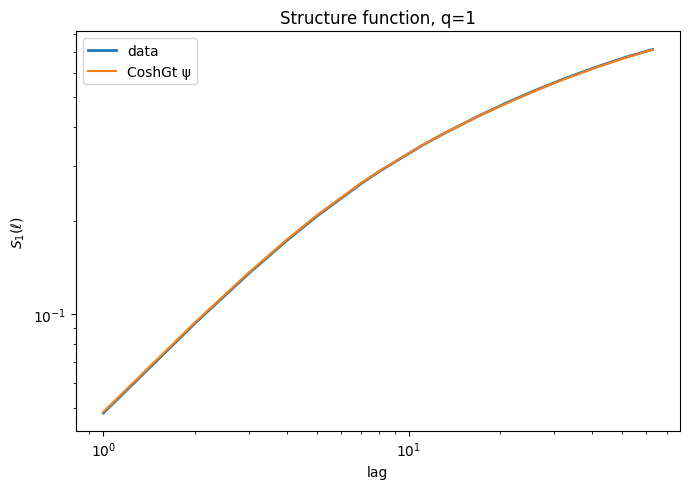

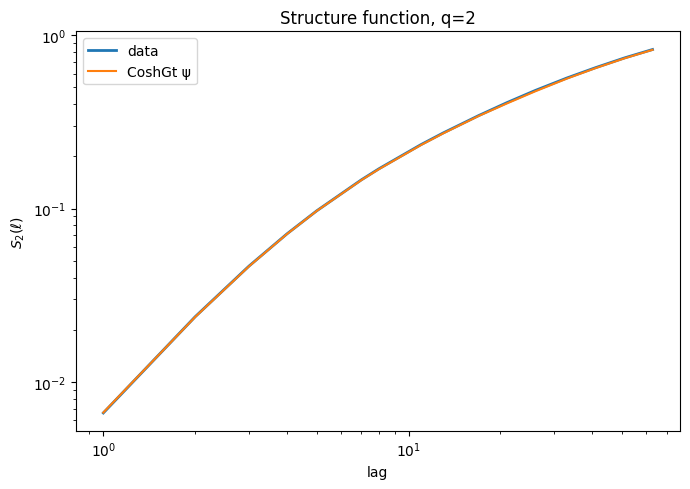

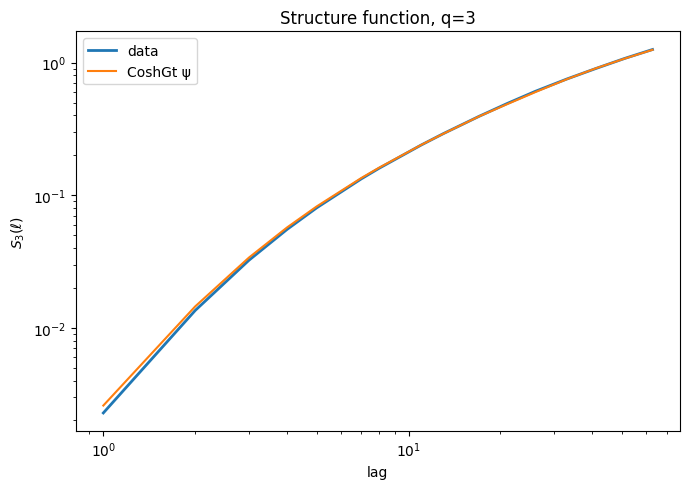

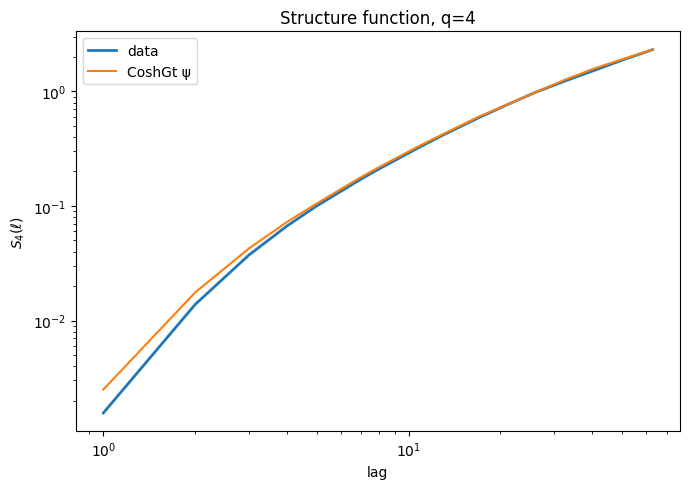

In [17]:
def plot_structure_overlay(x_ref, results, experiments, qs_to_plot=(1, 2, 3, 4)):
    qs, lags, sf_ref = structure_functions_np(x_ref, qs=qs_to_plot)

    for i, q in enumerate(qs):
        plt.figure(figsize=(7, 5))
        plt.loglog(lags, sf_ref[i], label='data', linewidth=2)
        for key, exp in experiments.items():
            _, _, sf = structure_functions_np(results[key]['xt'], qs=qs, lags=lags)
            plt.loglog(lags, sf[i], label=exp['label'])
        plt.xlabel('lag')
        plt.ylabel(rf'$S_{q}(\ell)$')
        plt.title(rf'Structure function, q={q}')
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_structure_overlay(x1, results, experiments, qs_to_plot=(1, 2, 3, 4))


## Entropy bound comparison

CoshGt ψ
  Entropy bound: nan
  Gaussian estimation: 9.4781494140625


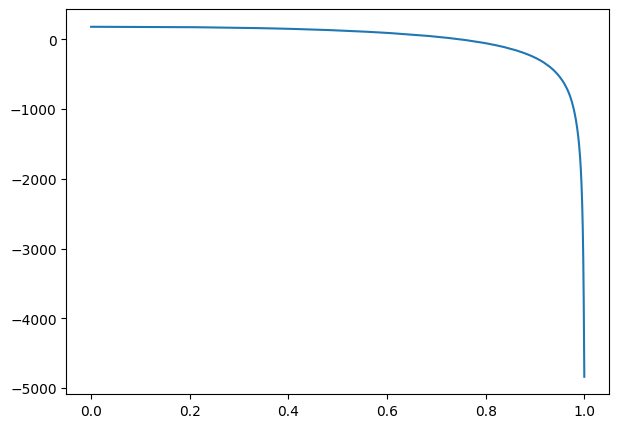

<class 'ValueError'>: x and y must have same first dimension, but have shapes (1, 8, 256) and (50001,)

In [19]:
def entropy_curves(x_ref, dH_t_bound, t_used):
    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    #H_p_0 = H-
    H_t_bound = dH_t_bound.cumsum(0).detach().cpu() / nt + H_p_0
    H_t_gaussian = compute_gaussian_entropy(x_ref, interpolant, t_used.cpu())
    return H_t_bound, H_t_gaussian

plt.figure(figsize=(7, 5))
last_gaussian = None
for key, exp in experiments.items():
    H_t_bound, H_t_gaussian = entropy_curves(x1_cg, results[key]['dH_t_bound'], results[key]['t'])
    last_gaussian = H_t_gaussian
    print(exp['label'])
    print('  Entropy bound:', H_t_bound[-1].item() if torch.is_tensor(H_t_bound[-1]) else H_t_bound[-1])
    print('  Gaussian estimation:', H_t_gaussian[-1].item() if torch.is_tensor(H_t_gaussian[-1]) else H_t_gaussian[-1])
    plt.plot(results[key]['t'].detach().cpu(), H_t_bound, label=f"bound: {exp['label']}")

plt.plot(
    t.detach().cpu(),
    last_gaussian.detach().cpu() if torch.is_tensor(last_gaussian) else last_gaussian,
    '--',
    label='Gaussian entropy estimate',
)
plt.xlabel('t')
plt.ylabel('entropy')
plt.legend()
plt.tight_layout()
plt.show()
